# Introduction

The prediction of ADMET properties—Absorption, Distribution, Metabolism, Excretion, and Toxicity—is one of the key stages in modern drug discovery. These properties determine how a candidate molecule behaves in a biological system and strongly influence its safety, efficacy, and probability of successful development. Experimental evaluation of ADMET characteristics is often expensive, time-consuming, and requires significant laboratory resources. Therefore, computational methods, especially machine learning and deep learning approaches, have become increasingly important for early-stage screening of chemical compounds.

In recent years, neural network architectures have shown strong potential for molecular property prediction. Unlike traditional quantitative structure–activity relationship (QSAR) models, neural networks can learn complex non-linear relationships between molecular structure and biological or physicochemical properties. Different molecular representations can be used as input data, including molecular descriptors, fingerprints, SMILES strings, and graph-based representations. As a result, various neural network architectures such as fully connected neural networks, convolutional neural networks, recurrent neural networks, transformers, and graph neural networks have been actively explored for ADMET prediction tasks.

The aim of this study is to investigate and compare neural network architectures for predicting ADMET properties of chemical compounds. The research focuses on analyzing how different model designs and molecular representations affect prediction quality. Special attention is given to evaluating model performance using appropriate metrics and identifying architectures that are more suitable for specific ADMET endpoints.

This work is relevant because accurate in silico prediction of ADMET properties can help reduce the number of unsuccessful drug candidates at later stages of development. By improving early assessment of molecular safety and pharmacokinetic behavior, neural network-based models can contribute to faster, cheaper, and more efficient drug discovery pipelines.

![Admet Properties](images/admet.jpeg)

# Libraries & Dependencies

This project uses Python 3.11. This version provides high performance, supports modern language features, and is compatible with the up-to-date libraries required for the project.

In [152]:
# ! pip install uv 
# ! uv pip install numpy scipy scikit-learn pandas torch torch-geometric rdkit pyyaml PyTDC ipywidgets tensorboard
# conda install -c conda-forge pytdc

## Libraries

In [4]:
import copy
import glob
import json
import math
import os
import random
from collections import defaultdict
from pathlib import Path
from typing import List

import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from rdkit import Chem, RDLogger
from rdkit.Chem import Crippen, Descriptors, rdMolDescriptors
from scipy.stats import spearmanr
from sklearn.metrics import average_precision_score, mean_absolute_error, roc_auc_score
from sklearn.preprocessing import StandardScaler
from tdc.generation import MolGen
from tdc.single_pred import ADME, Tox
from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import DataLoader, TensorDataset
from torch.utils.tensorboard import SummaryWriter
from torch_geometric.loader import DataLoader as PyGDataLoader
from torch_geometric.nn import GINEConv, GraphNorm, global_max_pool, global_mean_pool
from tqdm import tqdm

try:
    from torch_geometric.data import Data
    HAS_PYG = True
except ImportError:
    HAS_PYG = False

from gine_dataset import MolFeaturizer, PretrainGraphDataset
from smiles_dataset import (
    ContrastivePadCollate,
    ContrastiveSMILESDataset,
    PretrainSMILESDataset,
    SMILESTokenizer,
    SequenceRegressionDataset,
    SmilesMLMAndPropertiesCollator,
    SmilesMLMAndPropertiesDataset,
    randomize_smiles,
)


In [16]:
torch.set_num_threads(10)
RDLogger.DisableLog('rdApp.*')

## Plot settings

In [ ]:
plt.rcParams.update({
    "font.family":        "serif",
    "font.serif":         ["DejaVu Serif"],
    "font.size":          11,
    "axes.linewidth":     1.2,
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "xtick.direction":    "out",
    "ytick.direction":    "out",
    "xtick.major.size":   4,
    "ytick.major.size":   4,
    "xtick.major.width":  1.1,
    "ytick.major.width":  1.1,
    "figure.dpi":         180,
})

ALPHA_FILL = 0.10

## Constants

In [18]:
def set_global_seed(seed: int):
    os.environ["PYTHONHASHSEED"] = str(seed)
    os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        torch.mps.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True
    if hasattr(torch, "use_deterministic_algorithms"):
        torch.use_deterministic_algorithms(True)

In [ ]:
SEED = 42
MAX_SEQ_LEN = 256 # Maximum string length in SMILES format
set_global_seed(SEED)
PATH_TO_EXP = os.getcwd()
DEVICE = "mps" if torch.backends.mps.is_available() else "cpu"
DEVICE

'mps'

# Data

We evaluated the models using the official [TDC ADMET Benchmark Group](https://tdcommons.ai/benchmark/admet_group/overview/), a standardized ADMET evaluation suite provided by the Therapeutics Data Commons. This benchmark comprises a diverse collection of molecular property prediction tasks related to absorption, distribution, metabolism, excretion, and toxicity (ADMET), and includes predefined dataset splits and evaluation protocols.

Using the official benchmark ensures that the obtained results are reproducible and directly comparable with previous molecular machine learning studies. In addition, it reduces potential inconsistencies that may arise from manually curated datasets or non-standard train/validation/test partitions.

In [20]:
DATA_DIR = "data"
RAW_DIR = os.path.join(DATA_DIR, "raw")
PROCESSED_DIR = os.path.join(DATA_DIR, "processed")
TOKENIZER_PATH = os.path.join(PROCESSED_DIR, "tokenizer.json")
PATH_TO_ZINC = os.path.join(PATH_TO_EXP, RAW_DIR, "zinc.tab")
PATH_TO_SMILES = os.path.join(os.getcwd(), PROCESSED_DIR)


if not os.path.exists(RAW_DIR):
    os.makedirs(RAW_DIR)
if not os.path.exists(PROCESSED_DIR):
    os.makedirs(PROCESSED_DIR)

In [21]:
ADMET_TASKS = {
    # Absorption / physicochemical
    "Caco2_Wang": "Caco2",
    "HIA_Hou": "HIA",
    "Pgp_Broccatelli": "Pgp",
    "Bioavailability_Ma": "Bioav",
    "Lipophilicity_AstraZeneca": "Lipo",
    "Solubility_AqSolDB": "AqSol",

    # Distribution
    "BBB_Martins": "BBB",
    "PPBR_AZ": "PPBR",
    "VDss_Lombardo": "VDss",

    # Metabolism: CYP inhibition
    "CYP2C19_Veith": "CYP2C19_Inhib",
    "CYP2D6_Veith": "CYP2D6_Inhib",
    "CYP3A4_Veith": "CYP3A4_Inhib",
    "CYP1A2_Veith": "CYP1A2_Inhib",
    "CYP2C9_Veith": "CYP2C9_Inhib",

    # Metabolism: CYP substrate
    "CYP2C9_Substrate_CarbonMangels": "CYP2C9_Substrate",
    "CYP2D6_Substrate_CarbonMangels": "CYP2D6_Substrate",
    "CYP3A4_Substrate_CarbonMangels": "CYP3A4_Substrate",

    # Excretion
    "Half_Life_Obach": "Half_Life",
    "Clearance_Hepatocyte_AZ": "Clearance_Hepatocyte",
    "Clearance_Microsome_AZ": "Clearance_Microsome",
}


TOX_TASKS = {
    # Toxicity
    "LD50_Zhu": "LD50",
    "hERG": "hERG",
}

In [22]:
def random_split_df(df: pd.DataFrame, seed: int, frac: tuple = (0.8, 0.1, 0.1)) -> dict:
    assert abs(sum(frac) - 1.0) < 1e-6, "frac should sum to 1.0"
    shuffled_df = df.sample(frac=1.0, random_state=seed).reset_index(drop=True)
    total_len = len(shuffled_df)
    train_end = int(total_len * frac[0])
    valid_end = train_end + int(total_len * frac[1])
    train_df = shuffled_df.iloc[:train_end]
    valid_df = shuffled_df.iloc[train_end:valid_end]
    test_df = shuffled_df.iloc[valid_end:] 
    return {
        'train': train_df,
        'valid': valid_df,
        'test': test_df
    }

In [23]:
def save_split(split, save_task_dir):
    os.makedirs(save_task_dir, exist_ok=True)

    split["train"].to_csv(
        os.path.join(save_task_dir, "train.csv"),
        index=False
    )

    split["valid"].to_csv(
        os.path.join(save_task_dir, "val.csv"),
        index=False
    )

    split["test"].to_csv(
        os.path.join(save_task_dir, "test.csv"),
        index=False
    )

In [24]:
def process_single_task(dataset_class, tdc_name, paper_name, raw_dir, processed_dir, seed):
    print("=" * 80)
    print(f"Downloading downstream task: {paper_name} ({tdc_name})")

    if tdc_name == "PPBR_AZ":
        print("Special handling for PPBR_AZ")
        data = dataset_class(name=tdc_name, path=raw_dir)
        df = data.get_data()
        split = random_split_df(
            df,
            seed=seed,
            frac=(0.8, 0.1, 0.1)
        )

    else:
        data = dataset_class(name=tdc_name, path=raw_dir)
        split = data.get_split(
            method="scaffold",
            seed=seed,
            frac=[0.8, 0.1, 0.1]
        )

    save_task_dir = os.path.join(processed_dir, paper_name)
    save_split(split, save_task_dir)

    print(f"Task {paper_name} processed successfully.")
    print(f"Train: {len(split['train'])}")
    print(f"Val:   {len(split['valid'])}")
    print(f"Test:  {len(split['test'])}")
    print(f"Saved to: {save_task_dir}")

In [40]:
def download_tasks(
    raw_dir=RAW_DIR,
    processed_dir=PROCESSED_DIR,
    seed=SEED,
    download_zinc=True
):
    os.makedirs(raw_dir, exist_ok=True)
    os.makedirs(processed_dir, exist_ok=True)

    failed_tasks = []

    # 1. ZINC for pretraining
    if download_zinc:
        print("Downloading ZINC for pretraining...")
        try:
            zinc_data = MolGen(name="ZINC", path=raw_dir)
            print("ZINC loaded successfully.")
        except Exception as e:
            print(f"Error downloading ZINC: {e}")
            failed_tasks.append(("ZINC", str(e)))

    # 2. ADMET tasks
    for tdc_name, paper_name in ADMET_TASKS.items():
        try:
            process_single_task(
                dataset_class=ADME,
                tdc_name=tdc_name,
                paper_name=paper_name,
                raw_dir=raw_dir,
                processed_dir=processed_dir,
                seed=seed,
            )
        except Exception as e:
            print(f"Error downloading or processing {paper_name} ({tdc_name}): {e}")
            failed_tasks.append((tdc_name, str(e)))

    # 3. Tox tasks
    tox_tasks = dict(TOX_TASKS)

    for tdc_name, paper_name in tox_tasks.items():
        try:
            process_single_task(
                dataset_class=Tox,
                tdc_name=tdc_name,
                paper_name=paper_name,
                raw_dir=raw_dir,
                processed_dir=processed_dir,
                seed=seed,
            )
        except Exception as e:
            print(f"Error downloading or processing {paper_name} ({tdc_name}): {e}")
            failed_tasks.append((tdc_name, str(e)))

    if failed_tasks:
        failed_path = os.path.join(processed_dir, "failed_tasks.csv")

        pd.DataFrame(
            failed_tasks,
            columns=["tdc_name", "error"]
        ).to_csv(failed_path, index=False)

        print("=" * 80)
        print(f"Finished with {len(failed_tasks)} failed tasks.")
        print(f"Failed task log saved to: {failed_path}")

        for name, error in failed_tasks:
            print(f"- {name}: {error}")
    else:
        print("=" * 80)
        print("All tasks processed successfully.")


In [64]:
download_tasks()

Found local copy...
Loading...
Done!
Found local copy...
Loading...
Done!


ZINC loaded successfully.


100%|██████████| 910/910 [00:00<00:00, 6137.13it/s]
Found local copy...
Loading...
Done!


Task Caco2 processed successfully.
Train: 728
Val:   91
Test:  91
Saved to: data/processed/Caco2


100%|██████████| 578/578 [00:00<00:00, 7760.07it/s]
Found local copy...
Loading...
Done!


...

Task hERG processed successfully.
Train: 524
Val:   65
Test:  66
Saved to: data/processed/hERG


100%|██████████| 344k/344k [00:00<00:00, 978kiB/s] 
Loading...
Done!
100%|██████████| 7278/7278 [00:00<00:00, 11147.53it/s]
Downloading...


Task AMES processed successfully.
Train: 5822
Val:   727
Test:  729
Saved to: data/processed/AMES


100%|██████████| 26.7k/26.7k [00:00<00:00, 245kiB/s]
Loading...
Done!
100%|██████████| 475/475 [00:00<00:00, 7489.49it/s]

Task DILI processed successfully.
Train: 380
Val:   47
Test:  48
Saved to: data/processed/DILI
All tasks processed successfully.


# Data Preparation

For model training and evaluation, molecular data were prepared in two complementary representations: **graph-based representations** and **SMILES strings**. In the graph-based representation, each molecule is treated as a molecular graph, where atoms correspond to nodes and chemical bonds correspond to edges. This format explicitly captures the structural topology of a molecule and is therefore well suited for graph neural networks. In parallel, molecules were also represented as SMILES strings, which provide a compact linear notation of chemical structure. Using both representations allows different model architectures to process the same molecular information in formats that are most appropriate for their design: graph models can directly operate on molecular connectivity, while sequence-based models can learn from textual molecular encodings.

[**SMILES**](https://en.wikipedia.org/wiki/Simplified_Molecular_Input_Line_Entry_System) (*Simplified Molecular Input Line Entry System*) strings are a compact text representation of chemical structures, where atoms, bonds, branches, rings, charges, stereochemistry, and aromaticity are encoded as sequences of characters. For example, a molecule can be written as a linear string while still preserving essential structural information, making SMILES convenient for storing, searching, comparing, and processing molecules in cheminformatics and machine learning. Since SMILES are text-based, they can be used as input for sequence models in a way similar to natural language. In this setting, molecular strings can be tokenized into individual characters or chemically meaningful tokens, enabling neural models to learn patterns associated with molecular substructures and physicochemical properties. Thus, SMILES provide a simple yet expressive representation that connects chemical information with modern sequence-based machine learning methods.

![Smiles](images/smiles.jpeg)

In [41]:
def pretrain_smiles(path_to_zinc: str):
    zinc_df = pd.read_csv(path_to_zinc, sep='\t')
    pretrain_smiles = zinc_df['smiles'].to_list()
    return pretrain_smiles

In [ ]:
def collect_smiles_from_dir(
    data_dir: str,
    smiles_column: str = "Drug",
    path_to_zinc: str | None = None,
) -> List[str]:
    all_smiles = []

    csv_files = glob.glob(os.path.join(data_dir, "**", "*.csv"), recursive=True)

    print(f"Found {len(csv_files)} csv files in {data_dir}")

    for path in csv_files:
        try:
            df = pd.read_csv(path)
            smiles = (
                df[smiles_column]
                .dropna()
                .astype(str)
                .tolist()
            )
            all_smiles.extend(smiles)
        except Exception as e:
            print(f"[error] Could not read {path}: {e}")

    if path_to_zinc:
        all_smiles.extend(pretrain_smiles(path_to_zinc))

    print(f"Collected SMILES: {len(all_smiles)}")

    return all_smiles

In [44]:
smiles = collect_smiles_from_dir(data_dir=PROCESSED_DIR, path_to_zinc=PATH_TO_ZINC)
length_smilses = list(map(len, smiles))
print(f"Max length: {max(length_smilses)}")

cov_proc = sum(np.array(length_smilses) < MAX_SEQ_LEN) / len(length_smilses)
print(f"Coverage percentage: {cov_proc * 100:.4f}%")

Found 72 csv files in data/processed
Collected SMILES: 355332
Max length: 681
Coverage percentage: 99.9806%


In [45]:
def styled_hist(ax, data, bins, color, xlabel, ylabel, title, logy=False, annotate=True):
    ax.set_facecolor("white")
    ax.yaxis.grid(True, linestyle="--", linewidth=0.6, color="#CCCCCC", zorder=0)
    ax.set_axisbelow(True)

    fill_color = mcolors.to_rgba(color, alpha=ALPHA_FILL)

    counts, _, patches = ax.hist(
        data, bins=bins,
        facecolor=fill_color,
        edgecolor=color,
        linewidth=2.0,
        zorder=3
    )

    if annotate:
        for count, patch in zip(counts, patches):
            if count > 0:
                x_pos = patch.get_x() + patch.get_width() / 2
                y_pos = patch.get_height()
                ax.annotate(
                    f"{int(count)}",
                    xy=(x_pos, y_pos),
                    xytext=(0, 5),
                    textcoords="offset points",
                    ha="center", va="bottom",
                    fontsize=8.5,
                    color=color,
                    fontweight="bold",
                )

    if logy:
        ax.set_yscale("log")

    ax.set_xlabel(xlabel, fontsize=11, labelpad=6)
    ax.set_ylabel(ylabel, fontsize=11, labelpad=6)
    ax.set_title(title, fontsize=12, fontweight="bold", pad=10, color="#1a1a1a")

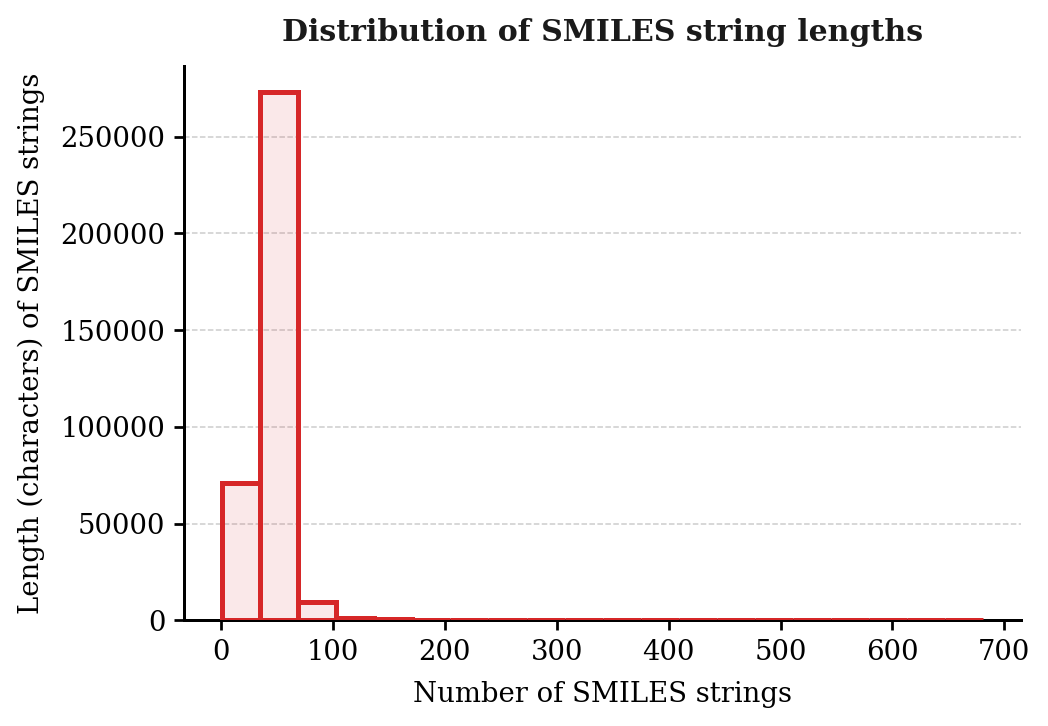

In [46]:
fig, ax = plt.subplots(figsize=(6, 4))
styled_hist(
    ax=ax, 
    data=length_smilses, 
    bins=20, 
    color="#d62728",
    xlabel="Number of SMILES strings", 
    ylabel="Length (characters) of SMILES strings", 
    title="Distribution of SMILES string lengths",
    annotate=False
)

In [168]:
unique_smiles = list(set(smiles))
tokenizer = SMILESTokenizer(max_len=MAX_SEQ_LEN)
tokenizer.train(unique_smiles)
tokenizer.save_vocab(TOKENIZER_PATH)

print(f"Vocab size: {len(tokenizer)}")

Vocab size: 227


In [169]:
original_smiles = unique_smiles[SEED]
print(f"Original SMILES: {original_smiles}")

encoded_ids = tokenizer.encode(original_smiles)
print(f"Encoded IDs: {encoded_ids}")

decoded_smiles = tokenizer.decode(encoded_ids)
print(f"Decoded SMILES: {decoded_smiles}")
print(f"Match: {original_smiles == decoded_smiles}")

Original SMILES: Cc1nn(C)c2ncc(C(=O)N[C@@H]3CC[C@@H]([NH+](C)C)C3)cc12
Encoded IDs: tensor([  1,  24, 223,  12, 224, 224,   7,  24,   8, 223,  13, 224, 223, 223,
          7,  24,   7,  21,  29,   8,  28,  54,  14,  24,  24,  54,   7, 125,
          7,  24,   8,  24,   8,  24,  14,   8, 223, 223,  12,  13,   2,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0, 

[Morgan Fingerprints](https://towardsdatascience.com/a-practical-introduction-to-the-use-of-molecular-fingerprints-in-drug-discovery-7f15021be2b1/), also known as **Extended-Connectivity Fingerprints (ECFPs)**, are widely used fixed-size molecular representations in cheminformatics. They encode a molecule as a binary vector, where each bit indicates the presence or absence of a particular structural pattern. The fingerprint is generated by iteratively analyzing the local environment of each atom and assigning identifiers to the corresponding molecular substructures. These identifiers are then hashed into positions of a fixed-length vector; if a given substructure is detected in the molecule, the corresponding bit is set to 1. In this work, Morgan Fingerprints were generated from SMILES strings using **RDKit** with radius 2 and a vector size of 2048 bits. The radius parameter determines how large the local atomic neighborhood is during substructure extraction: radius 0 considers only the central atom, radius 1 includes directly bonded neighboring atoms, and radius 2 includes atoms up to two bonds away. The resulting 2048-dimensional binary fingerprint was converted into a PyTorch tensor and stored together with the molecular graph as an additional fixed-size molecular descriptor.

A molecular graph provides a structural representation of a molecule that is particularly suitable for graph neural networks. In this representation, atoms are modeled as nodes, while chemical bonds are modeled as edges connecting these nodes. Starting from a SMILES string, the molecule was parsed using RDKit and then converted into a **PyTorch Geometric `Data` object**. The object contains the node feature matrix `x`, the graph connectivity matrix `edge_index`, and the edge feature matrix `edge_attr`. Since chemical bonds are undirected by nature, each bond was added in both directions, resulting in two directed edges for every chemical bond. This bidirectional representation allows message-passing neural networks to propagate information between bonded atoms in both directions during graph processing.

For graph construction, each atom was represented by a **33-dimensional feature vector**. The atom features included both categorical and continuous chemical descriptors. Categorical features were encoded using one-hot encoding with an additional “unknown” category to handle values outside the predefined vocabulary. Specifically, the atom representation included the atomic number, atom degree, formal charge, and hybridization state. The permitted atom types were carbon, nitrogen, oxygen, fluorine, phosphorus, sulfur, chlorine, bromine, and iodine. In addition, two binary indicators were included to specify whether the atom is aromatic and whether it belongs to a ring. The remaining continuous features described the total number of attached hydrogens, atomic mass, and total valence. These values were normalized by fixed constants to keep their numerical ranges comparable to the binary features.

Bond information was encoded using a **14-dimensional edge feature vector**. Similar to atom features, categorical bond descriptors were represented by one-hot encoding with an additional unknown category. The bond type was encoded as one of single, double, triple, or aromatic bond types. Two binary features indicated whether the bond is conjugated and whether it is part of a ring. Finally, stereochemical information was included using a one-hot representation of the RDKit bond stereo type, including non-stereospecific, unspecified, Z/E, cis, and trans configurations. This edge representation allows the graph model not only to learn the molecular connectivity, but also to incorporate important chemical properties of bonds.

If a SMILES string could not be parsed by RDKit, the featurizer returned a placeholder graph with a single zero-valued node feature vector, no edges, and an `is_valid=False` flag. This ensured that invalid molecular strings could be handled consistently without interrupting the preprocessing pipeline. For valid molecules, the final output consisted of the molecular graph, the corresponding Morgan Fingerprint, the original SMILES string, and a validity flag. Thus, the featurization pipeline produced both graph-based and fingerprint-based molecular representations, enabling the use of structural information at the atom-bond level together with a compact fixed-length molecular descriptor.

![Morgan](images/morgan.jpeg)

In [ ]:
original_smiles = smiles[0]
fp_tensor = MolFeaturizer.smiles_to_morgan(original_smiles)
print("Morgan fingerprint tensor:", fp_tensor)
print("Total active bits:", sum(fp_tensor).item())

Morgan fingerprint tensor: tensor([0., 0., 0.,  ..., 0., 0., 0.])
Total active bits: 63.0


In this work, each molecule is represented as a **molecular graph**, where atoms correspond to nodes and chemical bonds correspond to edges. This representation is well suited for graph neural networks because it preserves the molecular topology and allows the model to learn how information is propagated between neighboring atoms. The graph is constructed from a SMILES string using RDKit and stored as a **PyTorch Geometric `Data` object**. In this object, `x` contains the atom, or node, features; `edge_index` stores the connectivity between atoms; and `edge_attr` contains the bond, or edge, features. Since chemical bonds are undirected, each bond is represented by two directed edges, one in each direction, which enables bidirectional message passing during graph neural network training.

In this implementation, atom features are more informative than a simple atomic number. Each atom is encoded as a **33-dimensional feature vector** that describes both its chemical identity and its local structural environment. Several categorical atom properties are represented using one-hot encoding with an additional **unknown** category. This additional category allows the featurizer to handle atom properties that are not included in the predefined list of permitted values, making the preprocessing pipeline more robust. The categorical atom features include atom type, atom degree, formal charge, and hybridization state. The permitted atom types are carbon, nitrogen, oxygen, fluorine, phosphorus, sulfur, chlorine, bromine, and iodine, represented by atomic numbers 6, 7, 8, 9, 15, 16, 17, 35, and 53. Atom degree is encoded for values from 0 to 4, formal charge for values from -2 to 2, and hybridization state for common configurations such as SP, SP2, SP3, SP3D, and SP3D2.

In addition to categorical descriptors, the atom representation includes binary and continuous features. The binary features indicate whether an atom is aromatic and whether it belongs to a ring. These properties are important because aromaticity and ring membership often strongly influence molecular stability, reactivity, and biological activity. The continuous features include the total number of attached hydrogens, atomic mass, and total valence. To keep these values on a comparable numerical scale with the binary and one-hot encoded features, they are normalized by fixed constants: the number of hydrogens is divided by 4, atomic mass by 200, and total valence by 8. As a result, each node representation captures not only the atom type, but also its local chemical state and structural role within the molecule.

Bond features are also explicitly included in the graph representation. Each bond is encoded as a **14-dimensional edge feature vector**. The bond type is represented using one-hot encoding with an additional unknown category and includes single, double, triple, and aromatic bonds. In addition, two binary flags indicate whether the bond is conjugated and whether it is part of a ring. These features provide information about electron delocalization and cyclic structures, which are important for understanding molecular behavior. Finally, stereochemical information is encoded using one-hot encoding with an unknown category. The supported stereo types include no stereochemistry, unspecified stereochemistry, Z, E, cis, and trans configurations. Therefore, the edge representation captures not only the existence of a bond between two atoms, but also its chemical type, structural context, and stereochemical properties.

For each input SMILES string, the featurizer produces a molecular graph together with a Morgan fingerprint. The graph contains node features, edge indices, and edge attributes, while the fingerprint is stored as an additional attribute `fp` inside the PyTorch Geometric `Data` object. This design allows the model to combine detailed atom-bond level information from the graph with a fixed-length fingerprint representation of molecular substructures. If a SMILES string cannot be parsed by RDKit, the implementation returns a placeholder `Data` object with zero-filled node features, an empty edge list, an empty edge feature matrix, a zero Morgan fingerprint, and an `is_valid=False` flag. This makes the preprocessing pipeline robust to invalid molecular inputs and prevents failures during dataset construction.

Overall, this molecular graph featurization approach provides a rich and chemically meaningful representation of each molecule. Node features describe atom identity, charge, hybridization, aromaticity, ring membership, hydrogen count, mass, and valence, while edge features describe bond type, conjugation, ring membership, and stereochemistry. Together with the Morgan fingerprint, this representation combines local atom-bond information with a compact description of molecular substructures, making it suitable for graph neural networks and molecular property prediction tasks.

![Graph](images/graph.jpeg)

In [171]:
original_smiles = smiles[100]
graph_data = MolFeaturizer.smiles_to_graph(original_smiles)
print("Molecular graph:", graph_data)

Molecular graph: Data(x=[25, 33], edge_index=[2, 54], edge_attr=[54, 14], fp=[1, 2048], smiles='Nc1nc2c(nc(Br)n2[C@@H]2O[C@H]3COP(=O)([O-])O[C@@H]3[C@H]2O)c(=O)[nH]1.[Na+]', is_valid=True)


# Datasets

Since a SMILES string is a linear encoding of a graph, the same molecule can be represented by multiple valid SMILES strings depending on the starting atom and the order in which atoms, bonds, branches, and ring closures are visited. In the given procedure, the input SMILES is first parsed into an RDKit molecular graph; the atom indices are then randomly permuted using RenumberAtoms, and the resulting molecule is converted back to a SMILES string with canonicalization disabled (canonical=False). As a result, the output SMILES may differ syntactically from the original string while preserving the same underlying chemical structure. This approach works because the molecular identity is determined by the graph of atoms and bonds, whereas the SMILES string is only one possible serialization of that graph. Therefore, randomizing the atom order changes the graph traversal used during SMILES generation without altering the molecule itself.

Fine-tuning the tokenizer on augmented SMILES is crucial because randomizing the molecular graph traversal generates non-canonical representations that introduce novel syntactical structures, such as higher-order ring closures (e.g., %10, %12) and unusual branching patterns. If the vocabulary is built solely on standard canonical SMILES, these newly generated, rare substrings will be mapped to the <unk> (unknown) token, permanently stripping away vital topological information before it even reaches the model. By expanding the tokenizer's vocabulary to explicitly include these augmentation-induced symbols, we ensure that the neural network flawlessly processes the exact chemical structure without data loss, thereby fully unlocking the regularizing benefits of SMILES randomization.

In [ ]:
def prepare_augmented_smiles_for_tokenizer(smiles_list, n_tries=3):
    augmented_smiles = []
    
    for smi in tqdm(smiles_list, desc="Generating augmentations for vocab"):
        augmented_smiles.append(smi)
        for _ in range(n_tries):
            rand_smi = randomize_smiles(smi)
            augmented_smiles.append(rand_smi)

    return list(set(augmented_smiles))

In [174]:
tokenizer = SMILESTokenizer(max_len=MAX_SEQ_LEN)
tokenizer.load_vocab(TOKENIZER_PATH)

smiles_for_vocab = prepare_augmented_smiles_for_tokenizer(smiles)
tokenizer.train(smiles_for_vocab)
tokenizer.save_vocab(TOKENIZER_PATH)

print(f"The tokenizer has been trained and saved! Dictionary size: {len(tokenizer)}")

Generating augmentations for vocab: 100%|██████████| 355332/355332 [01:35<00:00, 3702.70it/s]


The tokenizer has been trained and saved! Dictionary size: 230


The increase in unique characters or tokens occurs because a molecule is fundamentally a graph, while a SMILES string is just one linear path traversing that graph. Canonical SMILES always follow a strict, standardized path designed to minimize complexity. However, when you augment (randomize) a SMILES string, the algorithm starts at a random atom and takes different branching routes, resulting in completely different syntactical arrangements of the exact same molecule.

Because this traversal order changes, the tokenizer encounters rare symbols and combinations that rarely appear in canonical datasets. For example, random paths often keep multiple rings open simultaneously, forcing the use of higher ring-closure numbers (like `8`, `9`, or `%10`). It also changes the order in which chiral neighbors are read (swapping `@` and `@@`) and creates unusual branching structures with parentheses. Augmentation exposes the tokenizer to these variations so it can build a robust vocabulary and avoid "unknown token" errors during model generation.

In [175]:
smiles_pretrain = pretrain_smiles(PATH_TO_ZINC)
print(f"Count pretrain SMILES: {len(smiles_pretrain)}")

Count pretrain SMILES: 249455


In [176]:
tokenizer = SMILESTokenizer(max_len=MAX_SEQ_LEN)
tokenizer.load_vocab(TOKENIZER_PATH)
print(f"Tokenizer vocabulary size: {len(tokenizer)}")

pretrain_smiles_dataset = pretrain_smiles_dataset = PretrainSMILESDataset(
    smiles_list=smiles_pretrain,
    tokenizer=tokenizer,
    n_augments=8,
    augment_prob=0.3,
)

Tokenizer vocabulary size: 230


Pre-caching pretrain augmentations: 100%|██████████| 249455/249455 [03:02<00:00, 1364.66it/s]

PretrainSMILESDataset ready: 249455 molecules, 8 variants each.


In [177]:
pretrain_graph_dataset = PretrainGraphDataset(
    smiles_pretrain,
    augment_prob=0.1
)

data = pretrain_graph_dataset[0]

print(data)
print(data.x.shape)
print(data.edge_index.shape)
print(data.edge_attr.shape)
print(data.fp.shape)
print(data.x.min(), data.x.max())

Building graph dataset: 100%|██████████| 249455/249455 [01:38<00:00, 2532.77it/s]

Pretrain graphs ready: 249455
Data(x=[24, 33], edge_index=[2, 52], edge_attr=[52, 14], fp=[1, 2048], smiles='CC(C)(C)c1ccc2occ(CC(=O)Nc3ccccc3F)c2c1', is_valid=True)
torch.Size([24, 33])
torch.Size([2, 52])
torch.Size([52, 14])
torch.Size([1, 2048])
tensor(0.) tensor(1.)


# Models

In [5]:
class BaseModel(nn.Module):
    """Base class with utility to count parameters."""
    def count_parameters(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)


## Model 1: MorganMLP

To establish a robust baseline for molecular property prediction, a neural network model based on Morgan molecular fingerprints was employed. Morgan fingerprints are widely used fixed-length molecular representations that encode local atomic environments in a circular manner. Due to their simplicity, interpretability, and strong performance in cheminformatics tasks, they remain a common choice for quantitative structure–activity and structure–property relationship modeling.

Each molecule was represented by a 2048-dimensional Morgan fingerprint vector, which served as input to a multilayer perceptron (MLP). The MorganMLP architecture consists of three fully connected hidden layers with 1024, 512, and 128 neurons, respectively. Rectified Linear Unit (ReLU) activation functions were applied after each hidden linear transformation to introduce non-linearity, while dropout regularization was included after the first two hidden layers to reduce overfitting and improve generalization. The final linear layer maps the learned molecular representation to the target output, making the model applicable to regression or binary prediction tasks depending on the selected loss function and output interpretation.

This architecture combines the chemical information encoded in Morgan fingerprints with the flexibility of deep neural networks, enabling the learning of non-linear relationships between molecular substructures and the target property. Due to its computational efficiency and straightforward implementation, the MorganMLP model serves as a baseline approach for evaluating the predictive performance of fingerprint-based molecular representations.

In [70]:
# ==========================================
# Model 1: Morgan + MLP
# ==========================================
class MorganMLP(BaseModel):
    def __init__(self, input_dim=2048, output_dim=1, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 1024),
            nn.ReLU(),
            nn.Dropout(dropout),
            
            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.Dropout(dropout),
            
            nn.Linear(512, 128),
            nn.ReLU(),

            nn.Linear(128, output_dim)
        )

    def forward(self, x):
        return self.net(x)

In [71]:
MorganMLP()

MorganMLP(
  (net): Sequential(
    (0): Linear(in_features=2048, out_features=1024, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=1024, out_features=512, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.1, inplace=False)
    (6): Linear(in_features=512, out_features=128, bias=True)
    (7): ReLU()
    (8): Linear(in_features=128, out_features=1, bias=True)
  )
)

## Model 2: SmilesCNN

In addition to fingerprint-based molecular representations, a convolutional neural network model operating directly on SMILES strings was implemented. SMILES notation provides a compact textual representation of molecular structures, allowing neural networks to learn structural patterns from sequential molecular data without relying on predefined molecular descriptors. This approach enables the extraction of relevant features from the order and context of SMILES tokens, which may capture chemical information complementary to traditional fingerprint representations.

The SmilesCNN model first converts tokenized SMILES sequences into dense continuous vector representations using an embedding layer. Each token is mapped to a 128-dimensional embedding vector, while padding tokens are ignored through a dedicated padding index. The embedded sequence is then processed by a series of one-dimensional convolutional layers designed to capture local patterns and substructure-like motifs within the SMILES sequence. The convolutional block consists of three consecutive Conv1D layers with 64, 96, and 128 filters, respectively, each using a kernel size of 5. Batch normalization and ReLU activation are applied after each convolutional layer to improve training stability and introduce non-linear feature transformations. Dropout regularization is further used to reduce overfitting.

After convolutional feature extraction, both global max pooling and global average pooling are applied across the sequence dimension. Max pooling captures the most prominent learned features, whereas average pooling summarizes the overall distribution of features along the SMILES sequence. The resulting pooled representations are concatenated into a single 256-dimensional feature vector and passed to a multilayer perceptron. This fully connected prediction head consists of hidden layers with 64 and 32 neurons followed by the final output layer.

Overall, the SmilesCNN architecture provides an end-to-end sequence-based approach for molecular property prediction. By learning directly from tokenized SMILES strings, the model can identify local sequential patterns associated with molecular substructures and use them for downstream prediction tasks. This makes it a useful complementary model to fingerprint-based methods and enables comparison between handcrafted molecular representations and neural sequence-derived features.

In [ ]:
# ==========================================
# Model 2: SMILES + CNN
# ==========================================
class SmilesCNN(BaseModel):
    def __init__(self, vocab_size, embed_dim=128, output_dim=1):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)

        self.conv1 = nn.Conv1d(embed_dim, 64, kernel_size=5, padding=2)
        self.bn1 = nn.BatchNorm1d(64)

        self.conv2 = nn.Conv1d(64, 96, kernel_size=5, padding=2)
        self.bn2 = nn.BatchNorm1d(96)

        self.conv3 = nn.Conv1d(96, 128, kernel_size=5, padding=2)
        self.bn3 = nn.BatchNorm1d(128)

        self.dropout = nn.Dropout(0.1)

        self.mlp = nn.Sequential(
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, output_dim)
        )

    def forward(self, x):
        x = self.embedding(x)
        x = x.transpose(1, 2)

        x = self.dropout(F.relu(self.bn1(self.conv1(x))))
        x = self.dropout(F.relu(self.bn2(self.conv2(x))))
        x = self.dropout(F.relu(self.bn3(self.conv3(x))))

        max_pool = torch.max(x, dim=2)[0]
        avg_pool = torch.mean(x, dim=2)

        x = torch.cat([max_pool, avg_pool], dim=1)

        return self.mlp(x)

In [73]:
SmilesCNN(128)

SmilesCNN(
  (embedding): Embedding(128, 128, padding_idx=0)
  (conv1): Conv1d(128, 64, kernel_size=(5,), stride=(1,), padding=(2,))
  (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv1d(64, 96, kernel_size=(5,), stride=(1,), padding=(2,))
  (bn2): BatchNorm1d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv1d(96, 128, kernel_size=(5,), stride=(1,), padding=(2,))
  (bn3): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout): Dropout(p=0.1, inplace=False)
  (mlp): Sequential(
    (0): Linear(in_features=256, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Linear(in_features=32, out_features=1, bias=True)
  )
)

## Model 3: GINE

A graph neural network based on the [Graph Isomorphism Network with Edge features (GINE)](https://arxiv.org/abs/1810.00826?utm_source=openai) was used to represent molecules as attributed graphs. In this representation, atoms correspond to graph nodes, while chemical bonds correspond to graph edges. Each node is described by a feature vector of dimension 33, and each edge is represented by a 14-dimensional feature vector. Compared with sequence-based or fingerprint-based approaches, graph neural networks operate directly on the molecular graph structure and are therefore able to model atom–bond connectivity in a natural way.

The molecular encoder first projects the initial atom features into a hidden representation space of dimension 256 using a linear node encoder. The resulting node embeddings are then processed by a stack of five GINE convolutional layers. Each GINE layer applies a multilayer perceptron consisting of a linear transformation, GELU activation, and a second linear transformation. Edge attributes are explicitly incorporated into the message-passing process, allowing bond information to influence the learned atomic representations. The trainable epsilon parameter in the GINE convolution further increases the flexibility of node feature aggregation.

After each graph convolutional layer, GraphNorm normalization is applied to stabilize training across molecular graphs of different sizes. GELU activation and dropout regularization are then used to introduce non-linearity and reduce overfitting. A residual connection is added at every layer by summing the updated representation with the previous node representation. This residual design facilitates gradient flow and helps preserve information from earlier message-passing stages.

To obtain a fixed-size molecular representation, node embeddings are aggregated at the graph level using both global mean pooling and global max pooling. Mean pooling captures the average distribution of learned atomic features across the molecule, while max pooling emphasizes the most salient local structural patterns. The two pooled vectors are concatenated, producing a graph-level embedding of dimension 512, which is subsequently used for downstream prediction tasks.

The complete GINEADMET model supports both pretraining and supervised ADMET prediction. In the pretraining mode, a masked-node reconstruction strategy is applied: a random subset of atom features is masked with a learnable mask token or replaced with zeros, and the model is trained to reconstruct the original masked node features. In parallel, a fingerprint decoder predicts a 2048-dimensional molecular fingerprint from the graph-level embedding, encouraging the encoder to learn chemically meaningful global representations. In the supervised ADMET mode, the graph embedding is passed through a prediction head consisting of fully connected layers with GELU activations and dropout, producing the final output for one or more ADMET-related tasks.

Overall, this architecture combines graph-based molecular representation learning with auxiliary reconstruction objectives. By incorporating both atom-level and bond-level information through GINE message passing, the model is capable of learning expressive molecular embeddings that capture local chemical environments as well as global molecular properties. This makes the GINEADMET model suitable for molecular property prediction tasks where structural connectivity and bond information play an important role.

In [74]:
# ==========================================
# Model 3: GINE
# ==========================================
class GINEMolecularEncoder(BaseModel):
    def __init__(
        self,
        node_dim: int = 33,
        edge_dim: int = 14,
        hidden_dim: int = 256,
        num_layers: int = 5,
        dropout: float = 0.1
    ):
        super().__init__()

        self.node_dim = node_dim
        self.edge_dim = edge_dim
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.dropout = dropout

        self.node_encoder = nn.Linear(node_dim, hidden_dim)

        self.convs = nn.ModuleList()
        self.norms = nn.ModuleList()

        for _ in range(num_layers):
            mlp = nn.Sequential(
                nn.Linear(hidden_dim, hidden_dim * 2),
                nn.GELU(),
                nn.Linear(hidden_dim * 2, hidden_dim),
            )
            conv = GINEConv(
                nn=mlp,
                edge_dim=edge_dim,
                train_eps=True
            )
            self.convs.append(conv)
            self.norms.append(GraphNorm(hidden_dim))

        self.graph_dim = hidden_dim * 2

    def encode_nodes_from_x(self, x, edge_index, edge_attr, batch=None):
        x = self.node_encoder(x)
        for conv, norm in zip(self.convs, self.norms):
            h = conv(x, edge_index, edge_attr)
            if batch is not None:
                h = norm(h, batch)
            else:
                h = norm(h)
            h = F.gelu(h)
            h = F.dropout(h, p=self.dropout, training=self.training)
            x = x + h
        return x

    def encode_nodes(self, data):
        return self.encode_nodes_from_x(
            x=data.x,
            edge_index=data.edge_index,
            edge_attr=data.edge_attr,
            batch=getattr(data, "batch", None)
        )

    def pool_graph(self, node_embeddings, batch):
        x_mean = global_mean_pool(node_embeddings, batch)
        x_max = global_max_pool(node_embeddings, batch)
        return torch.cat([x_mean, x_max], dim=1)

    def encode_graph(self, data):
        node_embeddings = self.encode_nodes(data)
        graph_embeddings = self.pool_graph(node_embeddings, data.batch)
        return graph_embeddings

    def forward(self, data):
        node_embeddings = self.encode_nodes(data)
        graph_embeddings = self.pool_graph(node_embeddings, data.batch)
        return node_embeddings, graph_embeddings

In [75]:
class GINEADMETModel(BaseModel):
    def __init__(
        self,
        node_dim: int = 33,
        edge_dim: int = 14,
        hidden_dim: int = 256,
        num_layers: int = 5,
        fp_dim: int = 2048,
        num_admet_tasks: int = 1,
        dropout: float = 0.1,
        mask_prob: float = 0.15,
        replace_with_zero: bool = False
    ):
        super().__init__()

        self.node_dim = node_dim
        self.edge_dim = edge_dim
        self.hidden_dim = hidden_dim
        self.fp_dim = fp_dim
        self.num_admet_tasks = num_admet_tasks
        self.mask_prob = mask_prob
        self.replace_with_zero = replace_with_zero

        self.encoder = GINEMolecularEncoder(
            node_dim=node_dim,
            edge_dim=edge_dim,
            hidden_dim=hidden_dim,
            num_layers=num_layers,
            dropout=dropout
        )

        self.mask_token = nn.Parameter(torch.empty(1, node_dim))
        nn.init.normal_(self.mask_token, mean=0.0, std=0.1)

        self.node_decoder = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, node_dim)
        )

        self.fp_decoder = nn.Sequential(
            nn.Linear(self.encoder.graph_dim, hidden_dim * 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim * 2, fp_dim)
        )

        self.admet_head = nn.Sequential(
            nn.Linear(self.encoder.graph_dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, num_admet_tasks)
        )

    def make_node_mask(self, x):
        num_nodes = x.size(0)
        mask = torch.rand(num_nodes, device=x.device) < self.mask_prob
        if mask.sum() == 0:
            idx = torch.randint(0, num_nodes, (1,), device=x.device)
            mask[idx] = True

        return mask

    def forward_pretrain(self, batch):
        original_x = batch.x
        x_masked = original_x.clone()
        mask = self.make_node_mask(x_masked)
        if self.replace_with_zero:
            x_masked[mask] = 0.0
        else:
            x_masked[mask] = self.mask_token.to(x_masked.dtype)
        node_embeddings = self.encoder.encode_nodes_from_x(
            x=x_masked,
            edge_index=batch.edge_index,
            edge_attr=batch.edge_attr,
            batch=batch.batch
        )
        graph_embeddings = self.encoder.pool_graph(
            node_embeddings,
            batch.batch
        )
        pred_x_masked = self.node_decoder(node_embeddings[mask])
        target_x_masked = original_x[mask]
        pred_fp = self.fp_decoder(graph_embeddings)
        return pred_x_masked, target_x_masked, pred_fp

    def forward_admet(self, batch):
        graph_embeddings = self.encoder.encode_graph(batch)
        out = self.admet_head(graph_embeddings)
        return out

    def forward(self, batch, mode="admet"):
        if mode == "pretrain":
            return self.forward_pretrain(batch)
        elif mode == "admet":
            return self.forward_admet(batch)
        else:
            raise ValueError(f"Unknown mode: {mode}")

In [76]:
GINEMolecularEncoder()

GINEMolecularEncoder(
  (node_encoder): Linear(in_features=33, out_features=256, bias=True)
  (convs): ModuleList(
    (0-4): 5 x GINEConv(nn=Sequential(
      (0): Linear(in_features=256, out_features=512, bias=True)
      (1): GELU(approximate='none')
      (2): Linear(in_features=512, out_features=256, bias=True)
    ))
  )
  (norms): ModuleList(
    (0-4): 5 x GraphNorm(256)
  )
)

In [77]:
GINEADMETModel()

GINEADMETModel(
  (encoder): GINEMolecularEncoder(
    (node_encoder): Linear(in_features=33, out_features=256, bias=True)
    (convs): ModuleList(
      (0-4): 5 x GINEConv(nn=Sequential(
        (0): Linear(in_features=256, out_features=512, bias=True)
        (1): GELU(approximate='none')
        (2): Linear(in_features=512, out_features=256, bias=True)
      ))
    )
    (norms): ModuleList(
      (0-4): 5 x GraphNorm(256)
    )
  )
  (node_decoder): Sequential(
    (0): Linear(in_features=256, out_features=256, bias=True)
    (1): GELU(approximate='none')
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=256, out_features=33, bias=True)
  )
  (fp_decoder): Sequential(
    (0): Linear(in_features=512, out_features=512, bias=True)
    (1): GELU(approximate='none')
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=512, out_features=2048, bias=True)
  )
  (admet_head): Sequential(
    (0): Linear(in_features=512, out_features=256, bias=True)
    (1): 

## Model 4: Mamba

A sequence model based on the [Mamba](https://arxiv.org/abs/2408.05696?utm_source=openai) architecture was used to learn molecular representations directly from tokenized SMILES strings. Unlike convolutional models, which mainly capture local sequential motifs through fixed-size kernels, Mamba-like state space models are designed to model long-range dependencies in sequences with high computational efficiency. This makes the architecture suitable for molecular sequence modeling, where chemically relevant patterns may depend on both local token arrangements and more distant structural context within the SMILES representation.

The model begins with an embedding layer that maps each SMILES token to a dense vector representation of dimension 128. Padding tokens are assigned a dedicated index and are excluded from the final pooling operation. The embedded sequence is then passed through a stack of four Mamba-inspired blocks. Each block operates in the latent sequence space and combines input projection, depthwise one-dimensional convolution, selective state space dynamics, and gated output projection.

Inside each Mamba block, the input representation is first projected into an expanded hidden space. The projected tensor is split into two parts: one branch is processed by the state space module, while the second branch is used as a gating signal. A depthwise convolution is applied to the state-space branch in order to introduce local contextual mixing before the recurrent state update. The convolution output is activated with the SiLU function, which provides smooth non-linear transformations.

The core of the block is a selective state space mechanism implemented through complex-valued transition dynamics. Learnable real and imaginary components define the state transition matrix, while input-dependent parameters are generated for the discretization step and for the input and output projections of the state space model. The discretized dynamics allow the hidden state to be updated along the sequence, enabling the model to capture dependencies across SMILES tokens. A chunked scan procedure is used to compute the state evolution efficiently on CPU while maintaining numerical stability. In addition, a residual MIMO connection is included through a learnable diagonal parameter, and the resulting representation is modulated by the gating branch before being projected back to the original model dimension.

After all Mamba blocks, layer normalization is applied to obtain the final contextualized token representations. For molecular-level prediction, token embeddings are aggregated using masked mean pooling, where only non-padding tokens contribute to the pooled representation. This produces a fixed-size vector representation of the molecule that can be used for downstream tasks.

Two task-specific variants are defined on top of the shared Mamba backbone. In the contrastive pretraining setting, the pooled molecular embedding is passed through a projection head consisting of linear layers, SiLU activation, and dropout, producing a compact representation for contrastive learning. In the supervised ADMET prediction setting, the pooled embedding is passed to a classification or regression head with a hidden linear layer, SiLU activation, dropout regularization, and a final output layer. The number of output units can be adjusted according to the number of prediction tasks.

Overall, the Mamba-based architecture provides an efficient sequence modeling approach for molecular property prediction from SMILES strings. By combining local convolutional mixing with selective state space dynamics, the model is able to capture both short-range token patterns and longer-range dependencies within molecular sequences. This makes it a complementary alternative to convolutional, fingerprint-based, and graph-based molecular models.

![Mamba](images/mamba.jpeg)

In [10]:
# ==========================================
# Model 4: Mamba
# ==========================================
class Mamba3CPUBlock(BaseModel):
    def __init__(self, d_model, d_state=16, d_conv=4, expand=2, num_heads=2):
        super().__init__()
        self.d_model = d_model
        self.d_inner = int(expand * d_model)
        self.d_state = d_state
        self.num_heads = num_heads
        
        self.in_proj = nn.Linear(d_model, self.d_inner * 2)
        
        self.conv1d = nn.Conv1d(
            in_channels=self.d_inner,
            out_channels=self.d_inner,
            kernel_size=d_conv,
            padding=d_conv - 1,
            groups=self.d_inner
        )

        A_real = -torch.exp(torch.randn(num_heads, d_state))
        A_imag = torch.randn(num_heads, d_state)
        self.A_real = nn.Parameter(A_real)
        self.A_imag = nn.Parameter(A_imag)
        
        self.x_proj = nn.Linear(self.d_inner, num_heads * d_state * 4 + num_heads)
        
        self.D = nn.Parameter(torch.ones(self.d_inner))
        self.out_proj = nn.Linear(self.d_inner, d_model)

    def forward(self, x):
        B_batch, L, _ = x.shape
        
        x_proj = self.in_proj(x)
        x_mimo, res = x_proj.chunk(2, dim=-1)
        
        x_conv = x_mimo.transpose(1, 2)
        x_conv = self.conv1d(x_conv)[:, :, :L]
        x_conv = x_conv.transpose(1, 2)
        x_conv = F.silu(x_conv)
        
        x_dbl = self.x_proj(x_conv)

        splits =[
            self.num_heads, # dt
            self.num_heads * self.d_state, # B_real
            self.num_heads * self.d_state, # B_imag
            self.num_heads * self.d_state, # C_real
            self.num_heads * self.d_state # C_imag
        ]
        dt_mimo, B_real, B_imag, C_real, C_imag = torch.split(x_dbl, splits, dim=-1)
        
        dt = F.softplus(dt_mimo) # (Batch, L, num_heads)
        y = self._cpu_complex_scan(x_conv, dt, B_real, B_imag, C_real, C_imag)
        
        y = y + x_mimo * self.D
        y = y * F.silu(res)
        return self.out_proj(y)
    
    def complex_cumsum(self, t, dim):
        return torch.complex(torch.cumsum(t.real, dim=dim), torch.cumsum(t.imag, dim=dim))


    def _cpu_complex_scan(self, x, dt, B_real, B_imag, C_real, C_imag):
        B_batch, L, D_inner = x.shape
        H, S = self.num_heads, self.d_state
        Dh = D_inner // H

        x_heads = x.reshape(B_batch, L, H, Dh)
        B_real = B_real.reshape(B_batch, L, H, S)
        B_imag = B_imag.reshape(B_batch, L, H, S)
        C_real = C_real.reshape(B_batch, L, H, S)
        C_imag = C_imag.reshape(B_batch, L, H, S)

        dt = dt.unsqueeze(-1) # (B,L,H,1)

        A_complex = torch.complex(self.A_real, self.A_imag) # (H,S)
        dA = torch.exp(dt * A_complex) # (B,L,H,S)

        B_complex = torch.complex(B_real, B_imag) # (B,L,H,S)
        dB = dt * B_complex # (B,L,H,S)

        x_c = torch.complex(x_heads, torch.zeros_like(x_heads)) # (B,L,H,Dh)
        dBx = dB.unsqueeze(-1) * x_c.unsqueeze(-2) # (B,L,H,S,Dh)

        chunk_size = 32
        h_list = []
        h_t = torch.zeros_like(dBx[:, 0]) # (B, H, S, Dh)
        
        mask = torch.tril(torch.ones(chunk_size, chunk_size, device=dA.device))
        mask = mask.view(1, 1, 1, chunk_size, chunk_size).bool()
        
        for i in range(0, L, chunk_size):
            chunk_dA = dA[:, i:i+chunk_size] # (B, C, H, S)
            chunk_dBx = dBx[:, i:i+chunk_size] # (B, C, H, S, Dh)
            actual_chunk_size = chunk_dA.shape[1]
            
            eps = 1e-12
            log_dA = torch.log(chunk_dA + eps)
            cum_log_dA = self.complex_cumsum(log_dA, dim=1) # (B, C, H, S)
            C_perm = cum_log_dA.permute(0, 2, 3, 1) 
            
            C_k = C_perm.unsqueeze(-1) # (B, H, S, C, 1)
            C_j = C_perm.unsqueeze(-2) # (B, H, S, 1, C)
            diff = C_k - C_j # (B, H, S, C, C)
            
            chunk_mask = mask[:, :, :, :actual_chunk_size, :actual_chunk_size]
            safe_diff = torch.where(chunk_mask, diff, torch.tensor(-1e4, dtype=diff.dtype, device=diff.device))
            M = torch.exp(safe_diff) # (B, H, S, C, C)
            dBx_perm = chunk_dBx.permute(0, 2, 3, 1, 4) 
            cum_dBx_perm = M @ dBx_perm # (B, H, S, C, Dh)
            cum_dBx = cum_dBx_perm.permute(0, 3, 1, 2, 4)
            chunk_h = cum_dBx + torch.exp(cum_log_dA.unsqueeze(-1)) * h_t.unsqueeze(1)
            h_list.append(chunk_h)
            h_t = chunk_h[:, -1]
        
        h = torch.cat(h_list, dim=1)
        C_complex = torch.complex(C_real, C_imag).unsqueeze(-1) # (B,L,H,S,1)
        y_complex = (C_complex * h).sum(dim=3) # (B,L,H,Dh)
        y = y_complex.real
        return y.reshape(B_batch, L, D_inner)

In [79]:
class Mamba3Backbone(BaseModel):
    def __init__(self, vocab_size, d_model=128, n_layers=4):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model, padding_idx=0)
        self.layers = nn.ModuleList([
            Mamba3CPUBlock(d_model=d_model) for _ in range(n_layers)
        ])
        self.norm = nn.LayerNorm(d_model)

    def forward(self, input_ids):
        x = self.embedding(input_ids)
        for layer in self.layers:
            x = layer(x)
        return self.norm(x) # (Batch, Seq_Len, d_model)

class Mamba3ForContrastivePretraining(BaseModel):
    def __init__(self, backbone, projection_dim: int = 128, dropout: float = 0.1):
        super().__init__()
        self.backbone = backbone
        d_model = backbone.norm.normalized_shape[0]
        self.projector = nn.Sequential(
            nn.Linear(d_model, d_model),
            nn.SiLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, projection_dim),
        )

    def mean_pool(self, hidden_states, input_ids):
        mask = (input_ids != 0).float().unsqueeze(-1)
        pooled = (hidden_states * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1e-9)
        return pooled

    def forward(self, input_ids):
        hidden_states = self.backbone(input_ids)
        pooled = self.mean_pool(hidden_states, input_ids)
        z = self.projector(pooled)
        return z

class Mamba3ForADMET(BaseModel):
    def __init__(self, backbone, n_classes=1, dropout=0.2):
        super().__init__()
        self.backbone = backbone
        d_model = backbone.norm.normalized_shape[0]
        self.clf_head = nn.Sequential(
            nn.Linear(d_model, d_model),
            nn.SiLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, n_classes),
        )

    def forward(self, input_ids):
        hidden_states = self.backbone(input_ids)
        mask = (input_ids != 0).float().unsqueeze(-1)
        pooled = (hidden_states * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1e-9)
        return self.clf_head(pooled)

In [80]:
Mamba3CPUBlock(256)

Mamba3CPUBlock(
  (in_proj): Linear(in_features=256, out_features=1024, bias=True)
  (conv1d): Conv1d(512, 512, kernel_size=(4,), stride=(1,), padding=(3,), groups=512)
  (x_proj): Linear(in_features=512, out_features=130, bias=True)
  (out_proj): Linear(in_features=512, out_features=256, bias=True)
)

In [81]:
Mamba3Backbone(256)

Mamba3Backbone(
  (embedding): Embedding(256, 128, padding_idx=0)
  (layers): ModuleList(
    (0-3): 4 x Mamba3CPUBlock(
      (in_proj): Linear(in_features=128, out_features=512, bias=True)
      (conv1d): Conv1d(256, 256, kernel_size=(4,), stride=(1,), padding=(3,), groups=256)
      (x_proj): Linear(in_features=256, out_features=130, bias=True)
      (out_proj): Linear(in_features=256, out_features=128, bias=True)
    )
  )
  (norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
)

In [82]:
Mamba3ForADMET(Mamba3Backbone(256))

Mamba3ForADMET(
  (backbone): Mamba3Backbone(
    (embedding): Embedding(256, 128, padding_idx=0)
    (layers): ModuleList(
      (0-3): 4 x Mamba3CPUBlock(
        (in_proj): Linear(in_features=128, out_features=512, bias=True)
        (conv1d): Conv1d(256, 256, kernel_size=(4,), stride=(1,), padding=(3,), groups=256)
        (x_proj): Linear(in_features=256, out_features=130, bias=True)
        (out_proj): Linear(in_features=256, out_features=128, bias=True)
      )
    )
    (norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  )
  (clf_head): Sequential(
    (0): Linear(in_features=128, out_features=128, bias=True)
    (1): SiLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=128, out_features=1, bias=True)
  )
)

## Model 5: Transformer

A [Transformer-based sequence model](https://arxiv.org/abs/1911.04738?utm_source=openai) was used to learn molecular representations directly from tokenized SMILES strings. The Transformer architecture is well suited for molecular sequence modeling because its self-attention mechanism can capture dependencies between tokens independently of their distance in the sequence. This is important for SMILES representations, where chemically relevant information may be encoded not only in local token neighborhoods but also through long-range relationships between distant parts of the sequence.

The model uses a shared Transformer backbone that first maps each input token to a dense embedding vector of dimension 128. A dedicated padding token is used to process sequences of different lengths, and padding positions are excluded from attention by means of a key padding mask. The token embeddings are scaled by the square root of the embedding dimension, which is a standard practice in Transformer architectures to stabilize training.

To incorporate information about token order, sinusoidal positional encodings are added to the embeddings. These encodings provide the model with deterministic position-dependent signals and allow the self-attention mechanism to distinguish tokens at different sequence positions. Dropout is applied after positional encoding as a regularization mechanism.

The encoded sequence is then processed by a stack of four Transformer encoder layers. Each encoder layer contains a multi-head self-attention module with four attention heads and a position-wise feed-forward network with hidden dimension 512. GELU activation is used in the feed-forward block, while dropout and layer normalization are applied to improve generalization and training stability. The encoder follows a pre-normalization configuration, which can facilitate optimization in multi-layer Transformer models. After the encoder stack, a final layer normalization produces contextualized token-level embeddings.

On top of the shared Transformer backbone, two task-specific variants are defined. The first variant, `TransformerForMLMAndProperties`, is designed for joint masked language modeling and molecular property prediction. For masked language modeling, a linear language modeling head maps each token-level hidden state to logits over the vocabulary, enabling reconstruction of masked SMILES tokens. This objective encourages the backbone to learn chemically meaningful contextual representations from molecular sequences. In parallel, molecular-level property prediction is performed by applying masked mean pooling over non-padding token embeddings. The pooled representation is passed through a feed-forward property prediction head consisting of a linear layer, GELU activation, dropout, and a final linear layer that outputs the selected number of molecular properties.

The second variant, `TransformerForADMET`, is designed for supervised ADMET prediction. In this case, the contextualized token embeddings produced by the Transformer backbone are aggregated using masked mean pooling, ensuring that padding tokens do not contribute to the molecular representation. The resulting fixed-size molecular embedding is then passed to a linear prediction head, which produces the final output for one or more ADMET-related tasks.

Overall, this Transformer-based architecture provides a flexible framework for molecular representation learning from SMILES strings. The combination of masked language modeling and property prediction enables the model to learn both token-level chemical syntax and molecule-level structure–property relationships. As a result, the learned representations can be effectively adapted to downstream ADMET and molecular property prediction tasks.

![Transformer](images/transformer.jpeg)

In [6]:
# ==========================================
# Model 5: Transformer
# ==========================================
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=512, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)

        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)

        div_term = torch.exp(
            torch.arange(0, d_model, 2).float() *
            (-math.log(10000.0) / d_model)
        )

        pe[:, 0::2] = torch.sin(position * div_term)

        if d_model % 2 == 1:
            pe[:, 1::2] = torch.cos(position * div_term[:-1])
        else:
            pe[:, 1::2] = torch.cos(position * div_term)

        pe = pe.unsqueeze(0)  # (1, max_len, d_model)
        self.register_buffer("pe", pe)

    def forward(self, x):
        """
        x: (Batch, Seq_Len, d_model)
        """
        seq_len = x.size(1)
        x = x + self.pe[:, :seq_len, :]
        return self.dropout(x)

In [7]:
class TransformerBackbone(BaseModel):
    def __init__(
        self,
        vocab_size,
        d_model=128,
        n_layers=4,
        num_heads=4,
        dim_feedforward=512,
        dropout=0.1,
        max_len=512,
        pad_token_id=0
    ):
        super().__init__()
        self.pad_token_id = pad_token_id

        super().__init__()

        self.embedding = nn.Embedding(
            vocab_size,
            d_model,
            padding_idx=pad_token_id
        )

        self.pos_encoder = PositionalEncoding(
            d_model=d_model,
            max_len=max_len,
            dropout=dropout
        )

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=num_heads,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True
        )

        self.layers = nn.TransformerEncoder(
            encoder_layer=encoder_layer,
            num_layers=n_layers
        )
        self.d_model = d_model
        self.norm = nn.LayerNorm(d_model)

    def forward(self, input_ids):
        """
        input_ids: (Batch, Seq_Len)
        """
        padding_mask = input_ids == 0 # (Batch, Seq_Len)
        x = self.embedding(input_ids) # (Batch, Seq_Len, d_model)
        x = x * math.sqrt(self.embedding.embedding_dim)
        x = self.pos_encoder(x)
        x = self.layers(
            x,
            src_key_padding_mask=padding_mask
        )
        return self.norm(x) # (Batch, Seq_Len, d_model)

In [8]:
class TransformerForMLMAndProperties(nn.Module):
    def __init__(
        self,
        backbone,
        vocab_size,
        n_properties=3,
        property_hidden_dim=256,
        dropout=0.1
    ):
        super().__init__()
        self.backbone = backbone
        d_model = backbone.d_model
        self.lm_head = nn.Linear(
            d_model,
            vocab_size,
            bias=False
        )
        self.property_head = nn.Sequential(
            nn.Linear(d_model, property_hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(property_hidden_dim, n_properties)
        )

    def mean_pooling(self, hidden_states, input_ids):
        """
        hidden_states: (B, L, D)
        input_ids: (B, L)
        """
        pad_token_id = self.backbone.pad_token_id
        mask = (input_ids != pad_token_id).float().unsqueeze(-1) # (B, L, 1)
        pooled = (hidden_states * mask).sum(dim=1)
        pooled = pooled / mask.sum(dim=1).clamp(min=1e-9)
        return pooled

    def forward(self, input_ids):
        """
        input_ids: (B, L)
        """
        hidden_states = self.backbone(input_ids) # (B, L, D)
        mlm_logits = self.lm_head(hidden_states) # (B, L, vocab_size)
        pooled = self.mean_pooling(hidden_states, input_ids) # (B, D)
        property_preds = self.property_head(pooled) # (B, n_properties)
        return {
            "mlm_logits": mlm_logits,
            "property_preds": property_preds
        }



class TransformerForADMET(BaseModel):
    def __init__(self, backbone, n_classes=1):
        super().__init__()
        self.backbone = backbone
        self.clf_head = nn.Linear(
            backbone.norm.normalized_shape[0],
            n_classes
        )

    def forward(self, input_ids):
        """
        input_ids: (Batch, Seq_Len)
        """
        hidden_states = self.backbone(input_ids) # hidden_states: (Batch, Seq_Len, d_model)
        mask = (input_ids != 0).float().unsqueeze(-1) # mask: (Batch, Seq_Len, 1)
        pooled = (hidden_states * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1e-9) # pooled: (Batch, d_model)
        return self.clf_head(pooled)

In [86]:
TransformerBackbone(128)

TransformerBackbone(
  (embedding): Embedding(128, 128, padding_idx=0)
  (pos_encoder): PositionalEncoding(
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (layers): TransformerEncoder(
    (layers): ModuleList(
      (0-3): 4 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (linear1): Linear(in_features=128, out_features=512, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=512, out_features=128, bias=True)
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
)

In [87]:
TransformerForADMET(TransformerBackbone(128))

TransformerForADMET(
  (backbone): TransformerBackbone(
    (embedding): Embedding(128, 128, padding_idx=0)
    (pos_encoder): PositionalEncoding(
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (layers): TransformerEncoder(
      (layers): ModuleList(
        (0-3): 4 x TransformerEncoderLayer(
          (self_attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
          )
          (linear1): Linear(in_features=128, out_features=512, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
          (linear2): Linear(in_features=512, out_features=128, bias=True)
          (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
          (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
          (dropout1): Dropout(p=0.1, inplace=False)
          (dropout2): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True

## Model size comparasion

In [197]:
tokenizer = SMILESTokenizer()
tokenizer.load_vocab(TOKENIZER_PATH)
pad_idx = tokenizer.vocab.get(tokenizer.pad_token, 0)
vocab_size = len(tokenizer.vocab)

In [198]:
gine = GINEADMETModel(
    node_dim=33,
    edge_dim=14,
    hidden_dim=256,
    num_layers=5,
    fp_dim=2048,
    num_admet_tasks=1,
    dropout=0.1,
    mask_prob=0.15
)

mamba_backbone = Mamba3Backbone(
    vocab_size=vocab_size,
    d_model=64,
    n_layers=2,
)

mamba = Mamba3ForADMET(
    backbone=mamba_backbone,
    n_classes=1,
    dropout=0.2,
)

transformer_backbone = TransformerBackbone(
    vocab_size=vocab_size,
    d_model=128,
    n_layers=4,
    num_heads=4,
    dim_feedforward=512,
    dropout=0.1,
    max_len=MAX_SEQ_LEN,
    pad_token_id=pad_idx
)

transformer = TransformerForADMET(
    backbone=transformer_backbone,
    n_classes=1,
)

MODELS = { 
    "MorganMLP": MorganMLP(),
    "SmilesCNN": SmilesCNN(128),
    "GINE": gine,
    "Mamba": mamba,
    "Transformer": transformer,
}

In [199]:
MODELS_SIZES = { model_name: model.count_parameters() for model_name, model in MODELS.items()}

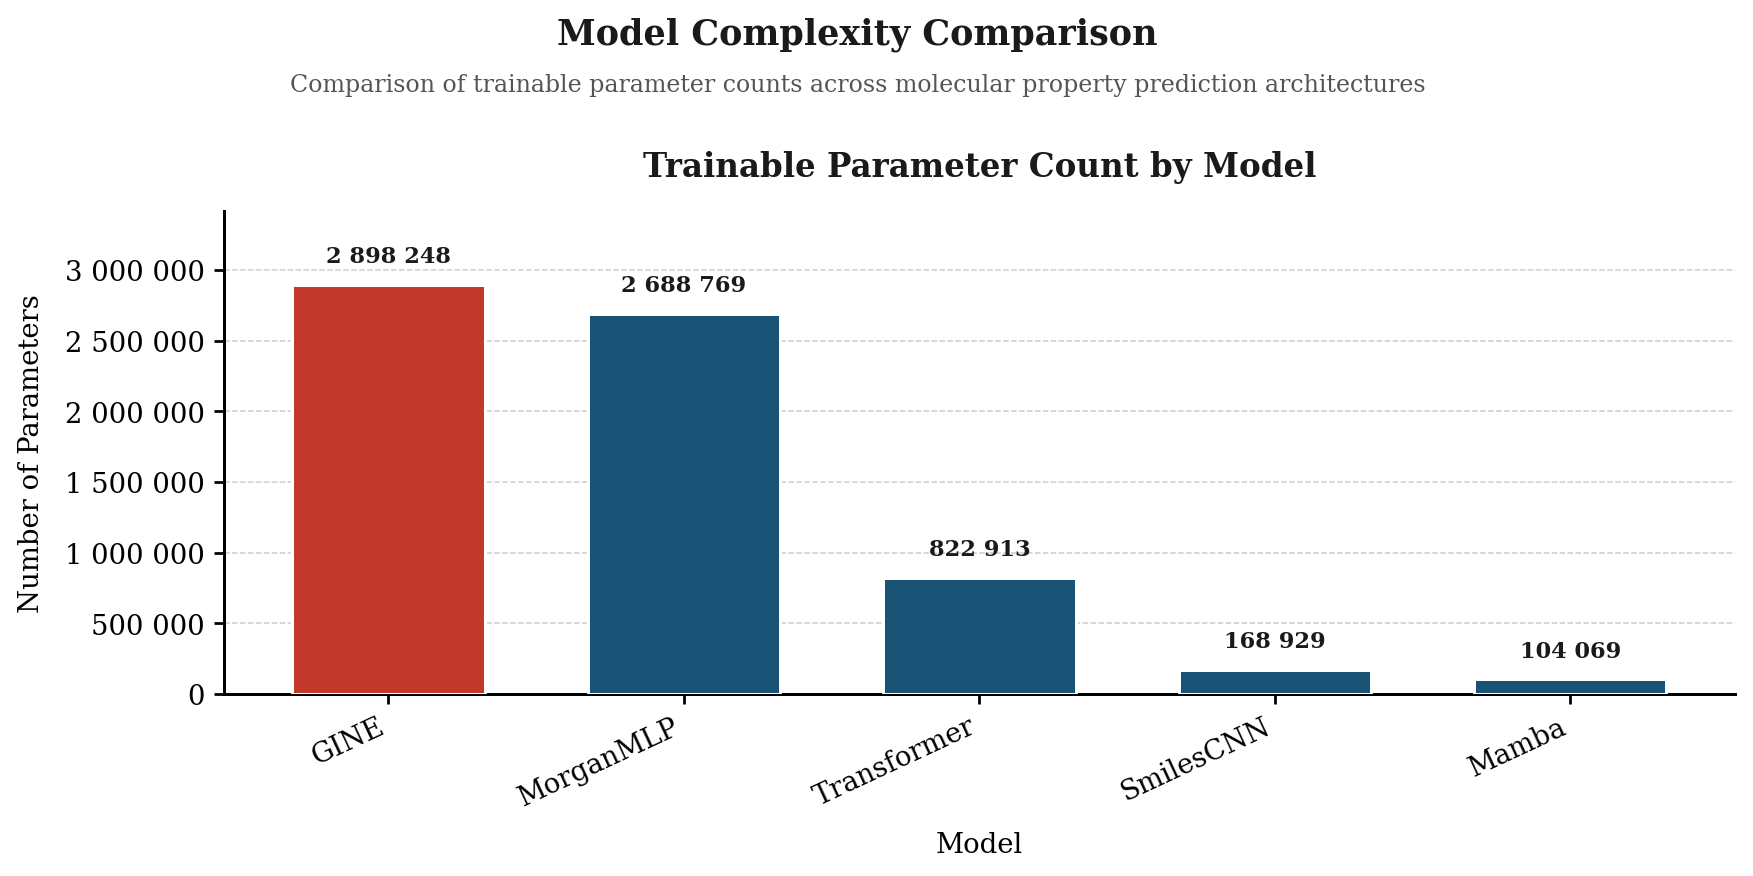

In [200]:
models = list(MODELS_SIZES.keys())
values = np.array(list(MODELS_SIZES.values()))

COLORS = {
    "main": "#1A5276",
    "highlight": "#C0392B",
    "grid": "#CCCCCC",
}

fig, ax = plt.subplots(figsize=(10.5, 5.2))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

order = np.argsort(values)[::-1]
models_sorted = [models[i] for i in order]
values_sorted = values[order]

bar_colors = [
    COLORS["highlight"] if i == 0 else COLORS["main"]
    for i in range(len(values_sorted))
]

bars = ax.bar(
    models_sorted,
    values_sorted,
    color=bar_colors,
    width=0.65,
    edgecolor="white",
    linewidth=1.2,
    zorder=3
)

ax.yaxis.grid(
    True,
    linestyle="--",
    linewidth=0.6,
    color=COLORS["grid"],
    zorder=0
)
ax.set_axisbelow(True)

for bar, value in zip(bars, values_sorted):
    ax.annotate(
        f"{value:,}".replace(",", " "),
        xy=(bar.get_x() + bar.get_width() / 2, value),
        xytext=(0, 7),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold",
        color="#1a1a1a"
    )

ax.set_ylabel("Number of Parameters", fontsize=11, labelpad=8)
ax.set_xlabel("Model", fontsize=11, labelpad=8)

ax.set_title(
    "Trainable Parameter Count by Model",
    fontsize=13,
    fontweight="bold",
    pad=14,
    color="#1a1a1a"
)

ax.yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f"{int(x):,}".replace(",", " "))
)

ax.tick_params(axis="x", rotation=25)
for label in ax.get_xticklabels():
    label.set_ha("right")

ax.set_ylim(0, values_sorted.max() * 1.18)

fig.text(
    0.5, 0.97,
    "Model Complexity Comparison",
    ha="center",
    va="top",
    fontsize=14,
    fontweight="bold",
    color="#1a1a1a",
)

fig.text(
    0.5, 0.91,
    "Comparison of trainable parameter counts across molecular property prediction architectures",
    ha="center",
    va="top",
    fontsize=9.5,
    color="#555555",
)

plt.tight_layout(rect=[0.04, 0.04, 0.98, 0.86])
plt.show()


# Pretraining

In [62]:
def universal_pretrain(
    model,
    train_loader,
    optimizer,
    device,
    step_fn,
    epochs: int = 10,
    scheduler = None,
    step_scheduler_per_batch = True,
    grad_clip_norm = 1.0,
    save_dir = None,
    checkpoint_name = "model",
    save_every_epoch = False,
    save_best = True,
    save_backbone_only = False,
    writer_dir: str | None = None,
    start_epoch=0,
    global_step=0,
):
    best_loss = float("inf")
    if save_dir is not None:
        os.makedirs(save_dir, exist_ok=True)
    if writer_dir is None:
        writer_dir = model.__class__.__name__
    writer = SummaryWriter(log_dir="runs/" + writer_dir)
    model = model.to(device)

    for epoch in range(start_epoch, start_epoch + epochs):
        model.train()
        
        total_loss = 0.0
        epoch_metrics = defaultdict(float)
        total_batches = 0

        pbar = tqdm(train_loader, desc=f"Epoch {epoch + 1}/{start_epoch + epochs}")

        for batch in pbar:
            optimizer.zero_grad(set_to_none=True)
        
            loss, metrics = step_fn(model, batch, device)    
            loss.backward()

            grad_norm = None
            if grad_clip_norm is not None:
                grad_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip_norm)

            optimizer.step()
            
            if scheduler is not None and step_scheduler_per_batch:
                scheduler.step()

            current_lr = optimizer.param_groups[0]["lr"]

            total_loss += loss.item()
            total_batches += 1
            for k, v in metrics.items():
                epoch_metrics[k] += v

            if writer is not None:
                writer.add_scalar("Pretrain/Step/Loss_Total", loss.item(), global_step)
                writer.add_scalar("Pretrain/Step/LR", current_lr, global_step)
                if grad_norm is not None:
                    writer.add_scalar("Pretrain/Step/GradNorm", float(grad_norm), global_step)
                for k, v in metrics.items():
                    writer.add_scalar(f"Pretrain/Step/{k}", v, global_step)

            global_step += 1

            pbar_dict = {"loss": f"{loss.item():.4f}", "lr": f"{current_lr:.2e}"}
            pbar_dict.update({k: f"{v:.4f}" for k, v in list(metrics.items())[:2]}) # показываем 2 доп метрики
            pbar.set_postfix(pbar_dict)

        if scheduler is not None and not step_scheduler_per_batch:
            scheduler.step()

        avg_loss = total_loss / max(total_batches, 1)
        
        print(f"Epoch {epoch + 1}: loss={avg_loss:.4f}, lr={current_lr:.2e}")

        if writer is not None:
            writer.add_scalar("Pretrain/Epoch/Loss_Total", avg_loss, epoch + 1)
            writer.add_scalar("Pretrain/Epoch/LR", current_lr, epoch + 1)
            for k, v in epoch_metrics.items():
                writer.add_scalar(f"Pretrain/Epoch/{k}", v / max(total_batches, 1), epoch + 1)
            writer.flush()

        if save_dir is not None:
            if save_backbone_only and hasattr(model, 'backbone'):
                state_to_save = model.backbone.state_dict()
            else:
                state_to_save = {
                    "epoch": epoch + 1,
                    "global_step": global_step,
                    "model_state_dict": model.state_dict(),
                    "optimizer_state_dict": optimizer.state_dict(),
                    "scheduler_state_dict": scheduler.state_dict() if scheduler else None,
                    "avg_loss": avg_loss,
                }

            if save_every_epoch:
                torch.save(state_to_save, os.path.join(save_dir, f"{checkpoint_name}_epoch_{epoch+1}.pt"))

            if save_best and avg_loss < best_loss:
                best_loss = avg_loss
                best_path = os.path.join(save_dir, f"{checkpoint_name}_best.pt")
                torch.save(state_to_save, best_path)
                print(f"Saved best checkpoint: {best_path}")

            torch.save(state_to_save, os.path.join(save_dir, f"{checkpoint_name}_last.pt"))

    writer.close()

    return model


## Pretraining GINE

The GINE model was pretrained using a self-supervised strategy combining node-level reconstruction and graph-level fingerprint prediction. During pretraining, each molecule was represented as an attributed graph with atom features as node attributes and bond features as edge attributes. For every input graph, a random subset of nodes was selected with a masking probability of 0.15. The original features of the selected nodes were replaced by a learnable mask token, after which the corrupted graph was passed through the GINE encoder. The model was then trained to reconstruct the original features of the masked atoms from the corresponding node embeddings. This objective encourages the encoder to learn chemically meaningful local representations based on the surrounding molecular environment and bond connectivity.

The masked node reconstruction loss was designed to reflect the heterogeneous structure of the atom feature vector. Categorical feature groups, including atom type, degree, formal charge, and hybridization, were optimized using cross-entropy loss. Binary atom-level flags were optimized using binary cross-entropy with logits, while continuous atomic features were reconstructed using Smooth L1 loss. In addition to the node-level objective, a graph-level auxiliary task was introduced: the pooled molecular embedding was used to predict a 2048-dimensional molecular fingerprint. This fingerprint reconstruction objective was optimized using binary cross-entropy with logits and encouraged the graph encoder to capture global molecular information.

The total pretraining loss was computed as a weighted sum of the masked node reconstruction loss and the fingerprint prediction loss, with both weights set to 1.0. The model was optimized using AdamW with a learning rate of \(3 \times 10^{-4}\) and weight decay of \(10^{-4}\). A cosine annealing learning rate scheduler was applied across epochs with a minimum learning rate of \(10^{-6}\). Training was performed with a batch size of 256, and gradient clipping with a maximum norm of 1.0 was used to stabilize optimization. During training, total loss, node reconstruction loss, fingerprint prediction loss, learning rate, gradient norm, and fingerprint prediction statistics were logged. Model checkpoints were saved throughout training, including the best checkpoint selected according to the lowest average pretraining loss.

In [63]:
def molecular_node_feature_loss(pred, target):
    loss_atom = F.cross_entropy(
        pred[:, 0:10],
        target[:, 0:10].argmax(dim=1)
    )

    loss_degree = F.cross_entropy(
        pred[:, 10:16],
        target[:, 10:16].argmax(dim=1)
    )

    loss_charge = F.cross_entropy(
        pred[:, 16:22],
        target[:, 16:22].argmax(dim=1)
    )

    loss_hybrid = F.cross_entropy(
        pred[:, 22:28],
        target[:, 22:28].argmax(dim=1)
    )

    loss_flags = F.binary_cross_entropy_with_logits(
        pred[:, 28:30],
        target[:, 28:30]
    )

    loss_cont = F.smooth_l1_loss(
        pred[:, 30:33].contiguous(),
        target[:, 30:33].contiguous()
    )

    loss_cat = (
        loss_atom +
        loss_degree +
        loss_charge +
        loss_hybrid
    ) / 4.0

    return loss_cat + loss_flags + loss_cont


In [64]:
def gine_step_fn(model, batch, device, lambda_node=1.0, lambda_fp=1.0):
    batch = batch.to(device)
    pred_x_masked, target_x_masked, pred_fp = model(batch, mode="pretrain")

    loss_node = molecular_node_feature_loss(pred_x_masked, target_x_masked)
    target_fp = batch.fp.float().view(pred_fp.size(0), -1)
    loss_fp = F.binary_cross_entropy_with_logits(pred_fp, target_fp)

    loss = lambda_node * loss_node + lambda_fp * loss_fp

    metrics = {
        "Loss_Node": loss_node.item(),
        "Loss_FP": loss_fp.item(),
        "PredFP_Mean": pred_fp.mean().item(),
        "PredFP_Std": pred_fp.std().item(),
    }
    return loss, metrics

In [65]:
gine_model = GINEADMETModel(
    node_dim=33,
    edge_dim=14,
    hidden_dim=256,
    num_layers=5,
    fp_dim=2048,
    num_admet_tasks=1,
    dropout=0.1,
    mask_prob=0.15
)

pretrain_params = list(gine_model.encoder.parameters()) + \
                  list(gine_model.node_decoder.parameters()) + \
                  list(gine_model.fp_decoder.parameters()) + \
                  [gine_model.mask_token]

optimizer = torch.optim.AdamW(
    pretrain_params,
    lr=3e-4,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=50,
    eta_min=1e-6
)

pretrain_loader = PyGDataLoader(
    pretrain_graph_dataset,
    batch_size=256,
    shuffle=True,
    drop_last=True,
    num_workers=0
)


In [66]:
gine_model = universal_pretrain(
    model=gine_model, train_loader=pretrain_loader, optimizer=optimizer,
    device=DEVICE, writer_dir="gine", save_dir="./checkpoints/GINE", scheduler=scheduler,
    step_fn=lambda m, b, d: gine_step_fn(m, b, d, lambda_node=1.0, lambda_fp=1.0),
    step_scheduler_per_batch=False,
    save_backbone_only=False
)

Epoch 1/10:   0%|          | 0/974 [00:00<?, ?it/s]

Epoch 1/10: 100%|██████████| 974/974 [03:13<00:00,  5.04it/s, loss=0.1390, lr=3.00e-04, Loss_Node=0.0726, Loss_FP=0.0664]


Epoch 1: loss=0.1912, lr=3.00e-04
Saved best checkpoint: ./checkpoints/GINE/model_best.pt


Epoch 2/10: 100%|██████████| 974/974 [02:30<00:00,  6.46it/s, loss=0.1121, lr=3.00e-04, Loss_Node=0.0547, Loss_FP=0.0573]


Epoch 2: loss=0.1255, lr=3.00e-04
Saved best checkpoint: ./checkpoints/GINE/model_best.pt


...

Epoch 8: loss=0.0916, lr=2.86e-04
Saved best checkpoint: ./checkpoints/GINE/model_best.pt


Epoch 9/10: 100%|██████████| 974/974 [02:23<00:00,  6.79it/s, loss=0.0772, lr=2.82e-04, Loss_Node=0.0350, Loss_FP=0.0422]


Epoch 9: loss=0.0897, lr=2.82e-04
Saved best checkpoint: ./checkpoints/GINE/model_best.pt


Epoch 10/10: 100%|██████████| 974/974 [02:18<00:00,  7.05it/s, loss=0.0972, lr=2.77e-04, Loss_Node=0.0553, Loss_FP=0.0419]


Epoch 10: loss=0.0877, lr=2.77e-04
Saved best checkpoint: ./checkpoints/GINE/model_best.pt


In [202]:
%reload_ext tensorboard
%tensorboard --logdir=runs

Reusing TensorBoard on port 6006 (pid 69809), started 0:00:30 ago. (Use '!kill 69809' to kill it.)

## Pretraining Mamba

The Mamba-based SMILES encoder was pretrained using a contrastive learning objective. For each molecule, two independently augmented SMILES views were generated and treated as a positive pair, while other molecules within the same mini-batch served as negative examples. SMILES augmentation was applied with a probability of 0.5, and up to eight augmented variants were available for each molecule. The tokenized sequences were padded using a dedicated padding index and then passed through the shared Mamba encoder followed by a projection head, producing two molecular representations \(z_1\) and \(z_2\).

The contrastive objective was based on the normalized temperature-scaled cross-entropy loss (NT-Xent). Before computing similarities, both projected representations were L2-normalized. Pairwise similarities between the two batches of molecular embeddings were calculated using a dot-product similarity matrix and scaled by a temperature parameter of 0.1. The diagonal elements of this matrix corresponded to positive pairs, while all off-diagonal elements represented negative pairs. The loss was computed symmetrically in both directions, from \(z_1\) to \(z_2\) and from \(z_2\) to \(z_1\), and the final objective was defined as the average of the two cross-entropy losses.

This pretraining strategy encourages the Mamba encoder to produce similar embeddings for different SMILES augmentations of the same molecule while separating representations of different molecules in the batch. As a result, the model learns molecular representations that are more invariant to the specific SMILES enumeration and better reflect the underlying chemical structure. During training, the embedding statistics and similarity logits were monitored, including the mean values of \(z_1\), \(z_2\), and the contrastive similarity matrix.

In [68]:
def nt_xent_loss(z1, z2, temperature: float = 0.1):
    """
    z1, z2: [B, D]
    positive pair: z1[i] <-> z2[i]
    negatives: other molecules in batch
    """
    batch_size = z1.size(0)
    z1 = F.normalize(z1, dim=-1)
    z2 = F.normalize(z2, dim=-1)
    logits = z1 @ z2.T
    logits = logits / temperature
    labels = torch.arange(batch_size, device=z1.device)
    loss_12 = F.cross_entropy(logits, labels)
    loss_21 = F.cross_entropy(logits.T, labels)
    loss = 0.5 * (loss_12 + loss_21)
    return loss, logits

In [69]:
def mamba_step_fn(model, batch, device, temperature=0.1):
    x1, x2 = batch
    x1, x2 = x1.to(device, non_blocking=True), x2.to(device, non_blocking=True)
    
    z1, z2 = model(x1), model(x2)
    loss, logits = nt_xent_loss(z1=z1, z2=z2, temperature=temperature)
    
    metrics = {
        "Z1_Mean": z1.mean().item(),
        "Z2_Mean": z2.mean().item(),
        "Logits_Mean": logits.mean().item()
    }
    return loss, metrics

In [70]:
tokenizer = SMILESTokenizer(max_len=MAX_SEQ_LEN)
tokenizer.load_vocab(TOKENIZER_PATH)
vocab_size = len(tokenizer.vocab)
pad_idx = tokenizer.vocab.get(tokenizer.pad_token, 0)

dataset = ContrastiveSMILESDataset(
    smiles_list=smiles_pretrain,
    tokenizer=tokenizer,
    n_augments=8,
    augment_prob=0.5,
)

train_loader = DataLoader(
    dataset,
    batch_size=256,
    shuffle=True,
    drop_last=True,
    num_workers=0,
    pin_memory=False,
    collate_fn=ContrastivePadCollate(pad_idx),
)

Pre-caching contrastive augmentations: 100%|██████████| 249455/249455 [02:57<00:00, 1403.23it/s]

ContrastiveSMILESDataset ready: 249455 molecules, 8 variants each.


In [71]:
mamba_backbone = Mamba3Backbone(
    vocab_size=vocab_size,
    d_model=64,
    n_layers=2,
)

mamba_model = Mamba3ForContrastivePretraining(
    backbone=mamba_backbone,
    projection_dim=64,
    dropout=0.1,
)


optimizer = torch.optim.AdamW(
    mamba_model.parameters(),
    lr=3e-4,
    weight_decay=1e-2,
)

scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    epochs=10,
    max_lr=3e-4,
    steps_per_epoch=len(train_loader),
)

In [72]:
mamba_model = universal_pretrain(
    model=mamba_model, train_loader=train_loader, optimizer=optimizer,
    device=DEVICE, writer_dir="mamba", save_dir="./checkpoints/mamba",
    step_fn=lambda m, b, d: mamba_step_fn(m, b, d, temperature=0.1),
    step_scheduler_per_batch=True, 
    save_backbone_only=True
)

Epoch 1/10:   0%|          | 0/974 [00:00<?, ?it/s]

Epoch 1/10: 100%|██████████| 974/974 [24:27<00:00,  1.51s/it, loss=2.9454, lr=1.20e-05, Z1_Mean=0.0047, Z2_Mean=0.0045]


Epoch 1: loss=4.6546, lr=1.20e-05
Saved best checkpoint: ./checkpoints/mamba/model_best.pt


Epoch 2/10: 100%|██████████| 974/974 [23:57<00:00,  1.48s/it, loss=1.6781, lr=1.20e-05, Z1_Mean=0.0006, Z2_Mean=0.0010] 


Epoch 2: loss=2.2620, lr=1.20e-05
Saved best checkpoint: ./checkpoints/mamba/model_best.pt


...

Epoch 8: loss=0.6720, lr=1.20e-05
Saved best checkpoint: ./checkpoints/mamba/model_best.pt


Epoch 9/10: 100%|██████████| 974/974 [23:49<00:00,  1.47s/it, loss=0.6144, lr=1.20e-05, Z1_Mean=0.0003, Z2_Mean=0.0003]  


Epoch 9: loss=0.6262, lr=1.20e-05
Saved best checkpoint: ./checkpoints/mamba/model_best.pt


Epoch 10/10: 100%|██████████| 974/974 [23:53<00:00,  1.47s/it, loss=0.5684, lr=1.20e-05, Z1_Mean=-0.0004, Z2_Mean=-0.0006]

Epoch 10: loss=0.5848, lr=1.20e-05
Saved best checkpoint: ./checkpoints/mamba/model_best.pt


In [203]:
%reload_ext tensorboard
%tensorboard --logdir=runs

Reusing TensorBoard on port 6006 (pid 69809), started 0:01:00 ago. (Use '!kill 69809' to kill it.)

## Pretraining Transformer

The Transformer model was pretrained using a multi-task objective that combined masked language modeling and molecular property prediction. First, valid SMILES strings were selected by RDKit parsing, and three physicochemical descriptors were calculated for each molecule: Crippen logP, topological polar surface area (TPSA), and molecular weight. These target properties were standardized using `StandardScaler` and used as auxiliary regression targets during pretraining. The SMILES strings were tokenized and processed with a dedicated masked language modeling collator.

For the masked language modeling task, 15% of eligible SMILES tokens were selected for masking, while special tokens such as padding, start-of-sequence, and end-of-sequence tokens were excluded. The selected positions were replaced using a dedicated `<mask>` token, and the model was trained to recover the original token identities. The MLM loss was computed using cross-entropy loss over the vocabulary, with non-masked positions ignored by assigning them the label value `-100`. This objective encourages the Transformer backbone to learn contextual token representations and capture the syntactic and chemical structure of SMILES sequences.

In parallel, the model was trained to predict the three standardized molecular properties from the pooled molecular representation. Token-level hidden states produced by the Transformer backbone were aggregated using masked mean pooling, so that padding tokens did not contribute to the molecular embedding. The pooled representation was passed through a property prediction head, and the property regression loss was computed using mean squared error. The total pretraining objective was defined as a weighted sum of the MLM loss and the property prediction loss, with weights of 1.0 and 0.2, respectively.

The model was optimized using AdamW with an initial learning rate of \(3 \times 10^{-4}\) and weight decay of \(10^{-2}\). A OneCycleLR scheduler was used with a maximum learning rate of \(5 \times 10^{-4}\) over 10 epochs. Training was performed with a batch size of 256. During optimization, both masked language modeling loss and property prediction loss were monitored separately, allowing evaluation of the contribution of each pretraining objective. This pretraining scheme enables the Transformer to learn both token-level SMILES syntax and molecule-level physicochemical information before downstream ADMET fine-tuning.

In [73]:
class MultiTaskPretrainingLoss(nn.Module):
    def __init__(
        self,
        mlm_weight=1.0,
        property_weight=1.0
    ):
        super().__init__()

        self.mlm_weight = mlm_weight
        self.property_weight = property_weight

        self.mlm_loss_fn = nn.CrossEntropyLoss(ignore_index=-100)
        self.property_loss_fn = nn.MSELoss()

    def forward(
        self,
        mlm_logits,
        mlm_labels,
        property_preds,
        property_targets
    ):
        """
        mlm_logits: (B, L, vocab_size)
        mlm_labels: (B, L)

        property_preds: (B, n_properties)
        property_targets: (B, n_properties)
        """

        vocab_size = mlm_logits.size(-1)

        mlm_loss = self.mlm_loss_fn(
            mlm_logits.reshape(-1, vocab_size),
            mlm_labels.reshape(-1)
        )

        property_loss = self.property_loss_fn(
            property_preds,
            property_targets
        )

        total_loss = (
            self.mlm_weight * mlm_loss
            + self.property_weight * property_loss
        )

        return {
            "loss": total_loss,
            "mlm_loss": mlm_loss.detach(),
            "property_loss": property_loss.detach()
        }


In [74]:
def compute_rdkit_properties(smiles_list):
    valid_smiles = []
    properties = []

    for smi in smiles_list:
        mol = Chem.MolFromSmiles(smi)

        if mol is None:
            continue

        clogp = Crippen.MolLogP(mol)
        tpsa = rdMolDescriptors.CalcTPSA(mol)
        mw = Descriptors.MolWt(mol)

        valid_smiles.append(smi)
        properties.append([clogp, tpsa, mw])

    properties = np.array(properties, dtype=np.float32)

    return valid_smiles, properties


In [75]:
valid_smiles, properties_raw = compute_rdkit_properties(smiles_pretrain)
property_scaler = StandardScaler()
properties = property_scaler.fit_transform(properties_raw).astype(np.float32)
input_ids = [tokenizer.encode(smiles) for smiles in valid_smiles]

In [76]:
transformer_backbone = TransformerBackbone(
    vocab_size=len(tokenizer.vocab),
    d_model=128,
    n_layers=4,
    num_heads=4,
    dim_feedforward=512,
    dropout=0.1,
    max_len=MAX_SEQ_LEN,
    pad_token_id=0
)


transformer_model = TransformerForMLMAndProperties(
    backbone=transformer_backbone,
    vocab_size=len(tokenizer.vocab),
    n_properties=3,
    property_hidden_dim=256,
    dropout=0.1
)

criterion = MultiTaskPretrainingLoss(
    mlm_weight=1.0,
    property_weight=0.2
)

optimizer = torch.optim.AdamW(
    transformer_model.parameters(),
    lr=3e-4,
    weight_decay=1e-2
)


In [77]:
if "<mask>" not in tokenizer.vocab:
    tokenizer.vocab["<mask>"] = len(tokenizer.vocab)
    tokenizer.inverse_vocab = {v: k for k, v in tokenizer.vocab.items()}

mask_token_id = tokenizer.vocab["<mask>"]
pad_token_id = tokenizer.vocab["<pad>"]

transformer_train_dataset = SmilesMLMAndPropertiesDataset(
    input_ids=input_ids,
    properties=properties,
)

transformer_collator = SmilesMLMAndPropertiesCollator(
    vocab_size=len(tokenizer),
    mask_token_id=mask_token_id,
    pad_token_id=pad_token_id,
    special_token_ids=[
        tokenizer.vocab["<pad>"],
        tokenizer.vocab["<sos>"],
        tokenizer.vocab["<eos>"],
    ],
    mlm_probability=0.15,
)

transformer_train_loader = DataLoader(
    transformer_train_dataset,
    batch_size=256,
    shuffle=True,
    collate_fn=transformer_collator,
    num_workers=4,
)

scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=5e-4,
    epochs=10,
    steps_per_epoch=len(transformer_train_loader),
)


In [78]:
def transformer_step_fn(model, batch, device, criterion):
    input_ids = batch["input_ids"].to(device)
    mlm_labels = batch["mlm_labels"].to(device)
    properties = batch["properties"].to(device)
    
    outputs = model(input_ids)
    loss_dict = criterion(
        mlm_logits=outputs["mlm_logits"], mlm_labels=mlm_labels,
        property_preds=outputs["property_preds"], property_targets=properties
    )
    
    metrics = {
        "Loss_MLM": loss_dict["mlm_loss"].item(),
        "Loss_Property": loss_dict["property_loss"].item()
    }
    return loss_dict["loss"], metrics

In [79]:
transformer_model = universal_pretrain(
    model=transformer_model, train_loader=transformer_train_loader, optimizer=optimizer,
    device=DEVICE, writer_dir="transformer", save_dir="./checkpoints/transformer",
    step_fn=lambda m, b, d: transformer_step_fn(m, b, d, criterion),
    step_scheduler_per_batch=True,
    save_backbone_only=True
)

Epoch 1/10: 100%|██████████| 975/975 [07:52<00:00,  2.07it/s, loss=2.5305, lr=2.00e-05, Loss_MLM=2.3846, Loss_Property=0.7294]


Epoch 1: loss=3.4083, lr=2.00e-05
Saved best checkpoint: ./checkpoints/transformer/model_best.pt


Epoch 2/10: 100%|██████████| 975/975 [07:51<00:00,  2.07it/s, loss=2.3709, lr=2.00e-05, Loss_MLM=2.2418, Loss_Property=0.6452]


Epoch 2: loss=2.4290, lr=2.00e-05
Saved best checkpoint: ./checkpoints/transformer/model_best.pt


Epoch 3/10: 100%|██████████| 975/975 [07:51<00:00,  2.07it/s, loss=2.3153, lr=2.00e-05, Loss_MLM=2.2120, Loss_Property=0.5162]


...

Epoch 8: loss=2.0782, lr=2.00e-05
Saved best checkpoint: ./checkpoints/transformer/model_best.pt


Epoch 9/10: 100%|██████████| 975/975 [07:46<00:00,  2.09it/s, loss=2.0107, lr=2.00e-05, Loss_MLM=1.9370, Loss_Property=0.3686]


Epoch 9: loss=2.0596, lr=2.00e-05
Saved best checkpoint: ./checkpoints/transformer/model_best.pt


Epoch 10/10: 100%|██████████| 975/975 [07:46<00:00,  2.09it/s, loss=2.1011, lr=2.00e-05, Loss_MLM=2.0229, Loss_Property=0.3913]


Epoch 10: loss=2.0462, lr=2.00e-05
Saved best checkpoint: ./checkpoints/transformer/model_best.pt


In [204]:
%reload_ext tensorboard
%tensorboard --logdir=runs

Reusing TensorBoard on port 6006 (pid 69809), started 0:01:30 ago. (Use '!kill 69809' to kill it.)

# Fine-Tune

In [106]:
tokenizer = SMILESTokenizer()
tokenizer.load_vocab(TOKENIZER_PATH)
pad_idx = tokenizer.vocab.get(tokenizer.pad_token, 0)
vocab_size = len(tokenizer.vocab)
vocab_size

230

In [91]:
def load_model_state_dict(model, path_to_checkpoint, load_only_backbone=False):
    checkpoint = torch.load(
        path_to_checkpoint,
        map_location=DEVICE,
        weights_only=True
    )
    if load_only_backbone:
        return model.backbone.load_state_dict(checkpoint, strict=True)
    return model.load_state_dict(checkpoint["model_state_dict"], strict=True)

In [86]:
gine = GINEADMETModel(
    node_dim=33,
    edge_dim=14,
    hidden_dim=256,
    num_layers=5,
    fp_dim=2048,
    num_admet_tasks=1,
    dropout=0.1,
    mask_prob=0.15
)

path_to_gine = PATH_TO_EXP + "/checkpoints/GINE/model_best.pt"
load_model_state_dict(gine, path_to_gine)

<All keys matched successfully>

In [107]:
mamba_backbone = Mamba3Backbone(
    vocab_size=vocab_size,
    d_model=64,
    n_layers=2,
)

mamba = Mamba3ForADMET(
    backbone=mamba_backbone,
    n_classes=1,
    dropout=0.2,
)

path_to_mamba = PATH_TO_EXP + "/checkpoints/mamba/model_best.pt"
load_model_state_dict(mamba, path_to_mamba, load_only_backbone=True)

<All keys matched successfully>

In [108]:
transformer_backbone = TransformerBackbone(
    vocab_size=vocab_size,
    d_model=128,
    n_layers=4,
    num_heads=4,
    dim_feedforward=512,
    dropout=0.1,
    max_len=MAX_SEQ_LEN,
    pad_token_id=pad_idx
)


transformer = TransformerForADMET(
    backbone=transformer_backbone,
    n_classes=1,
)

path_to_transformer = PATH_TO_EXP + "/checkpoints/transformer/model_best.pt"
load_model_state_dict(transformer, path_to_transformer, load_only_backbone=True)

<All keys matched successfully>

In [109]:
MODELS = { 
    "MorganMLP": MorganMLP(),
    "SmilesCNN": SmilesCNN(128),
    "GINE": gine,
    "Mamba": mamba,
    "Transformer": transformer,
}

In [112]:
CLASSIFICATION_TASKS = {
    "HIA",
    "Pgp",
    "Bioav",
    "BBB",
    "CYP2C19_Inhib",
    "CYP2D6_Inhib",
    "CYP3A4_Inhib",
    "CYP1A2_Inhib",
    "CYP2C9_Inhib",
    "CYP2C9_Substrate",
    "CYP2D6_Substrate",
    "CYP3A4_Substrate",
    "hERG",
}

REGRESSION_TASKS = {
    "Caco2",
    "Lipo",
    "AqSol",
    "PPBR",
    "VDss",
    "Half_Life",
    "Clearance_Hepatocyte",
    "Clearance_Microsome",
    "LD50",
}

ALL_TASKS_FROM_DICTS = list(ADMET_TASKS.values()) + list(TOX_TASKS.values())

TASK_NAMES = [
    task for task in ALL_TASKS_FROM_DICTS
    if os.path.exists(os.path.join(PROCESSED_DIR, task, "train.csv"))
]

task_meta = {}

for task in TASK_NAMES:
    if task in CLASSIFICATION_TASKS:
        task_meta[task] = {
            "task_type": "classification",
            "metric": "roc_auc",
        }
    elif task in REGRESSION_TASKS:
        task_meta[task] = {
            "task_type": "regression",
            "metric": "mae",
        }
    else:
        raise ValueError(f"Unknown task type for task: {task}")

print("Tasks found:", len(TASK_NAMES))
print(TASK_NAMES)

Tasks found: 22
['Caco2', 'HIA', 'Pgp', 'Bioav', 'Lipo', 'AqSol', 'BBB', 'PPBR', 'VDss', 'CYP2C19_Inhib', 'CYP2D6_Inhib', 'CYP3A4_Inhib', 'CYP1A2_Inhib', 'CYP2C9_Inhib', 'CYP2C9_Substrate', 'CYP2D6_Substrate', 'CYP3A4_Substrate', 'Half_Life', 'Clearance_Hepatocyte', 'Clearance_Microsome', 'LD50', 'hERG']


In [113]:
def get_model_type(model_name: str) -> str:
    if model_name == "MorganMLP":
        return "morgan"
    elif model_name in {"SmilesCNN", "Mamba", "Transformer"}:
        return "sequence"
    elif model_name == "GINE":
        return "graph"
    else:
        raise ValueError(f"Unknown model name: {model_name}")

In [114]:
def sequence_pad_collate(batch, pad_idx=0):
    xs, ys = zip(*batch)
    xs = pad_sequence(xs, batch_first=True, padding_value=pad_idx)
    ys = torch.stack(ys, dim=0)
    return xs, ys


def infer_columns(df, smiles_col=None, target_col=None):
    resolved_smiles_col = smiles_col
    resolved_target_col = target_col

    if resolved_smiles_col is None:
        if "Drug" in df.columns:
            resolved_smiles_col = "Drug"
        elif "smiles" in df.columns:
            resolved_smiles_col = "smiles"
        elif "SMILES" in df.columns:
            resolved_smiles_col = "SMILES"
        else:
            raise ValueError(f"Cannot infer SMILES column. Columns: {list(df.columns)}")

    if resolved_target_col is None:
        if "Y" in df.columns:
            resolved_target_col = "Y"
        else:
            ignored = {
                resolved_smiles_col,
                "Drug_ID",
                "id",
                "ID",
                "name",
                "Name",
                "Drug",
                "smiles",
                "SMILES",
            }
            candidates = [c for c in df.columns if c not in ignored]
            if len(candidates) != 1:
                raise ValueError(
                    f"Cannot infer target column. Columns: {list(df.columns)}. "
                    f"Candidates: {candidates}"
                )
            resolved_target_col = candidates[0]

    return resolved_smiles_col, resolved_target_col

In [115]:
def build_admet_loaders(
    task_name,
    model_type,
    mol_featurizer=None,
    tokenizer=None,
    processed_dir=PROCESSED_DIR,
    batch_size=64,
    max_len=MAX_SEQ_LEN,
    num_workers=0,
    target_col=None,
    smiles_col=None,
    pad_idx=0,
):
    if mol_featurizer is None:
        mol_featurizer = MolFeaturizer()

    if model_type == "sequence" and tokenizer is None:
        raise ValueError("tokenizer must be provided for model_type='sequence'")

    task_dir = os.path.join(processed_dir, task_name)

    split_paths = {
        "train": os.path.join(task_dir, "train.csv"),
        "val": os.path.join(task_dir, "val.csv"),
        "test": os.path.join(task_dir, "test.csv"),
    }

    for split, path in split_paths.items():
        if not os.path.exists(path):
            raise FileNotFoundError(f"Missing {split} file: {path}")

    def build_graph_dataset(csv_path):
        df = pd.read_csv(csv_path)
        smi_col, y_col = infer_columns(df, smiles_col, target_col)

        dataset = []
        for _, row in df.iterrows():
            smi = str(row[smi_col])
            y = float(row[y_col])

            data = mol_featurizer.smiles_to_graph(smi)
            data.y = torch.tensor([y], dtype=torch.float32)
            dataset.append(data)

        return dataset

    def build_morgan_dataset(csv_path):
        df = pd.read_csv(csv_path)
        smi_col, y_col = infer_columns(df, smiles_col, target_col)

        xs, ys = [], []
        for _, row in df.iterrows():
            smi = str(row[smi_col])
            y = float(row[y_col])

            fp = mol_featurizer.smiles_to_morgan(smi, n_bits=2048)
            xs.append(fp.float())
            ys.append(y)

        x = torch.stack(xs, dim=0)
        y = torch.tensor(ys, dtype=torch.float32).unsqueeze(1)

        return TensorDataset(x, y)

    def build_sequence_dataset(csv_path):
        df = pd.read_csv(csv_path)
        smi_col, y_col = infer_columns(df, smiles_col, target_col)

        input_ids = []
        targets = []

        old_max_len = getattr(tokenizer, "max_len", None)
        tokenizer.max_len = max_len

        for _, row in df.iterrows():
            smi = str(row[smi_col])
            y = float(row[y_col])

            input_ids.append(tokenizer.encode(smi))
            targets.append(y)

        if old_max_len is not None:
            tokenizer.max_len = old_max_len

        return SequenceRegressionDataset(input_ids, targets)

    if model_type == "graph":
        train_dataset = build_graph_dataset(split_paths["train"])
        val_dataset = build_graph_dataset(split_paths["val"])
        test_dataset = build_graph_dataset(split_paths["test"])

        train_loader = PyGDataLoader(
            train_dataset,
            batch_size=batch_size,
            shuffle=True,
            num_workers=num_workers,
        )
        val_loader = PyGDataLoader(
            val_dataset,
            batch_size=batch_size,
            shuffle=False,
            num_workers=num_workers,
        )
        test_loader = PyGDataLoader(
            test_dataset,
            batch_size=batch_size,
            shuffle=False,
            num_workers=num_workers,
        )

    elif model_type == "morgan":
        train_dataset = build_morgan_dataset(split_paths["train"])
        val_dataset = build_morgan_dataset(split_paths["val"])
        test_dataset = build_morgan_dataset(split_paths["test"])

        train_loader = DataLoader(
            train_dataset,
            batch_size=batch_size,
            shuffle=True,
            num_workers=num_workers,
        )
        val_loader = DataLoader(
            val_dataset,
            batch_size=batch_size,
            shuffle=False,
            num_workers=num_workers,
        )
        test_loader = DataLoader(
            test_dataset,
            batch_size=batch_size,
            shuffle=False,
            num_workers=num_workers,
        )

    elif model_type == "sequence":
        train_dataset = build_sequence_dataset(split_paths["train"])
        val_dataset = build_sequence_dataset(split_paths["val"])
        test_dataset = build_sequence_dataset(split_paths["test"])

        collate = lambda batch: sequence_pad_collate(batch, pad_idx=pad_idx)

        train_loader = DataLoader(
            train_dataset,
            batch_size=batch_size,
            shuffle=True,
            num_workers=num_workers,
            collate_fn=collate,
        )
        val_loader = DataLoader(
            val_dataset,
            batch_size=batch_size,
            shuffle=False,
            num_workers=num_workers,
            collate_fn=collate,
        )
        test_loader = DataLoader(
            test_dataset,
            batch_size=batch_size,
            shuffle=False,
            num_workers=num_workers,
            collate_fn=collate,
        )

    else:
        raise ValueError(f"Unknown model_type: {model_type}")

    return train_loader, val_loader, test_loader


In [116]:
def evaluate_model(model, loader, device, task_type: str, model_type: str):
    model.eval()

    all_preds = []
    all_labels = []

    total_loss = 0.0
    n_batches = 0

    if task_type == "classification":
        loss_fn = nn.BCEWithLogitsLoss()
    elif task_type == "regression":
        loss_fn = nn.SmoothL1Loss()
    else:
        raise ValueError(f"Unknown task_type: {task_type}")

    with torch.no_grad():
        for batch in loader:
            if model_type == "graph":
                batch = batch.to(device)
                logits = model(batch, mode="admet").view(-1)
                labels = batch.y.view(-1).to(device).float()
            else:
                x, labels = batch
                x = x.to(device)
                labels = labels.view(-1).to(device).float()
                logits = model(x).view(-1)

            loss = loss_fn(logits, labels)

            total_loss += loss.item()
            n_batches += 1

            if task_type == "classification":
                preds = torch.sigmoid(logits)
            else:
                preds = logits

            all_preds.append(preds.detach().cpu())
            all_labels.append(labels.detach().cpu())

    avg_loss = total_loss / max(n_batches, 1)

    all_preds = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()

    if task_type == "classification":
        if len(np.unique(all_labels)) < 2:
            return {
                "roc_auc": float("nan"),
                "avg_precision": float("nan"),
                "loss": avg_loss,
            }

        return {
            "roc_auc": float(roc_auc_score(all_labels, all_preds)),
            "avg_precision": float(average_precision_score(all_labels, all_preds)),
            "loss": float(avg_loss),
        }

    else:
        spear, _ = spearmanr(all_labels, all_preds)

        if np.isnan(spear):
            spear = float("nan")

        return {
            "mae": float(mean_absolute_error(all_labels, all_preds)),
            "spearman": float(spear),
            "loss": float(avg_loss),
        }

In [205]:
def finetune_one_task(
    model,
    train_loader,
    val_loader,
    device: str,
    task_type: str,
    model_type: str,
    epochs: int = 50,
    lr: float = 1e-3,
    weight_decay: float = 1e-4,
    patience: int = 10,
    grad_clip: float = 1.0,
    verbose: bool = False,
    writer=None,
    log_prefix: str = "",
    history_path: str = None,
):
    model = model.to(device)

    if task_type == "classification":
        loss_fn = nn.BCEWithLogitsLoss()
        primary_key = "roc_auc"
        best_primary = -float("inf")
        is_better = lambda new, best: new > best
    elif task_type == "regression":
        loss_fn = nn.SmoothL1Loss()
        primary_key = "mae"
        best_primary = float("inf")
        is_better = lambda new, best: new < best
    else:
        raise ValueError(f"Unknown task_type: {task_type}")

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay,
    )

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=max(epochs, 1),
        eta_min=lr * 1e-2,
    )

    best_val_metrics = None
    best_state = None
    best_epoch = None
    no_improve = 0
    global_step = 0

    history = []
    last_epoch = 0

    for epoch in range(1, epochs + 1):
        last_epoch = epoch
        model.train()

        total_loss = 0.0
        n_batches = 0

        for batch in train_loader:
            optimizer.zero_grad(set_to_none=True)

            if model_type == "graph":
                batch = batch.to(device)
                logits = model(batch, mode="admet").view(-1)
                labels = batch.y.view(-1).to(device).float()
            else:
                x, labels = batch
                x = x.to(device)
                labels = labels.view(-1).to(device).float()
                logits = model(x).view(-1)

            loss = loss_fn(logits, labels)
            loss.backward()

            if grad_clip is not None and grad_clip > 0:
                torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)

            optimizer.step()

            total_loss += loss.item()
            n_batches += 1
            global_step += 1

            if writer is not None:
                writer.add_scalar(f"{log_prefix}/batch/train_loss", loss.item(), global_step)

        scheduler.step()

        avg_train_loss = total_loss / max(n_batches, 1)

        val_metrics = evaluate_model(
            model=model,
            loader=val_loader,
            device=device,
            task_type=task_type,
            model_type=model_type,
        )

        primary_val = val_metrics.get(primary_key, float("nan"))
        current_lr = optimizer.param_groups[0]["lr"]

        epoch_record = {
            "epoch": epoch,
            "train_loss": float(avg_train_loss),
            "lr": float(current_lr),
            "val": {
                k: None if v is None or np.isnan(v) else float(v)
                for k, v in val_metrics.items()
            },
        }
        history.append(epoch_record)

        if history_path is not None:
            with open(history_path, "w", encoding="utf-8") as f:
                json.dump(history, f, indent=2, ensure_ascii=False)

        if writer is not None:
            writer.add_scalar(f"{log_prefix}/epoch/train_loss", avg_train_loss, epoch)
            writer.add_scalar(f"{log_prefix}/epoch/lr", current_lr, epoch)

            for metric_name, value in val_metrics.items():
                if value is not None and not np.isnan(value):
                    writer.add_scalar(f"{log_prefix}/epoch/val_{metric_name}", value, epoch)

        if verbose:
            print(
                f"Epoch {epoch:03d} | "
                f"train_loss={avg_train_loss:.4f} | "
                f"lr={current_lr:.2e} | "
                f"val={val_metrics}"
            )

        if not np.isnan(primary_val) and is_better(primary_val, best_primary):
            best_primary = primary_val
            best_val_metrics = val_metrics
            best_state = copy.deepcopy(model.state_dict())
            best_epoch = epoch
            no_improve = 0

            if writer is not None:
                writer.add_scalar(f"{log_prefix}/best/val_{primary_key}", best_primary, epoch)
        else:
            no_improve += 1
            if no_improve >= patience:
                if verbose:
                    print(f"Early stopping at epoch {epoch}")
                break

    last_state = copy.deepcopy(model.state_dict())

    return best_val_metrics, best_state, best_epoch, last_state, last_epoch, history

In [ ]:
def run_all_finetune(
    models: dict,
    task_names,
    task_meta,
    device,
    mol_featurizer,
    tokenizer,
    processed_dir,
    batch_size: int = 64,
    epochs: int = 50,
    lr: float = 1e-3,
    weight_decay: float = 1e-4,
    patience: int = 10,
    grad_clip: float = 1.0,
    verbose: bool = False,
    log_dir: str = "./runs/admet_finetune",
    save_dir: str = "./checkpoints/finetune",
    save_last: bool = True,
    num_workers: int = 0,
    pad_idx: int = 0,
):
    os.makedirs(log_dir, exist_ok=True)
    os.makedirs(save_dir, exist_ok=True)

    writer = SummaryWriter(log_dir=log_dir)
    results = {model_name: {} for model_name in models.keys()}

    initial_states = {
        model_name: copy.deepcopy(model.state_dict())
        for model_name, model in models.items()
    }

    total = len(models) * len(task_names)
    pbar = tqdm(total=total, desc="Fine-tuning")

    try:
        for model_name, model in models.items():
            model_type = get_model_type(model_name)

            for task_idx, task_name in enumerate(task_names):
                meta = task_meta[task_name]
                task_type = meta["task_type"]
                primary_key = meta["metric"]

                pbar.set_description(f"{model_name} / {task_name}")

                model.load_state_dict(initial_states[model_name])
                model = model.to(device)

                train_loader, val_loader, test_loader = build_admet_loaders(
                    task_name=task_name,
                    model_type=model_type,
                    mol_featurizer=mol_featurizer,
                    tokenizer=tokenizer,
                    processed_dir=processed_dir,
                    batch_size=batch_size,
                    max_len=MAX_SEQ_LEN,
                    num_workers=num_workers,
                    pad_idx=pad_idx,
                )

                log_prefix = f"{model_name}/{task_name}"

                task_save_dir = os.path.join(save_dir, model_name, task_name)
                os.makedirs(task_save_dir, exist_ok=True)
                history_path = os.path.join(task_save_dir, "metrics_epoch_history.json")

                val_metrics, best_state, best_epoch, last_state, last_epoch, history = finetune_one_task(
                    model=model,
                    train_loader=train_loader,
                    val_loader=val_loader,
                    device=device,
                    task_type=task_type,
                    model_type=model_type,
                    epochs=epochs,
                    lr=lr,
                    weight_decay=weight_decay,
                    patience=patience,
                    grad_clip=grad_clip,
                    verbose=verbose,
                    writer=writer,
                    log_prefix=log_prefix,
                    history_path=history_path,
                )
                if last_state is not None:
                    model.load_state_dict(last_state)

                test_metrics = evaluate_model(
                    model=model,
                    loader=test_loader,
                    device=device,
                    task_type=task_type,
                    model_type=model_type,
                )

                results[model_name][task_name] = {
                    "val": val_metrics,
                    "test": test_metrics,
                    "best_epoch": best_epoch,
                    "last_epoch": last_epoch,
                }

                if writer is not None:
                    if test_metrics is not None:
                        for metric_name, value in test_metrics.items():
                            if value is not None and not np.isnan(value):
                                writer.add_scalar(
                                    f"{log_prefix}/test/{metric_name}",
                                    value,
                                    last_epoch if last_epoch is not None else 0,
                                )

                ckpt_path = None

                if save_last and last_state is not None:
                    ckpt_path = os.path.join(task_save_dir, "model_last.pt")
                    torch.save(
                        {
                            "model_name": model_name,
                            "task_name": task_name,
                            "task_type": task_type,
                            "last_epoch": last_epoch,
                            "best_epoch": best_epoch,
                            "test_metrics": test_metrics,
                            "model_state_dict": last_state,
                        },
                        ckpt_path,
                    )

                    summary_path = os.path.join(task_save_dir, "test_summary.json")
                    summary_data = {
                        "model_name": model_name,
                        "task_name": task_name,
                        "best_epoch": best_epoch,
                        "last_epoch": last_epoch,
                        "best_val_metrics": val_metrics,
                        "test_metrics": test_metrics
                    }
                    
                    for d in [summary_data["best_val_metrics"], summary_data["test_metrics"]]:
                        if d is not None:
                            for k, v in d.items():
                                if v is None or np.isnan(v):
                                    d[k] = None

                    with open(summary_path, "w", encoding="utf-8") as f:
                        json.dump(summary_data, f, indent=2, ensure_ascii=False)

                if verbose:
                    print(f"\nDone {model_name}/{task_name}")
                    print("Last epoch:", last_epoch)
                    print("Val:", val_metrics)
                    print("Test:", test_metrics)
                    if ckpt_path is not None:
                        print("Saved model:", ckpt_path)
                    print("-" * 80)

                writer.flush()
                pbar.update(1)

    finally:
        pbar.close()
        writer.close()

    return results


In [72]:
results = run_all_finetune(
    models=MODELS,
    task_names=ALL_TASKS_FROM_DICTS,
    task_meta=task_meta,
    device=DEVICE,
    mol_featurizer=MolFeaturizer,
    tokenizer=tokenizer,
    processed_dir=PROCESSED_DIR,
    batch_size=128,
    epochs=10,
    lr=1e-4,
    weight_decay=1e-4,
    patience=5,
    grad_clip=1.0,
    log_dir="./runs/admet_finetune",
    save_dir="./checkpoints/finetune",
    save_last=True,
    num_workers=0,
    pad_idx=pad_idx,
)

MorganMLP / AqSol:   5%|▍         | 5/110 [00:04<01:55,  1.10s/it][09:20:22] WARNING: not removing hydrogen atom without neighbors
[09:20:22] WARNING: not removing hydrogen atom without neighbors
[09:20:22] WARNING: not removing hydrogen atom without neighbors
[09:20:22] WARNING: not removing hydrogen atom without neighbors
[09:20:22] WARNING: not removing hydrogen atom without neighbors
[09:20:22] WARNING: not removing hydrogen atom without neighbors
[09:20:22] WARNING: not removing hydrogen atom without neighbors
[09:20:22] WARNING: not removing hydrogen atom without neighbors
[09:20:22] WARNING: not removing hydrogen atom without neighbors
[09:20:22] WARNING: not removing hydrogen atom without neighbors
[09:20:23] WARNING: not removing hydrogen atom without neighbors
[09:20:23] WARNING: not removing hydrogen atom without neighbors
[09:20:23] WARNING: not removing hydrogen atom without neighbors
[09:20:23] WARNING: not removing hydrogen atom without neighbors
[09:20:23] WARNING: not 

In [207]:
%reload_ext tensorboard
%tensorboard --logdir=runs

Reusing TensorBoard on port 6006 (pid 69809), started 0:06:15 ago. (Use '!kill 69809' to kill it.)

# Results

In [109]:
def collect_results_df(root="checkpoints/finetune"):
    root = Path(root)
    rows = []

    for summary_path in sorted(root.glob("*/*/test_summary.json")):
        with summary_path.open("r", encoding="utf-8") as f:
            data = json.load(f)

        model_from_path = summary_path.parts[-3]
        task_from_path = summary_path.parts[-2]

        row = {
            "model_name": data.get("model_name", model_from_path),
            "task_name": data.get("task_name", task_from_path),
            "best_epoch": data.get("best_epoch"),
            "last_epoch": data.get("last_epoch"),
            "summary_path": str(summary_path),
        }

        for metric_name, value in data.get("best_val_metrics", {}).items():
            row[f"val_{metric_name}"] = value

        for metric_name, value in data.get("test_metrics", {}).items():
            row[f"test_{metric_name}"] = value

        rows.append(row)

    df = pd.DataFrame(rows)

    if not df.empty:
        df = df.sort_values(["model_name", "task_name"]).reset_index(drop=True)

    return df


In [110]:
df = collect_results_df()
df

,model_name,task_name,best_epoch,last_epoch,summary_path,val_mae,val_spearman,val_loss,test_mae,test_spearman,test_loss,val_roc_auc,val_avg_precision,test_roc_auc,test_avg_precision
0,GINE,AqSol,8,10,checkpoints/finetune/GINE/AqSol/test_summary.json,0.899714,0.852489,0.527101,1.010634,0.774081,0.625322,NaN,NaN,NaN,NaN
1,GINE,BBB,9,10,checkpoints/finetune/GINE/BBB/test_summary.json,NaN,NaN,0.387017,NaN,NaN,0.290237,0.785612,0.951174,0.922157,0.958900
2,GINE,Bioav,7,10,checkpoints/finetune/GINE/Bioav/test_summary.json,NaN,NaN,0.523236,NaN,NaN,0.541905,0.689796,0.881246,0.669271,0.874976
3,GINE,CYP1A2_Inhib,10,10,checkpoints/finetune/GINE/CYP1A2_Inhib/test_su...,NaN,NaN,0.333668,NaN,NaN,0.343805,0.933561,0.931928,0.931762,0.933645
4,GINE,CYP2C19_Inhib,10,10,checkpoints/finetune/GINE/CYP2C19_Inhib/test_s...,NaN,NaN,0.413841,NaN,NaN,0.430254,0.894540,0.894772,0.888235,0.858967
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
105,Transformer,Lipo,7,10,checkpoints/finetune/Transformer/Lipo/test_sum...,0.903456,0.281178,0.472021,0.913966,0.312118,0.509224,NaN,NaN,NaN,NaN
106,Transformer,PPBR,10,10,checkpoints/finetune/Transformer/PPBR/test_sum...,84.104218,0.238696,83.831554,81.695396,0.373944,81.512856,NaN,NaN,NaN,NaN
107,Transformer,Pgp,10,10,checkpoints/finetune/Transformer/Pgp/test_summ...,NaN,NaN,0.566947,NaN,NaN,0.682393,0.818004,0.786264,0.693497,0.563402
108,Transformer,VDss,1,6,checkpoints/finetune/Transformer/VDss/test_sum...,1.523950,0.289786,1.201328,2.508270,0.463869,2.110582,NaN,NaN,NaN,NaN


In [111]:
def plot_admet_category_plots(
    df,
    task_categories=None,
    model_col="model_name",
    task_col="task_name",
    figsize_per_subplot=(5.2, 3.8),
    show=True,
):
    if task_categories is None:
        task_categories = {
            "Absorption": [
                "Caco2",
                "HIA",
                "Pgp",
                "Bioav",
            ],
            "Distribution": [
                "BBB",
                "PPBR",
                "VDss",
            ],
            "Metabolism": [
                "CYP1A2_Inhib",
                "CYP2C9_Inhib",
                "CYP2C9_Substrate",
                "CYP2C19_Inhib",
                "CYP2D6_Inhib",
                "CYP2D6_Substrate",
                "CYP3A4_Inhib",
                "CYP3A4_Substrate",
            ],
            "Excretion": [
                "Clearance_Hepatocyte",
                "Clearance_Microsome",
                "Half_Life",
            ],
            "Toxicity": [
                "hERG",
                "LD50",
                "AqSol",
                "Lipo",
            ],
        }

    metric_priority = [
        ("test_roc_auc", True, "ROC-AUC"),
        ("test_spearman", True, "Spearman"),
        ("test_mae", False, "MAE"),
        ("test_loss", False, "Loss"),
    ]

    available_metrics = [m for m, _, _ in metric_priority if m in df.columns]
    if not available_metrics:
        raise ValueError("Unknown metric")

    required_cols = {model_col, task_col}
    missing_cols = required_cols - set(df.columns)
    if missing_cols:
        raise ValueError(f"{sorted(missing_cols)}")

    def choose_metric(task_df):
        for metric_col, higher_is_better, metric_label in metric_priority:
            if metric_col in task_df.columns and task_df[metric_col].notna().any():
                return metric_col, higher_is_better, metric_label
        return None, None, None

    figures = {}

    for category, category_tasks in task_categories.items():
        category_df = df[df[task_col].isin(category_tasks)].copy()
        present_tasks = [
            task for task in category_tasks
            if task in set(category_df[task_col])
        ]

        n_tasks = max(len(present_tasks), 1)
        ncols = min(3, n_tasks)
        nrows = math.ceil(n_tasks / ncols)

        fig_width = figsize_per_subplot[0] * ncols
        fig_height = figsize_per_subplot[1] * nrows
        fig, axes = plt.subplots(
            nrows=nrows,
            ncols=ncols,
            figsize=(fig_width, fig_height),
            squeeze=False,
        )
        axes_flat = axes.ravel()

        fig.suptitle(category, fontsize=16, fontweight="bold", y=1.02)

        if not present_tasks:
            ax = axes_flat[0]
            ax.axis("off")
            ax.text(
                0.5,
                0.5,
                f"No data for {category}",
                ha="center",
                va="center",
                fontsize=13,
                fontweight="bold",
            )
            for ax in axes_flat[1:]:
                ax.axis("off")
            figures[category] = fig
            continue

        for ax_idx, task_name in enumerate(present_tasks):
            ax = axes_flat[ax_idx]
            task_df = category_df[category_df[task_col] == task_name].copy()

            metric_col, higher_is_better, metric_label = choose_metric(task_df)
            if metric_col is None:
                ax.axis("off")
                ax.set_title(task_name)
                ax.text(
                    0.5,
                    0.5,
                    "No supported metric",
                    ha="center",
                    va="center",
                )
                continue

            plot_df = (
                task_df[[model_col, metric_col]]
                .dropna(subset=[metric_col])
                .sort_values(metric_col, ascending=not higher_is_better)
                .reset_index(drop=True)
            )

            if plot_df.empty:
                ax.axis("off")
                ax.set_title(task_name)
                ax.text(0.5, 0.5, "No metric values", ha="center", va="center")
                continue

            best_value = (
                plot_df[metric_col].max()
                if higher_is_better
                else plot_df[metric_col].min()
            )
            is_best = np.isclose(plot_df[metric_col].to_numpy(), best_value, equal_nan=False)

            colors = ["#1f77b4" if flag else "#c7d7ee" for flag in is_best]
            edge_colors = ["#0b3d75" if flag else "#8aa9cc" for flag in is_best]
            line_widths = [2.5 if flag else 0.8 for flag in is_best]

            bars = ax.bar(
                plot_df[model_col],
                plot_df[metric_col],
                color=colors,
                edgecolor=edge_colors,
                linewidth=line_widths,
            )

            for bar, value, flag in zip(bars, plot_df[metric_col], is_best):
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    bar.get_height(),
                    f"{value:.3f}",
                    ha="center",
                    va="bottom" if value >= 0 else "top",
                    fontsize=9,
                    fontweight="bold" if flag else "normal",
                    color="#0b3d75" if flag else "#555555",
                )

            for tick_label, flag in zip(ax.get_xticklabels(), is_best):
                tick_label.set_rotation(35)
                tick_label.set_ha("right")
                tick_label.set_fontweight("bold" if flag else "normal")
                tick_label.set_color("#0b3d75" if flag else "#555555")

            ax.set_title(f"{task_name} — {metric_label}", fontweight="bold")
            ax.set_ylabel(metric_label)
            ax.grid(axis="y", alpha=0.25)
            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)

        for ax in axes_flat[len(present_tasks):]:
            ax.axis("off")

        fig.tight_layout()
        figures[category] = fig

    if show:
        plt.show()

    return figures


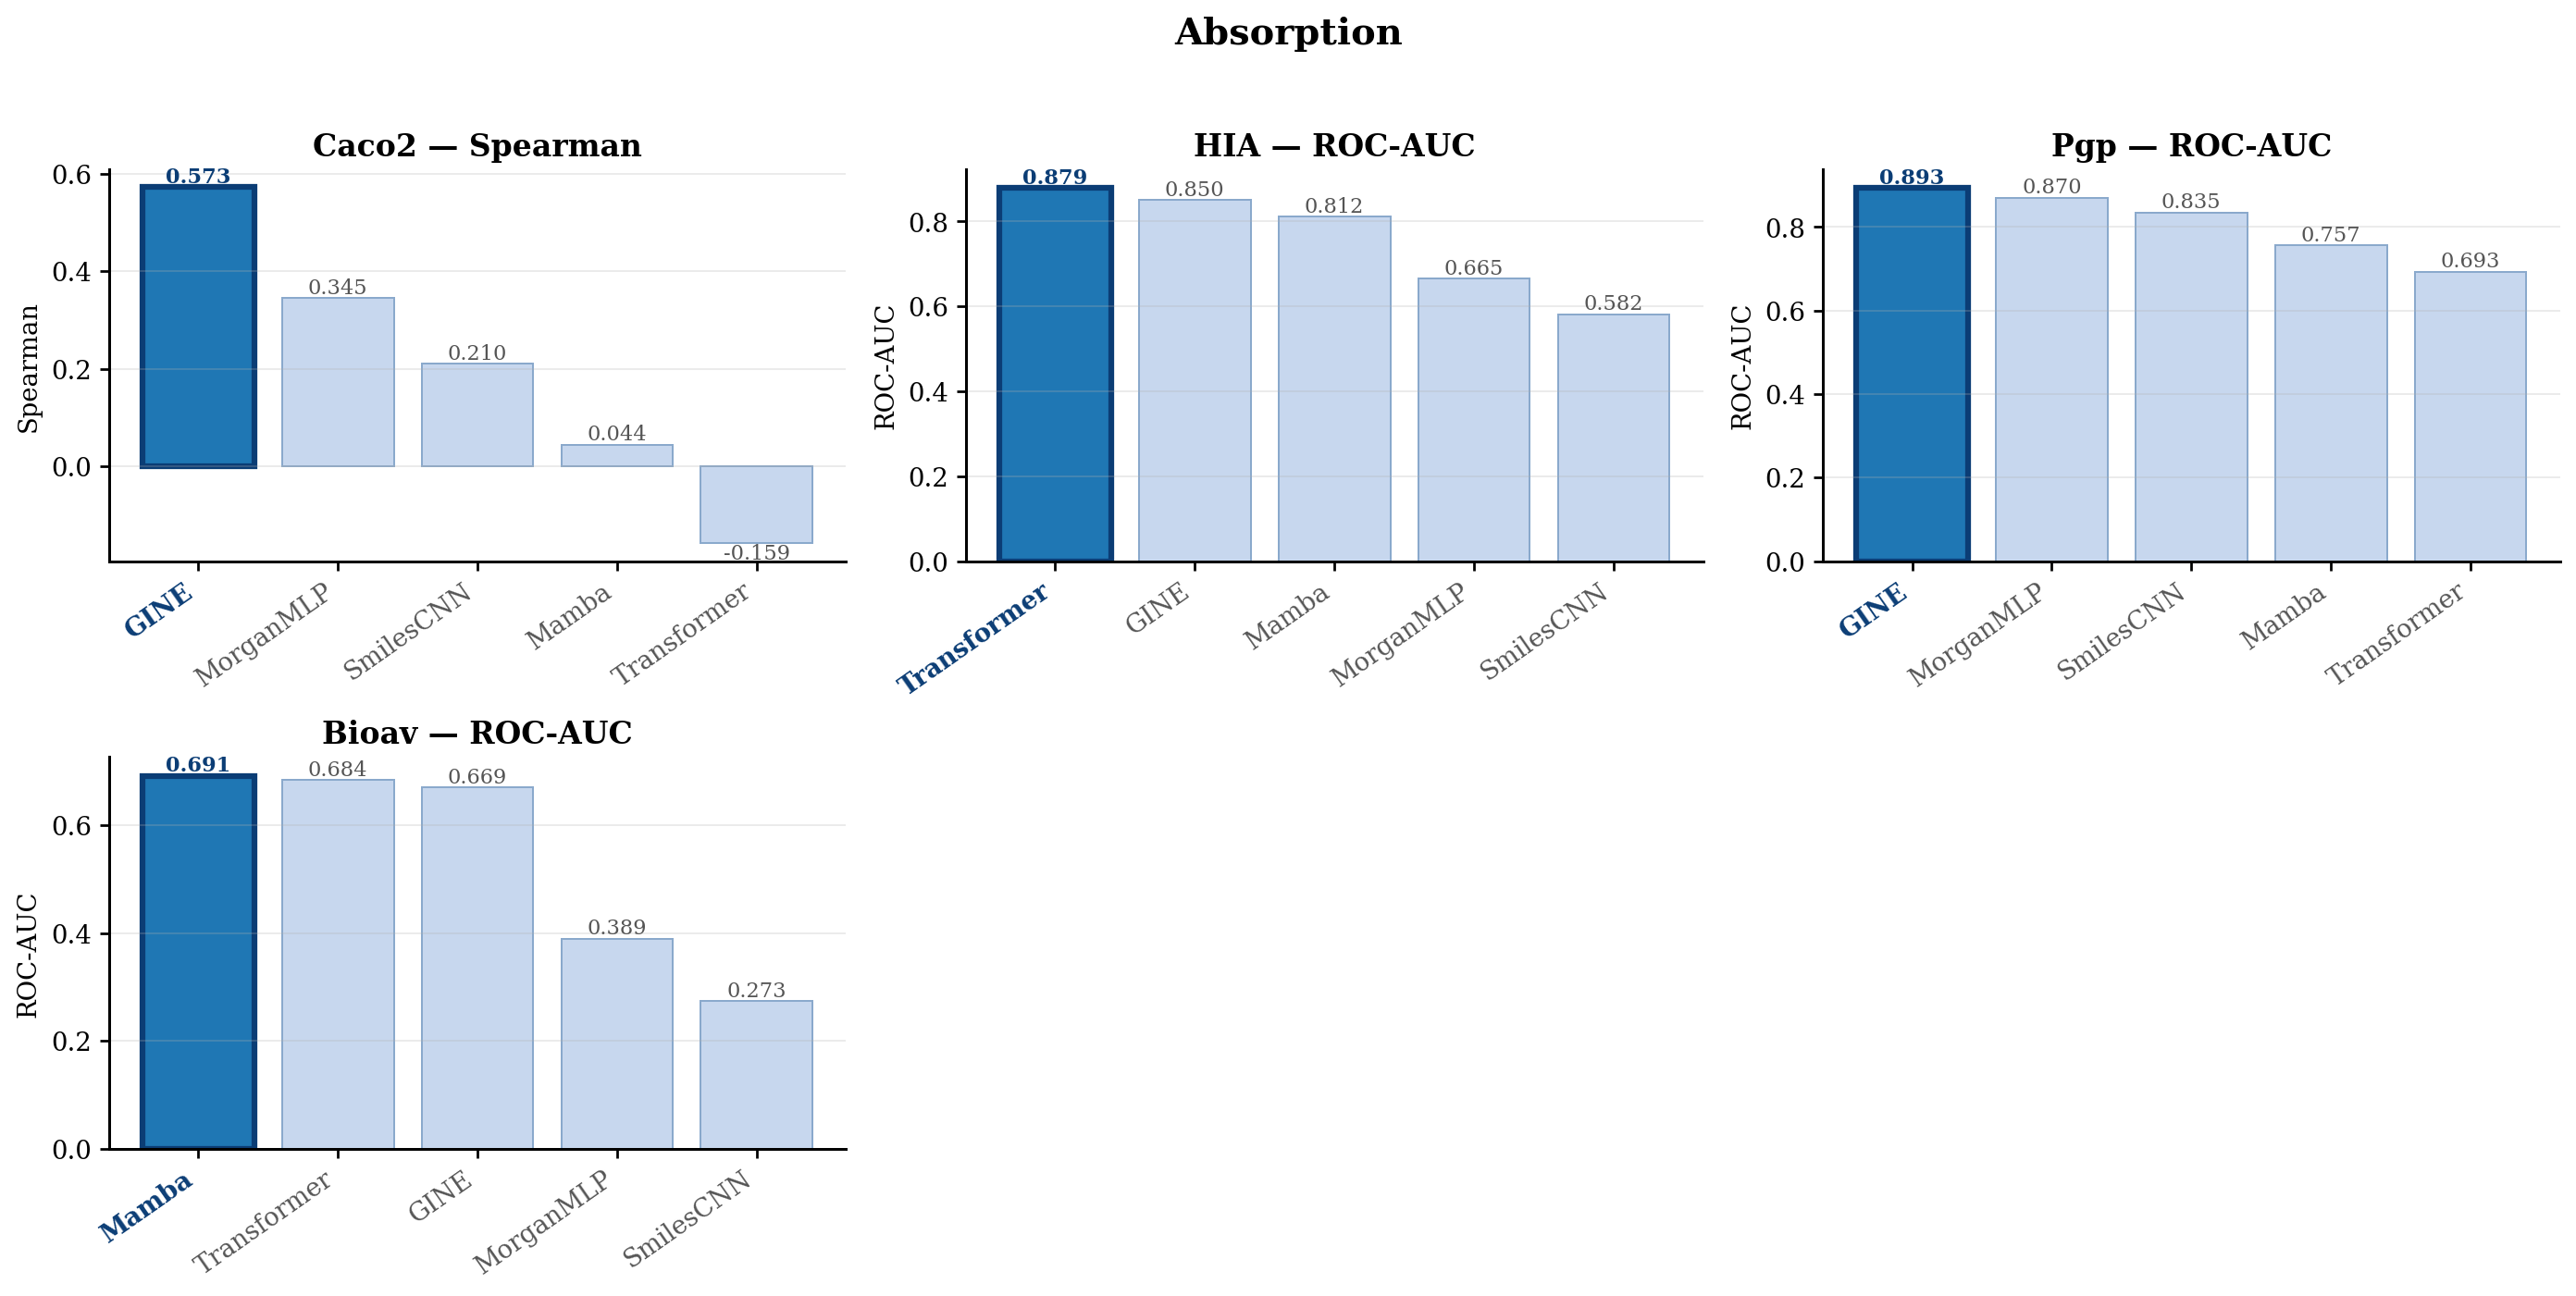

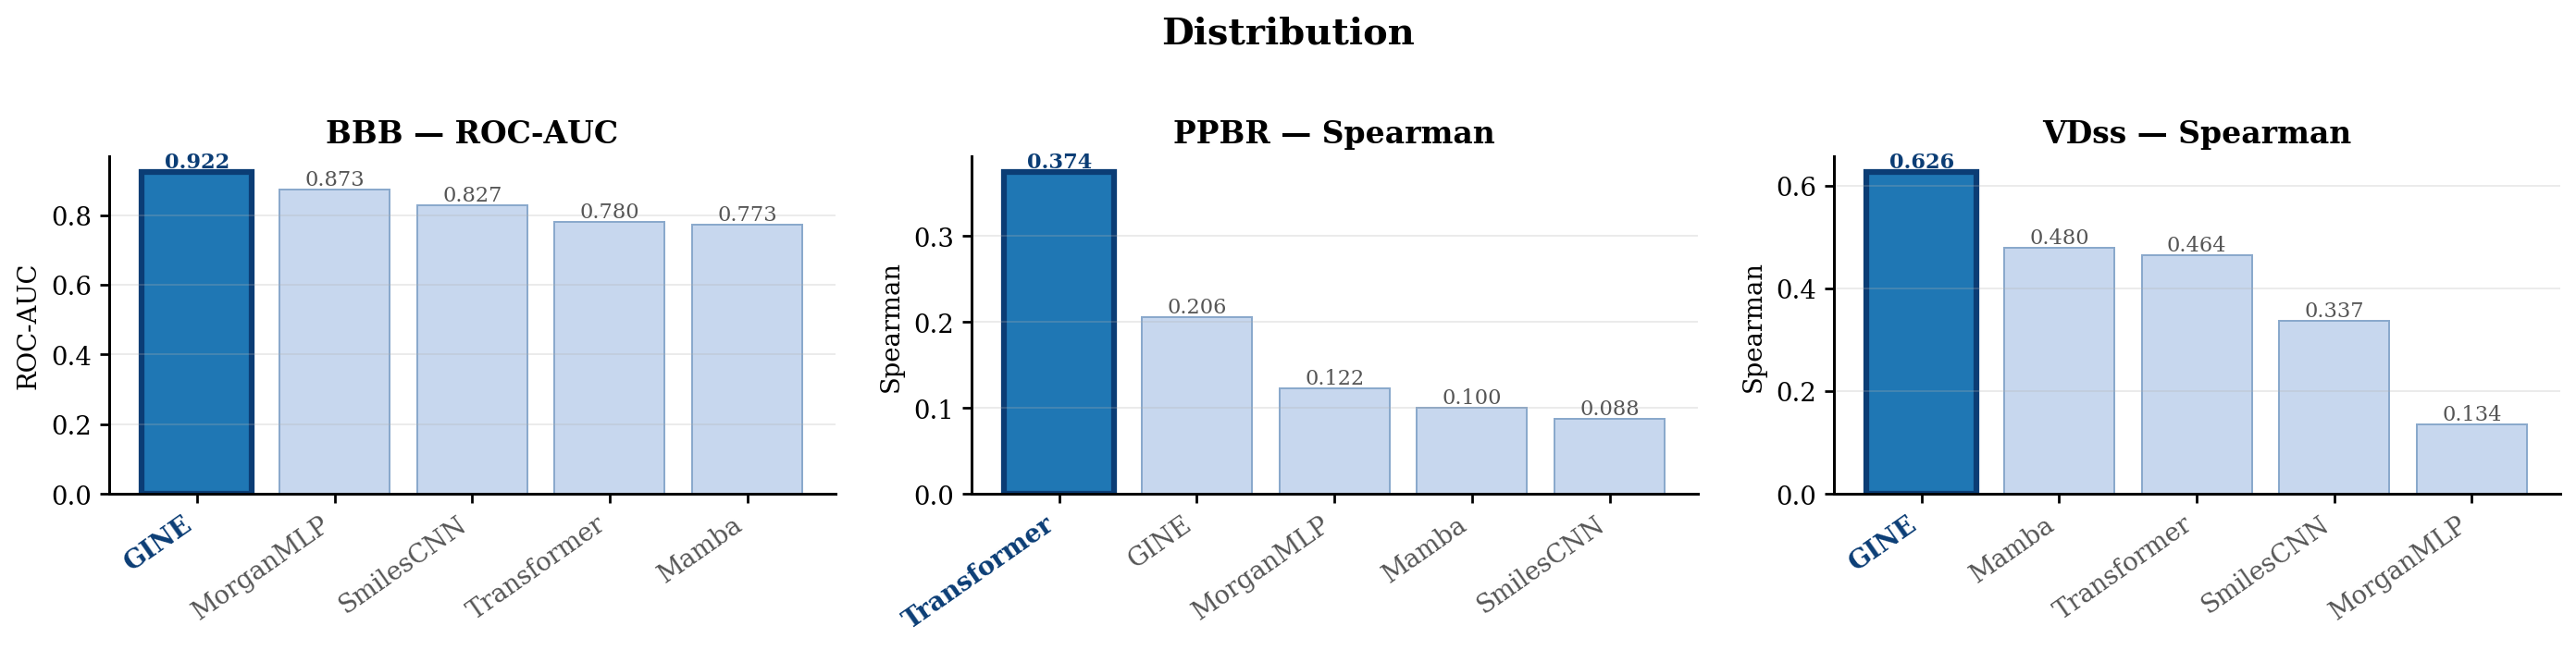

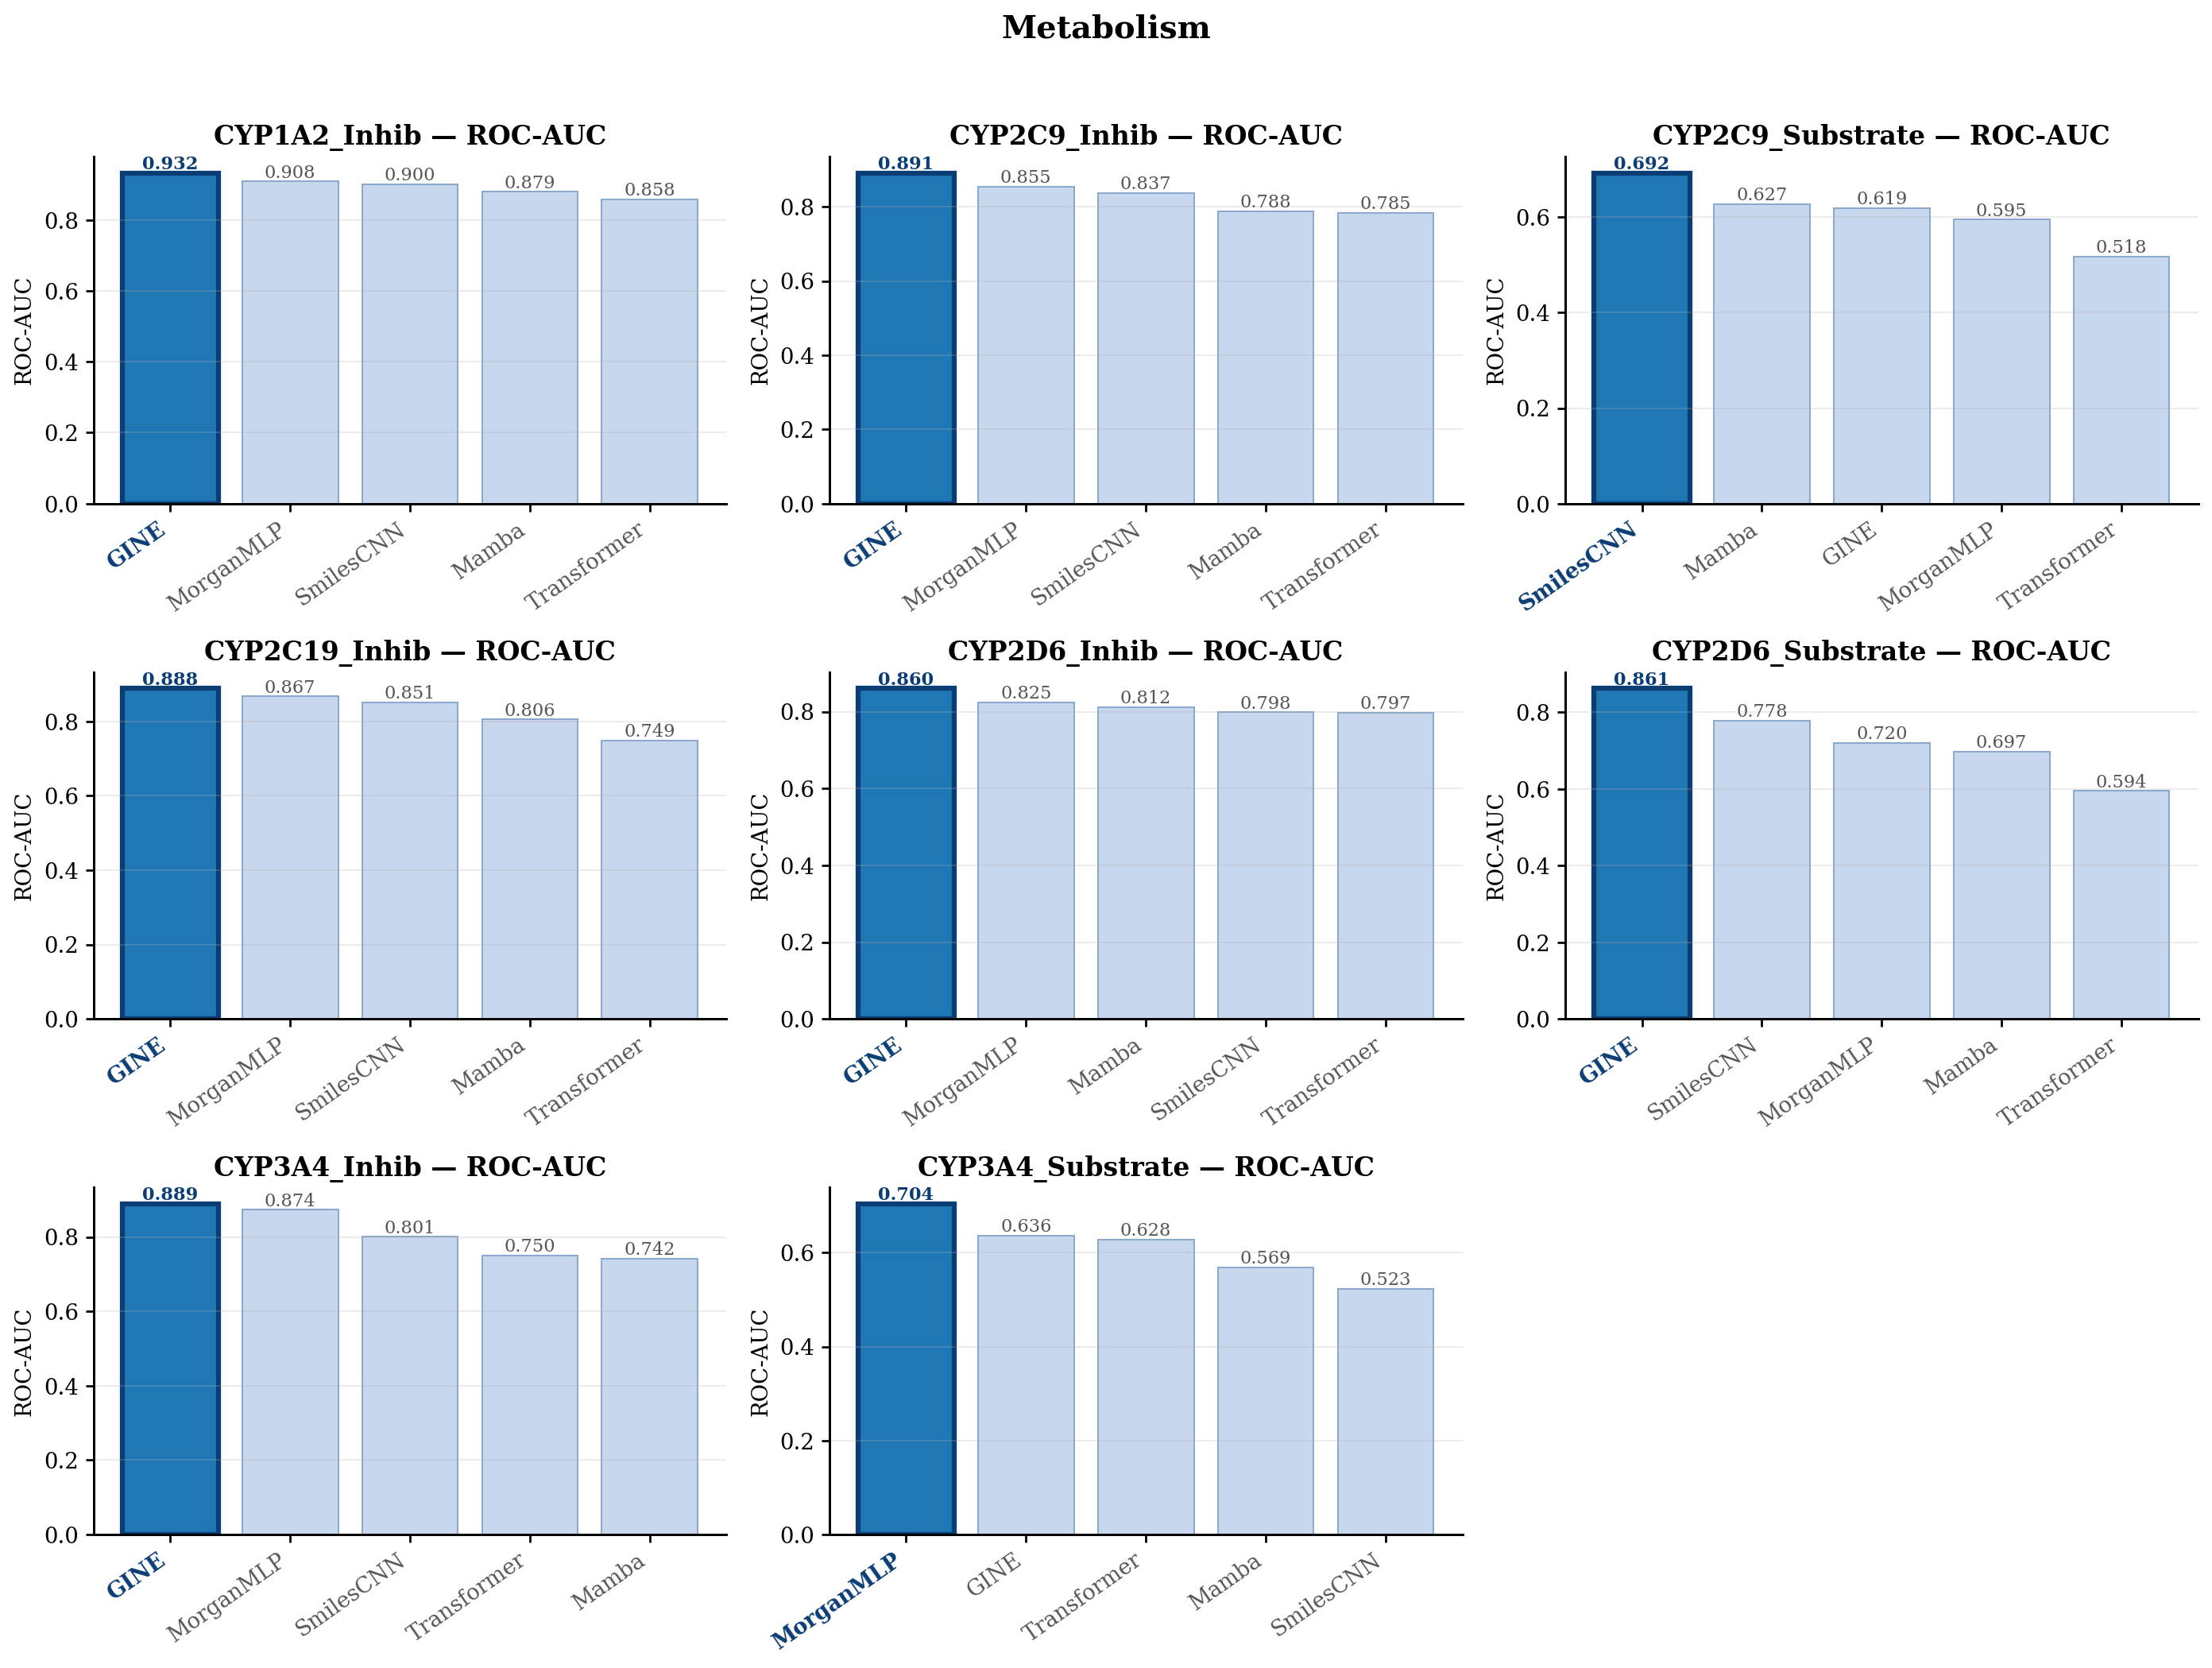

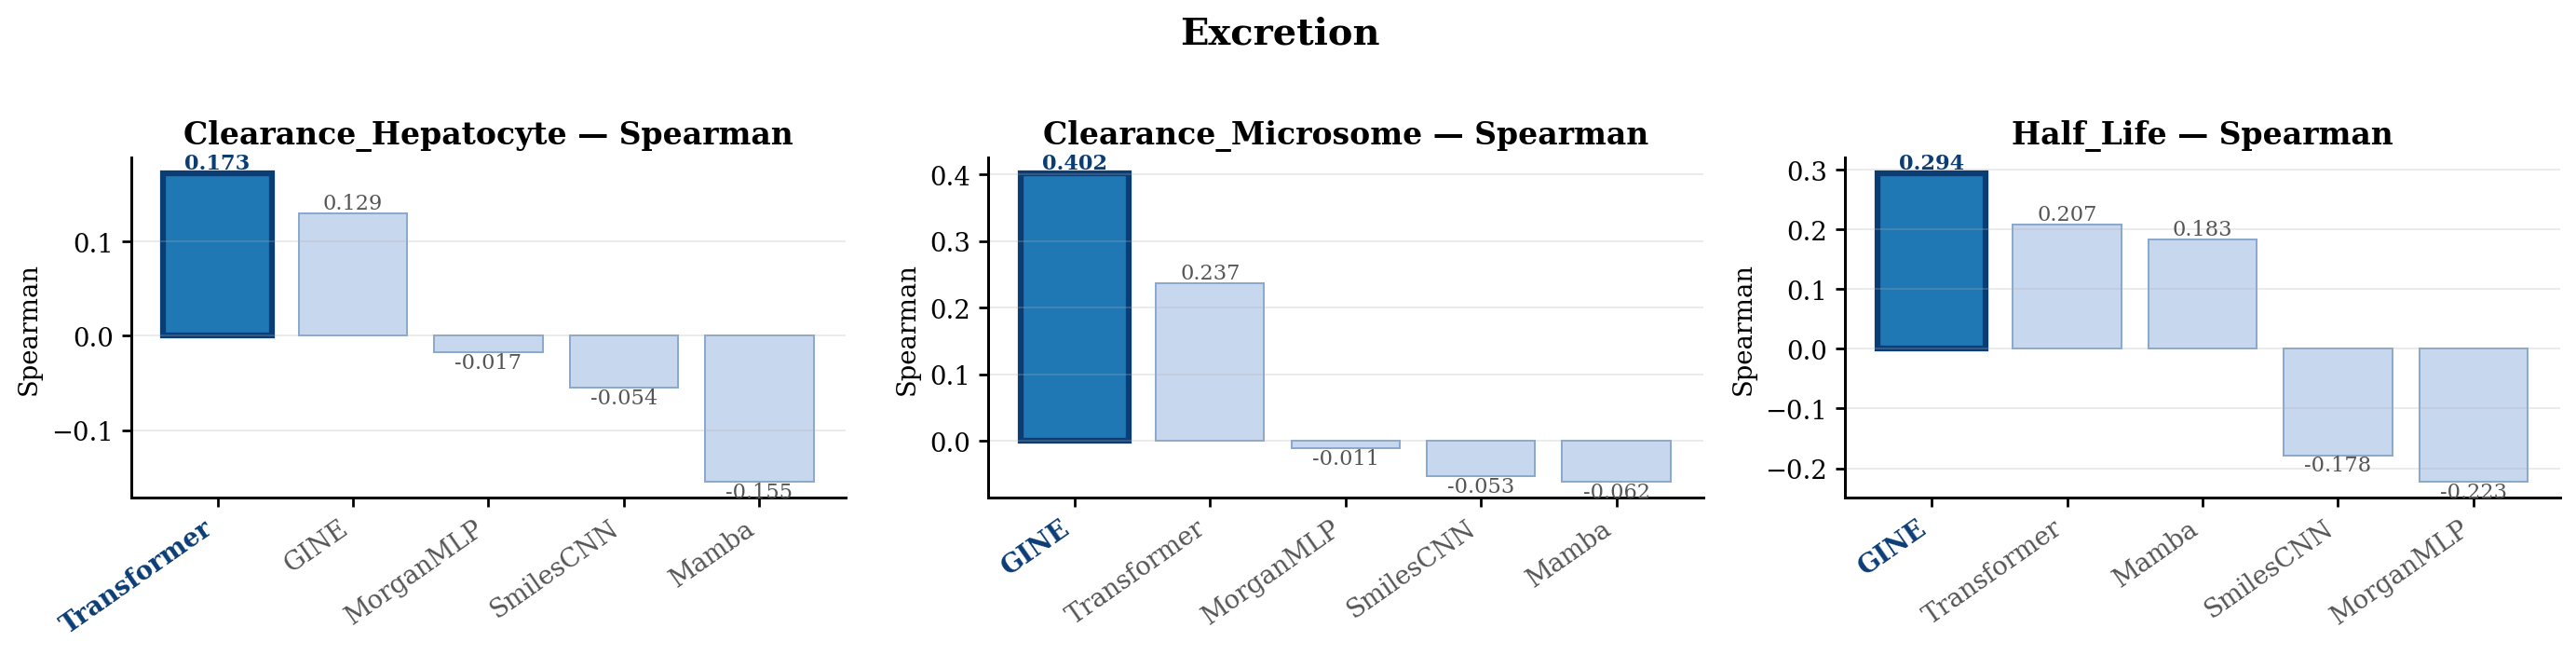

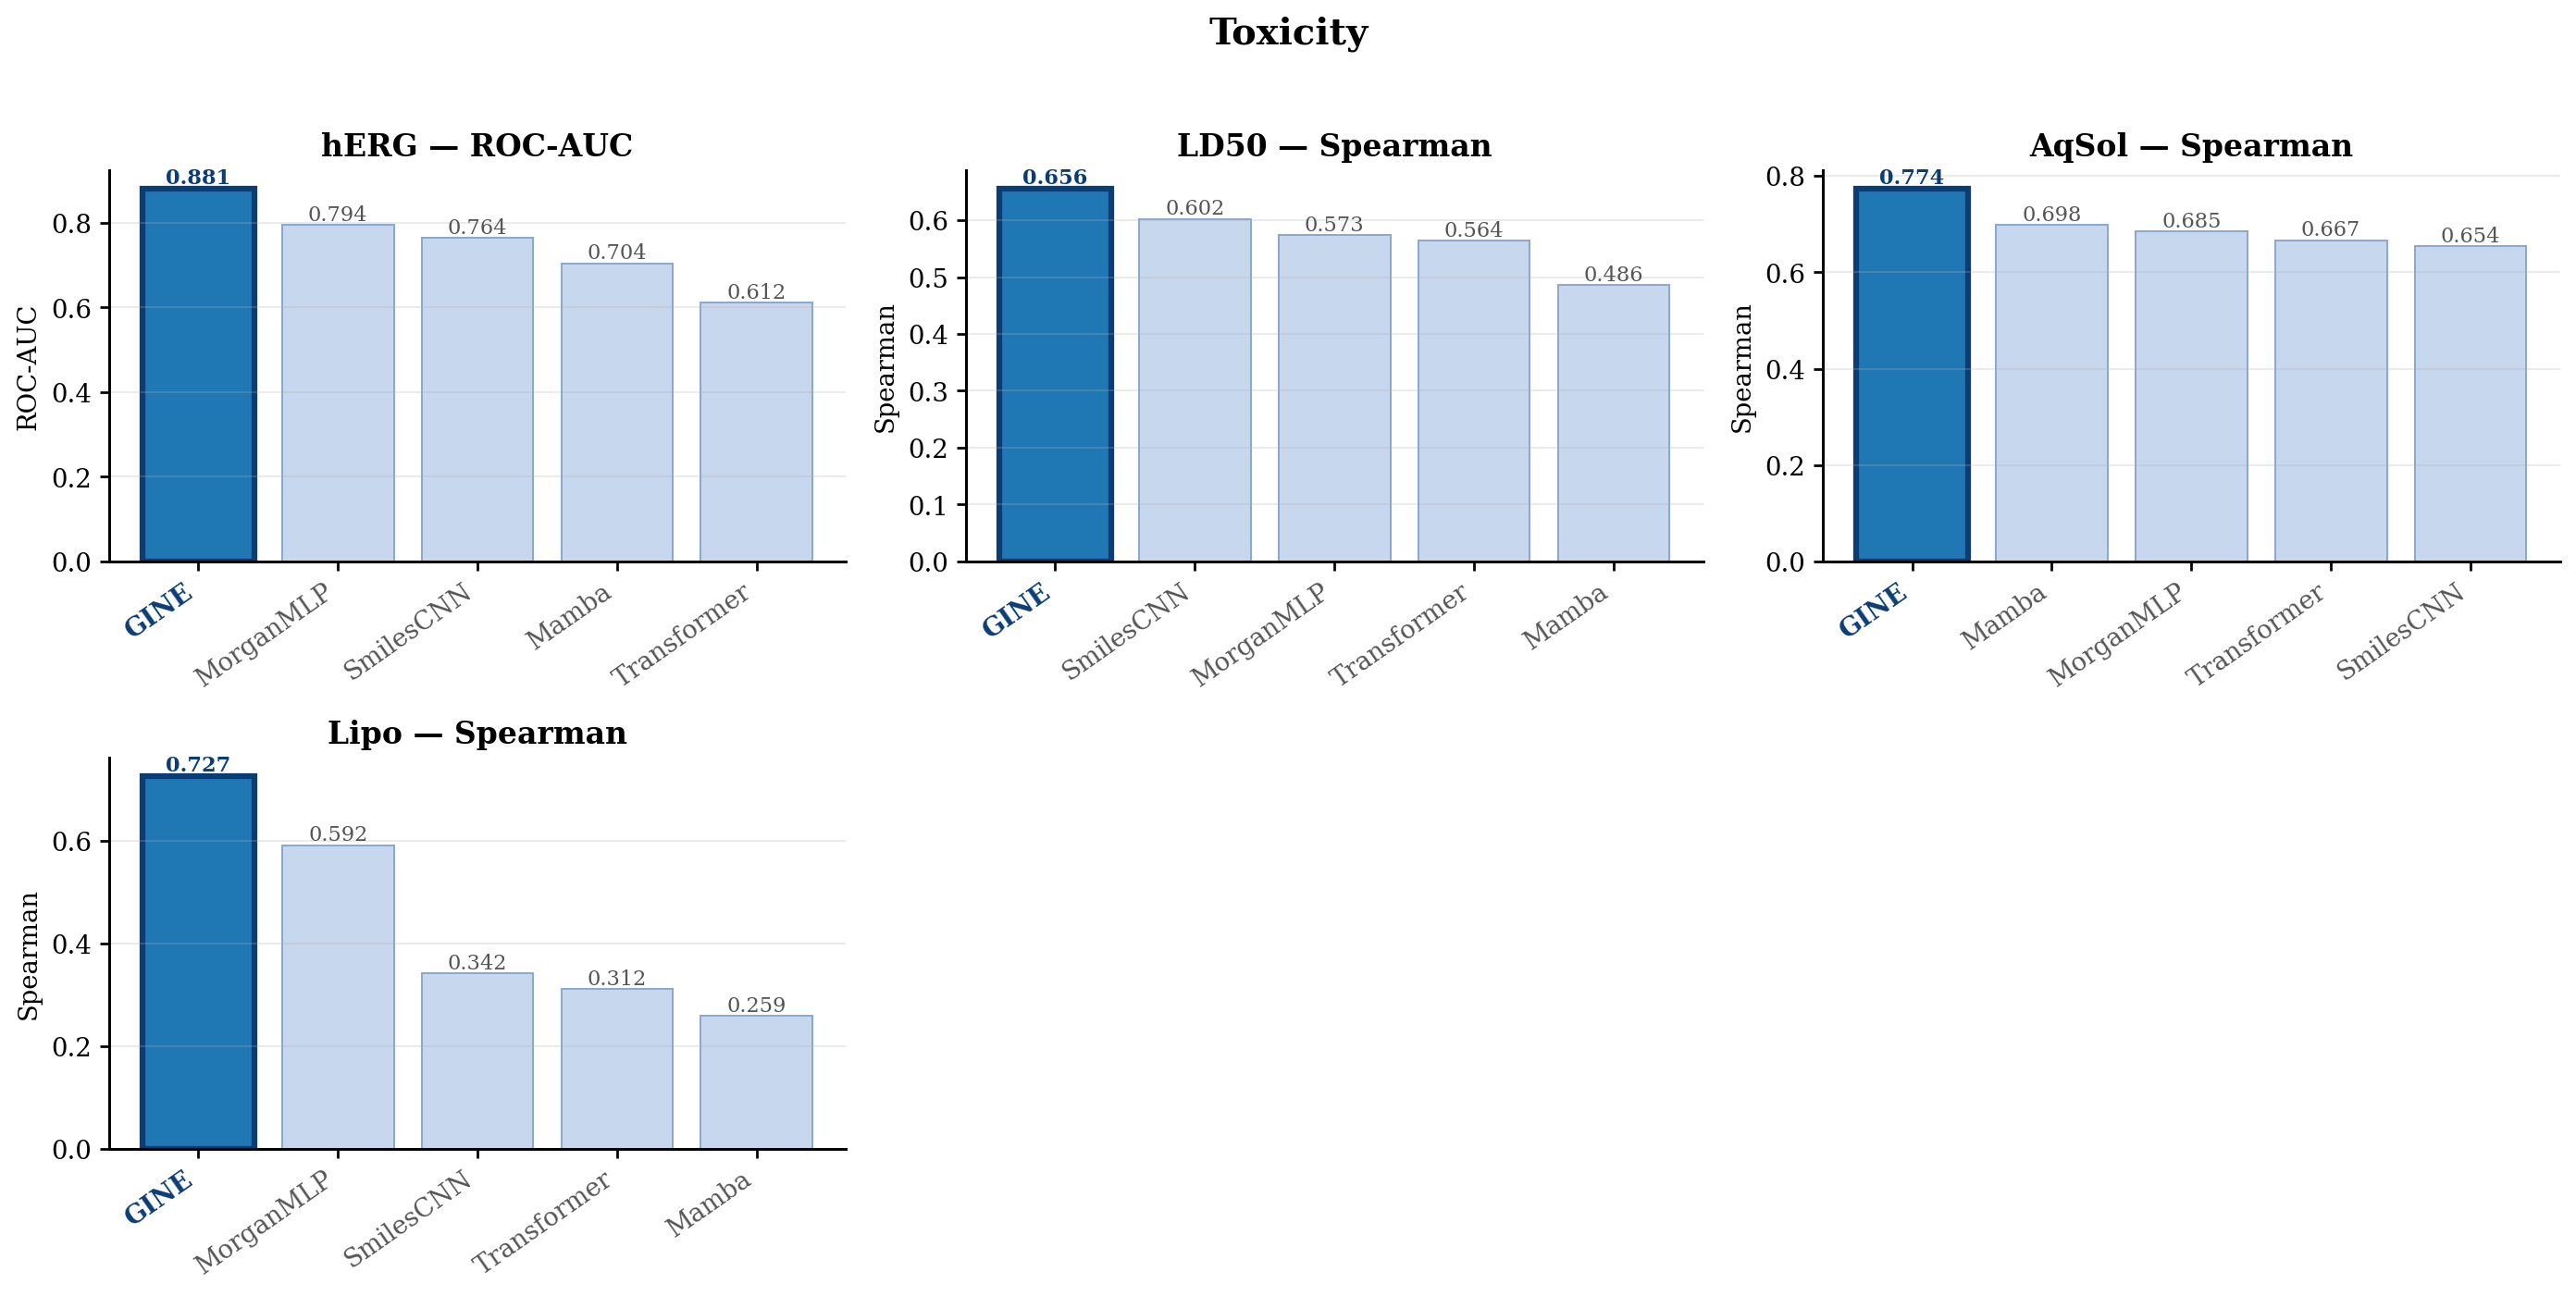

In [112]:
results_df = collect_results_df()
figures = plot_admet_category_plots(results_df)


In [113]:
def make_admet_results_table(
    df,
    task_categories=None,
    model_col="model_name",
    task_col="task_name",
    precision=3,
    return_raw=False,
):
    if task_categories is None:
        task_categories = {
            "Absorption": [
                "Caco2",
                "HIA",
                "Pgp",
                "Bioav",
            ],
            "Distribution": [
                "BBB",
                "PPBR",
                "VDss",
            ],
            "Metabolism": [
                "CYP1A2_Inhib",
                "CYP2C9_Inhib",
                "CYP2C9_Substrate",
                "CYP2C19_Inhib",
                "CYP2D6_Inhib",
                "CYP2D6_Substrate",
                "CYP3A4_Inhib",
                "CYP3A4_Substrate",
            ],
            "Excretion": [
                "Clearance_Hepatocyte",
                "Clearance_Microsome",
                "Half_Life",
            ],
            "Toxicity": [
                "hERG",
                "LD50",
                "AqSol",
                "Lipo",
            ],
        }

    metric_priority = [
        ("test_roc_auc", True, "ROC-AUC"),
        ("test_spearman", True, "Spearman"),
        ("test_mae", False, "MAE"),
        ("test_loss", False, "Loss"),
    ]

    required_cols = {model_col, task_col}
    missing_cols = required_cols - set(df.columns)
    if missing_cols:
        raise ValueError(f"{sorted(missing_cols)}")

    if not any(metric_col in df.columns for metric_col, _, _ in metric_priority):
        raise ValueError("Unknown metric")

    def choose_metric(task_df):
        for metric_col, higher_is_better, metric_label in metric_priority:
            if metric_col in task_df.columns and task_df[metric_col].notna().any():
                return metric_col, higher_is_better, metric_label
        return None, None, None

    rows = []
    best_mask_rows = []

    all_models = sorted(df[model_col].dropna().unique())

    for category, tasks in task_categories.items():
        for task_name in tasks:
            task_df = df[df[task_col] == task_name].copy()
            if task_df.empty:
                continue

            metric_col, higher_is_better, metric_label = choose_metric(task_df)
            if metric_col is None:
                continue

            values = (
                task_df[[model_col, metric_col]]
                .dropna(subset=[metric_col])
                .drop_duplicates(subset=[model_col], keep="last")
                .set_index(model_col)[metric_col]
                .reindex(all_models)
            )

            if values.dropna().empty:
                continue

            best_value = values.max() if higher_is_better else values.min()
            best_mask = values.apply(
                lambda x: bool(np.isclose(x, best_value)) if pd.notna(x) else False
            )

            rows.append({
                "category": category,
                "task_name": task_name,
                "metric": metric_label,
                **values.to_dict(),
            })

            best_mask_rows.append({
                "category": False,
                "task_name": False,
                "metric": False,
                **best_mask.to_dict(),
            })

    table = pd.DataFrame(rows)
    best_mask_df = pd.DataFrame(best_mask_rows)

    if table.empty:
        empty = pd.DataFrame(columns=["category", "task_name", "metric", *all_models])
        styled_empty = empty.style.set_caption("ADMET results: no data")
        return (styled_empty, empty) if return_raw else styled_empty

    table = table[["category", "task_name", "metric", *all_models]]
    best_mask_df = best_mask_df[table.columns]

    model_columns = all_models

    category_colors = {
        "Absorption": "#FDE0C5",
        "Distribution": "#D0E4F2",
        "Metabolism": "#E8D8F8",
        "Excretion": "#FDF1D5",
        "Toxicity": "#F6D2E0",
    }
    
    def highlight_best(_):
        styles = pd.DataFrame("", index=table.index, columns=table.columns)

        for row_idx in table.index:
            category = table.loc[row_idx, "category"]
            category_color = category_colors.get(category, "#FFFFFF")

            styles.loc[row_idx, "category"] = (
                f"background-color: {category_color}; "
                "color: #222222; "
                "font-weight: bold; "
                "border-bottom: 1px solid #CCCCCC; "
                "border-right: 1px solid #E0E0E0;"
            )
            styles.loc[row_idx, "task_name"] = (
                "background-color: #FAFAFA; "
                "color: #333333; "
                "font-weight: 600; "
                "border-bottom: 1px solid #CCCCCC; "
                "border-right: 1px solid #E0E0E0;"
            )
            styles.loc[row_idx, "metric"] = (
                "background-color: #FAFAFA; "
                "color: #555555; "
                "font-style: italic; "
                "border-bottom: 1px solid #CCCCCC; "
                "border-right: 1px solid #E0E0E0;"
            )

            for model_name in model_columns:
                value = table.loc[row_idx, model_name]
                is_best = best_mask_df.loc[row_idx, model_name]

                if is_best:
                    styles.loc[row_idx, model_name] = (
                        "background-color: #E6F5E9; "
                        "color: #000000; "
                        "font-weight: bold; "
                    )
                elif pd.notna(value):
                    styles.loc[row_idx, model_name] = (
                        "background-color: #FFFFFF; "
                        "color: #333333; "
                        "border: 1px solid #EAEAEA;"
                    )
                else:
                    styles.loc[row_idx, model_name] = (
                        "background-color: #F8F9FA; "
                        "color: #999999; "
                        "border: 1px solid #EAEAEA;"
                    )

        return styles

    def format_value(x):
        if pd.isna(x):
            return "—"
        if isinstance(x, (int, float, np.integer, np.floating)):
            return f"{x:.{precision}f}"
        return x

    styled = (
        table.style
        .apply(highlight_best, axis=None)
        .format(format_value)
        .set_caption("ADMET benchmark results — best model per task is highlighted")
        .set_table_styles([
            {
                "selector": "caption",
                "props": [
                    ("caption-side", "top"),
                    ("font-size", "14pt"),
                    ("font-weight", "bold"),
                    ("margin-bottom", "10px"),
                    ("color", "#333333"),
                ],
            },
            {
                "selector": "th",
                "props": [
                    ("background-color", "#343A40"),
                    ("color", "#FFFFFF"),
                    ("font-weight", "bold"),
                    ("text-align", "center"),
                    ("padding", "8px 12px"),
                    ("border", "1px solid #343A40"),
                ],
            },
            {
                "selector": "td",
                "props": [
                    ("text-align", "center"),
                    ("padding", "6px 10px"),
                ],
            },
            {
                "selector": "table",
                "props": [
                    ("border-collapse", "collapse"),
                    ("border-bottom", "2px solid #343A40"),
                    ("font-family", "Arial, sans-serif"),
                ],
            },
        ])
        .hide(axis="index")
    )

    if return_raw:
        return styled, table

    return styled


In [114]:
results_df = collect_results_df()
admet_table = make_admet_results_table(results_df)
admet_table


category,task_name,metric,GINE,Mamba,MorganMLP,SmilesCNN,Transformer
Absorption,Caco2,Spearman,0.573,0.044,0.345,0.210,-0.159
Absorption,HIA,ROC-AUC,0.850,0.812,0.665,0.582,0.879
Absorption,Pgp,ROC-AUC,0.893,0.757,0.870,0.835,0.693
Absorption,Bioav,ROC-AUC,0.669,0.691,0.389,0.273,0.684
Distribution,BBB,ROC-AUC,0.922,0.773,0.873,0.827,0.780
Distribution,PPBR,Spearman,0.206,0.100,0.122,0.088,0.374
Distribution,VDss,Spearman,0.626,0.480,0.134,0.337,0.464
Metabolism,CYP1A2_Inhib,ROC-AUC,0.932,0.879,0.908,0.900,0.858
Metabolism,CYP2C9_Inhib,ROC-AUC,0.891,0.788,0.855,0.837,0.785
Metabolism,CYP2C9_Substrate,ROC-AUC,0.619,0.627,0.595,0.692,0.518


In [115]:
def plot_model_win_distribution(
    df,
    task_categories=None,
    model_col="model_name",
    task_col="task_name",
    tie_strategy="all",
    figsize=(8, 5),
    color="#4C72B0",
    best_color="#1F2937",
    return_raw=False,
    show=True,
):
    if task_categories is None:
        task_categories = {
            "Absorption": ["Caco2", "HIA", "Pgp", "Bioav"],
            "Distribution": ["BBB", "PPBR", "VDss"],
            "Metabolism": [
                "CYP1A2_Inhib",
                "CYP2C9_Inhib",
                "CYP2C9_Substrate",
                "CYP2C19_Inhib",
                "CYP2D6_Inhib",
                "CYP2D6_Substrate",
                "CYP3A4_Inhib",
                "CYP3A4_Substrate",
            ],
            "Excretion": [
                "Clearance_Hepatocyte",
                "Clearance_Microsome",
                "Half_Life",
            ],
            "Toxicity": ["hERG", "LD50", "AqSol", "Lipo"],
        }

    if tie_strategy not in {"all", "split"}:
        raise ValueError('tie_strategy должен быть "all" или "split"')

    metric_priority = [
        ("test_roc_auc", True, "ROC-AUC"),
        ("test_spearman", True, "Spearman"),
        ("test_mae", False, "MAE"),
        ("test_loss", False, "Loss"),
    ]

    required_cols = {model_col, task_col}
    missing_cols = required_cols - set(df.columns)
    if missing_cols:
        raise ValueError(f"{sorted(missing_cols)}")

    if not any(metric_col in df.columns for metric_col, _, _ in metric_priority):
        raise ValueError("Unknown table")

    def choose_metric(task_df):
        for metric_col, higher_is_better, metric_label in metric_priority:
            if metric_col in task_df.columns and task_df[metric_col].notna().any():
                return metric_col, higher_is_better, metric_label
        return None, None, None

    win_rows = []

    for category, tasks in task_categories.items():
        for task_name in tasks:
            task_df = df[df[task_col] == task_name].copy()
            if task_df.empty:
                continue

            metric_col, higher_is_better, metric_label = choose_metric(task_df)
            if metric_col is None:
                continue

            values = (
                task_df[[model_col, metric_col]]
                .dropna(subset=[metric_col])
                .drop_duplicates(subset=[model_col], keep="last")
                .set_index(model_col)[metric_col]
            )

            if values.empty:
                continue

            best_value = values.max() if higher_is_better else values.min()
            winners = values.index[np.isclose(values.to_numpy(), best_value)].tolist()

            win_weight = 1.0 / len(winners) if tie_strategy == "split" else 1.0

            for winner in winners:
                win_rows.append({
                    "category": category,
                    "task_name": task_name,
                    "metric": metric_label,
                    "model_name": winner,
                    "best_value": best_value,
                    "win_weight": win_weight,
                    "n_winners": len(winners),
                })

    win_details = pd.DataFrame(win_rows)
    all_models = sorted(df[model_col].dropna().unique())

    if win_details.empty:
        win_summary = pd.DataFrame({
            "model_name": all_models,
            "wins": 0.0,
        })
    else:
        win_summary = (
            win_details
            .groupby("model_name", as_index=False)["win_weight"]
            .sum()
            .rename(columns={"win_weight": "wins"})
            .set_index("model_name")
            .reindex(all_models, fill_value=0.0)
            .reset_index()
        )

    win_summary = win_summary.sort_values(
        ["wins", "model_name"],
        ascending=[False, True],
    ).reset_index(drop=True)

    max_wins = win_summary["wins"].max() if not win_summary.empty else 0
    bar_colors = [
        best_color if np.isclose(wins, max_wins) and wins > 0 else color
        for wins in win_summary["wins"]
    ]

    fig, ax = plt.subplots(figsize=figsize)

    bars = ax.bar(
        win_summary["model_name"],
        win_summary["wins"],
        color=bar_colors,
        edgecolor="#222222",
        linewidth=1.0,
    )

    for bar, wins in zip(bars, win_summary["wins"]):
        label = f"{wins:g}"
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            label,
            ha="center",
            va="bottom",
            fontsize=11,
            fontweight="bold" if np.isclose(wins, max_wins) and wins > 0 else "normal",
            color="#111111",
        )

    fig.suptitle(
        "Distribution of model wins across ADMET benchmarks",
        fontsize=15,
        fontweight="bold",
        y=0.9,
    )

    ax.set_xlabel("Model", fontsize=12)
    ax.set_ylabel("Number of wins", fontsize=12)

    ax.grid(False)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.tick_params(axis="x", rotation=35)
    for tick_label in ax.get_xticklabels():
        tick_label.set_ha("right")

    fig.tight_layout(rect=[0, 0, 1, 0.94])

    if show:
        plt.show()

    if return_raw:
        return fig, win_summary, win_details

    return fig


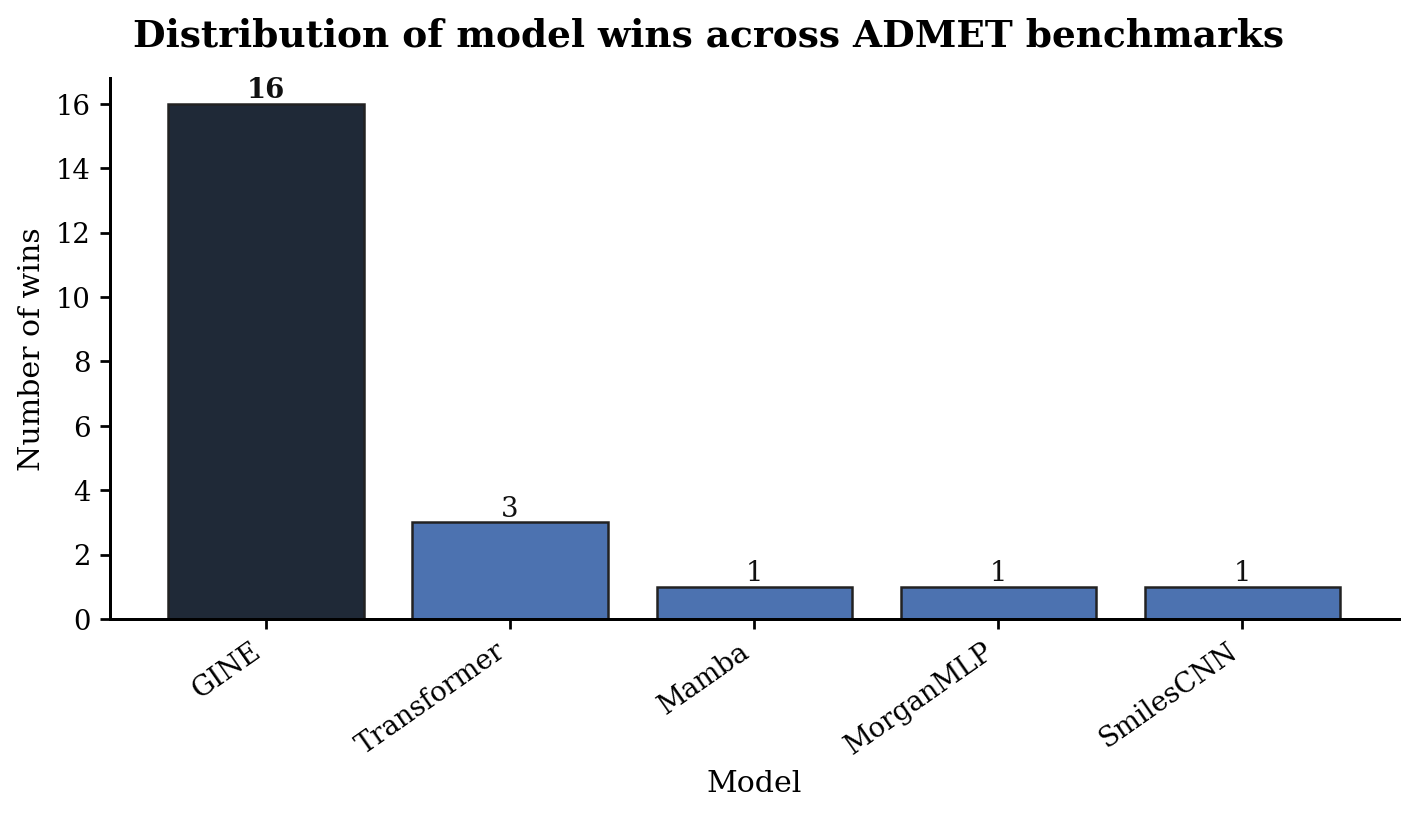

In [116]:
fig = plot_model_win_distribution(results_df)


# Comparison with top models

In [117]:
BEST_RESULTS = [
    {"Task": "Caco2_Wang", "Category": "Absorption", "Metric": "MAE", "Model": "CaliciBoost", "Score": 0.256},
    {"Task": "Bioavailability_Ma", "Category": "Absorption", "Metric": "ROC-AUC", "Model": "MiniMol", "Score": 0.942},
    {"Task": "Lipophilicity_AstraZeneca", "Category": "Absorption", "Metric": "MAE", "Model": "MiniMol", "Score": 0.456},
    {"Task": "Solubility_AqSolDB", "Category": "Absorption", "Metric": "MAE", "Model": "MiniMol", "Score": 0.741},
    {"Task": "HIA_Hou", "Category": "Absorption", "Metric": "ROC-AUC", "Model": "MiniMol", "Score": 0.993},
    {"Task": "Pgp_Broccatelli", "Category": "Absorption", "Metric": "ROC-AUC", "Model": "MapLight + GNN", "Score": 0.938},
    {"Task": "BBB_Martins", "Category": "Distribution", "Metric": "ROC-AUC", "Model": "MiniMol", "Score": 0.924},
    {"Task": "PPBR_AZ", "Category": "Distribution", "Metric": "MAE", "Model": "Gradient Boost", "Score": 7.440},
    {"Task": "VDss_Lombardo", "Category": "Distribution", "Metric": "Spearman", "Model": "MapLight + GNN", "Score": 0.713},
    {"Task": "CYP2C9_Veith", "Category": "Metabolism", "Metric": "AUPRC", "Model": "MapLight + GNN", "Score": 0.859},
    {"Task": "CYP2D6_Veith", "Category": "Metabolism", "Metric": "AUPRC", "Model": "MapLight + GNN", "Score": 0.790},
    {"Task": "CYP3A4_Veith", "Category": "Metabolism", "Metric": "AUPRC", "Model": "MapLight + GNN", "Score": 0.916},
    {"Task": "CYP2C9_Substrate_CarbonMangels", "Category": "Metabolism", "Metric": "AUPRC", "Model": "MiniMol", "Score": 0.474},
    {"Task": "CYP2D6_Substrate_CarbonMangels", "Category": "Metabolism", "Metric": "AUPRC", "Model": "ContextPred", "Score": 0.736},
    {"Task": "CYP3A4_Substrate_CarbonMangels", "Category": "Metabolism", "Metric": "ROC-AUC", "Model": "CFA", "Score": 0.667},
    {"Task": "Half_Life_Obach", "Category": "Metabolism", "Metric": "Spearman", "Model": "CFA", "Score": 0.576},
    {"Task": "Clearance_Hepatocyte_AZ", "Category": "Metabolism", "Metric": "Spearman", "Model": "CFA", "Score": 0.536},
    {"Task": "Clearance_Microsome_AZ", "Category": "Metabolism", "Metric": "Spearman", "Model": "MapLight + GNN", "Score": 0.630},
    {"Task": "LD50_Zhu", "Category": "Toxicity", "Metric": "MAE", "Model": "BaseBoosting KyQVZ6b2", "Score": 0.552},
    {"Task": "hERG", "Category": "Toxicity", "Metric": "ROC-AUC", "Model": "MapLight + GNN", "Score": 0.880},
    {"Task": "AMES", "Category": "Toxicity", "Metric": "ROC-AUC", "Model": "ZairaChem", "Score": 0.871},
    {"Task": "DILI", "Category": "Toxicity", "Metric": "ROC-AUC", "Model": "MiniMol", "Score": 0.956}
]


In [118]:
BENCH_TO_LOCAL_TASK = {
    "Caco2_Wang": "Caco2",
    "Bioavailability_Ma": "Bioav",
    "Lipophilicity_AstraZeneca": "Lipo",
    "Solubility_AqSolDB": "AqSol",
    "HIA_Hou": "HIA",
    "Pgp_Broccatelli": "Pgp",

    "BBB_Martins": "BBB",
    "PPBR_AZ": "PPBR",
    "VDss_Lombardo": "VDss",

    "CYP2C9_Veith": "CYP2C9_Inhib",
    "CYP2D6_Veith": "CYP2D6_Inhib",
    "CYP3A4_Veith": "CYP3A4_Inhib",

    "CYP2C9_Substrate_CarbonMangels": "CYP2C9_Substrate",
    "CYP2D6_Substrate_CarbonMangels": "CYP2D6_Substrate",
    "CYP3A4_Substrate_CarbonMangels": "CYP3A4_Substrate",

    "Half_Life_Obach": "Half_Life",
    "Clearance_Hepatocyte_AZ": "Clearance_Hepatocyte",
    "Clearance_Microsome_AZ": "Clearance_Microsome",

    "LD50_Zhu": "LD50",
    "hERG": "hERG",
    "AMES": "AMES",
    "DILI": "DILI",
}

In [119]:
ADMET_TASKS = {
    # Absorption / physicochemical
    "Caco2_Wang": "Caco2",
    "HIA_Hou": "HIA",
    "Pgp_Broccatelli": "Pgp",
    "Bioavailability_Ma": "Bioav",
    "Lipophilicity_AstraZeneca": "Lipo",
    "Solubility_AqSolDB": "AqSol",

    # Distribution
    "BBB_Martins": "BBB",
    "PPBR_AZ": "PPBR",
    "VDss_Lombardo": "VDss",

    # Metabolism: CYP inhibition
    "CYP2C19_Veith": "CYP2C19_Inhib",
    "CYP2D6_Veith": "CYP2D6_Inhib",
    "CYP3A4_Veith": "CYP3A4_Inhib",
    "CYP1A2_Veith": "CYP1A2_Inhib",
    "CYP2C9_Veith": "CYP2C9_Inhib",

    # Metabolism: CYP substrate
    "CYP2C9_Substrate_CarbonMangels": "CYP2C9_Substrate",
    "CYP2D6_Substrate_CarbonMangels": "CYP2D6_Substrate",
    "CYP3A4_Substrate_CarbonMangels": "CYP3A4_Substrate",

    # Excretion
    "Half_Life_Obach": "Half_Life",
    "Clearance_Hepatocyte_AZ": "Clearance_Hepatocyte",
    "Clearance_Microsome_AZ": "Clearance_Microsome",
}


TOX_TASKS = {
    # Toxicity
    "LD50_Zhu": "LD50",
    "hERG": "hERG",
    "AMES": "AMES",
    "DILI": "DILI",
}

In [120]:
gine = GINEADMETModel(
    node_dim=33,
    edge_dim=14,
    hidden_dim=256,
    num_layers=5,
    fp_dim=2048,
    num_admet_tasks=1,
    dropout=0.1,
    mask_prob=0.15
)

path_to_gine = PATH_TO_EXP + "/checkpoints/GINE/model_best.pt"
load_model_state_dict(gine, path_to_gine)

<All keys matched successfully>

In [121]:
MODELS = {
    "GINE": gine,
}

In [122]:
def normalize_metric(metric: str) -> str:
    metric = metric.lower()

    if metric in {"roc-auc", "roc_auc", "auc"}:
        return "roc_auc"
    elif metric in {"auprc", "avg_precision", "average_precision"}:
        return "auprc"
    elif metric == "mae":
        return "mae"
    elif metric == "spearman":
        return "spearman"
    else:
        raise ValueError(f"Unknown metric: {metric}")


def metric_to_task_type(metric: str) -> str:
    metric = normalize_metric(metric)

    if metric in {"roc_auc", "auprc"}:
        return "classification"
    elif metric in {"mae", "spearman"}:
        return "regression"
    else:
        raise ValueError(f"Unknown metric: {metric}")

In [123]:
BENCH_TASKS = []
task_meta = {}

for row in BEST_RESULTS:
    bench_task = row["Task"]
    local_task = BENCH_TO_LOCAL_TASK.get(bench_task, bench_task)

    metric = normalize_metric(row["Metric"])
    task_type = metric_to_task_type(metric)

    task_dir = os.path.join(PROCESSED_DIR, local_task)

    if not os.path.exists(os.path.join(task_dir, "train.csv")):
        print(f"[SKIP] Missing train.csv for {bench_task} -> {local_task}")
        continue

    BENCH_TASKS.append(local_task)

    task_meta[local_task] = {
        "bench_task": bench_task,
        "category": row["Category"],
        "target_metric": metric,
        "task_type": task_type,
        "best_public_model": row["Model"],
        "best_public_score": row["Score"],
        "metric": metric,
    }

print("Tasks for fine-tune:", len(BENCH_TASKS))
print(BENCH_TASKS)


Tasks for fine-tune: 22
['Caco2', 'Bioav', 'Lipo', 'AqSol', 'HIA', 'Pgp', 'BBB', 'PPBR', 'VDss', 'CYP2C9_Inhib', 'CYP2D6_Inhib', 'CYP3A4_Inhib', 'CYP2C9_Substrate', 'CYP2D6_Substrate', 'CYP3A4_Substrate', 'Half_Life', 'Clearance_Hepatocyte', 'Clearance_Microsome', 'LD50', 'hERG', 'AMES', 'DILI']


In [124]:
def evaluate_model(model, loader, device, task_type: str, model_type: str):
    model.eval()

    all_preds = []
    all_labels = []

    total_loss = 0.0
    n_batches = 0

    if task_type == "classification":
        loss_fn = nn.BCEWithLogitsLoss()
    elif task_type == "regression":
        loss_fn = nn.SmoothL1Loss()
    else:
        raise ValueError(f"Unknown task_type: {task_type}")

    with torch.no_grad():
        for batch in loader:
            if model_type == "graph":
                batch = batch.to(device)
                logits = model(batch, mode="admet").view(-1)
                labels = batch.y.view(-1).to(device).float()
            else:
                x, labels = batch
                x = x.to(device)
                labels = labels.view(-1).to(device).float()
                logits = model(x).view(-1)

            loss = loss_fn(logits, labels)

            total_loss += loss.item()
            n_batches += 1

            if task_type == "classification":
                preds = torch.sigmoid(logits)
            else:
                preds = logits

            all_preds.append(preds.detach().cpu())
            all_labels.append(labels.detach().cpu())

    avg_loss = total_loss / max(n_batches, 1)

    all_preds = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()

    if task_type == "classification":
        if len(np.unique(all_labels)) < 2:
            return {
                "roc_auc": float("nan"),
                "auprc": float("nan"),
                "avg_precision": float("nan"),
                "loss": float(avg_loss),
            }

        auprc = average_precision_score(all_labels, all_preds)

        return {
            "roc_auc": float(roc_auc_score(all_labels, all_preds)),
            "auprc": float(auprc),
            "avg_precision": float(auprc),
            "loss": float(avg_loss),
        }

    elif task_type == "regression":
        spear, _ = spearmanr(all_labels, all_preds)

        if np.isnan(spear):
            spear = float("nan")

        return {
            "mae": float(mean_absolute_error(all_labels, all_preds)),
            "spearman": float(spear),
            "loss": float(avg_loss),
        }


In [125]:
def finetune_one_task(
    model,
    train_loader,
    val_loader,
    device: str,
    task_type: str,
    model_type: str,
    primary_metric: str,
    epochs: int = 50,
    lr: float = 1e-3,
    weight_decay: float = 1e-4,
    patience: int = 10,
    grad_clip: float = 1.0,
    verbose: bool = False,
    writer=None,
    log_prefix: str = "",
    history_path: str = None,
):
    model = model.to(device)

    primary_metric = normalize_metric(primary_metric)

    if task_type == "classification":
        loss_fn = nn.BCEWithLogitsLoss()
    elif task_type == "regression":
        loss_fn = nn.SmoothL1Loss()
    else:
        raise ValueError(f"Unknown task_type: {task_type}")

    if primary_metric == "mae":
        best_primary = float("inf")
        is_better = lambda new, best: new < best
    elif primary_metric in {"roc_auc", "auprc", "spearman"}:
        best_primary = -float("inf")
        is_better = lambda new, best: new > best
    else:
        raise ValueError(f"Unknown primary_metric: {primary_metric}")

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay,
    )

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=max(epochs, 1),
        eta_min=lr * 1e-2,
    )

    best_val_metrics = None
    best_state = None
    best_epoch = None
    no_improve = 0
    global_step = 0

    history = []
    last_epoch = 0

    for epoch in range(1, epochs + 1):
        last_epoch = epoch
        model.train()

        total_loss = 0.0
        n_batches = 0

        for batch in train_loader:
            optimizer.zero_grad(set_to_none=True)

            if model_type == "graph":
                batch = batch.to(device)
                logits = model(batch, mode="admet").view(-1)
                labels = batch.y.view(-1).to(device).float()
            else:
                x, labels = batch
                x = x.to(device)
                labels = labels.view(-1).to(device).float()
                logits = model(x).view(-1)

            loss = loss_fn(logits, labels)
            loss.backward()

            if grad_clip is not None and grad_clip > 0:
                torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)

            optimizer.step()

            total_loss += loss.item()
            n_batches += 1
            global_step += 1

            if writer is not None:
                writer.add_scalar(f"{log_prefix}/batch/train_loss", loss.item(), global_step)

        scheduler.step()

        avg_train_loss = total_loss / max(n_batches, 1)

        val_metrics = evaluate_model(
            model=model,
            loader=val_loader,
            device=device,
            task_type=task_type,
            model_type=model_type,
        )

        primary_val = val_metrics.get(primary_metric, float("nan"))
        current_lr = optimizer.param_groups[0]["lr"]

        epoch_record = {
            "epoch": epoch,
            "train_loss": float(avg_train_loss),
            "lr": float(current_lr),
            "primary_metric": primary_metric,
            "primary_val": None if primary_val is None or np.isnan(primary_val) else float(primary_val),
            "val": {
                k: None if v is None or np.isnan(v) else float(v)
                for k, v in val_metrics.items()
            },
        }

        history.append(epoch_record)

        if history_path is not None:
            with open(history_path, "w", encoding="utf-8") as f:
                json.dump(history, f, indent=2, ensure_ascii=False)

        if writer is not None:
            writer.add_scalar(f"{log_prefix}/epoch/train_loss", avg_train_loss, epoch)
            writer.add_scalar(f"{log_prefix}/epoch/lr", current_lr, epoch)

            for metric_name, value in val_metrics.items():
                if value is not None and not np.isnan(value):
                    writer.add_scalar(f"{log_prefix}/epoch/val_{metric_name}", value, epoch)

        if verbose:
            print(
                f"Epoch {epoch:03d} | "
                f"train_loss={avg_train_loss:.4f} | "
                f"lr={current_lr:.2e} | "
                f"primary={primary_metric}:{primary_val:.5f} | "
                f"val={val_metrics}"
            )

        if not np.isnan(primary_val) and is_better(primary_val, best_primary):
            best_primary = primary_val
            best_val_metrics = val_metrics
            best_state = copy.deepcopy(model.state_dict())
            best_epoch = epoch
            no_improve = 0

            if writer is not None:
                writer.add_scalar(f"{log_prefix}/best/val_{primary_metric}", best_primary, epoch)
        else:
            no_improve += 1

            if no_improve >= patience:
                if verbose:
                    print(f"Early stopping at epoch {epoch}")
                break

    last_state = copy.deepcopy(model.state_dict())

    return best_val_metrics, best_state, best_epoch, last_state, last_epoch, history


In [ ]:
results = run_gine_finetune_benchmarks(
    gine_model=gine,
    task_names=BENCH_TASKS,
    task_meta=task_meta,
    device=DEVICE,
    mol_featurizer=MolFeaturizer(),
    tokenizer=None,
    processed_dir=PROCESSED_DIR,
    batch_size=128,
    epochs=50,
    lr=1e-4,
    weight_decay=1e-4,
    patience=10,
    grad_clip=1.0,
    verbose=False,
    log_dir="./runs/gine_admet_bench_finetune",
    save_dir="./checkpoints/gine_admet_bench_finetune",
    save_last=True,
    save_best=True,
    num_workers=0,
    pad_idx=pad_idx,
)

In [ ]:
def read_gine_admet_bench_finetune_results(
    root="checkpoints/gine_admet_bench_finetune",
    model_name="GINE",
):
    root = Path(root)
    model_dir = root / model_name
    if not model_dir.exists():
        raise FileNotFoundError(f"Directory not found: {model_dir}")
    results = {model_name: {}}
    for summary_path in sorted(model_dir.glob("*/test_summary.json")):
        task_name = summary_path.parent.name
        with summary_path.open("r", encoding="utf-8") as f:
            summary = json.load(f)
        results[model_name][task_name] = summary
    if not results[model_name]:
        raise ValueError(f"No test_summary.json files found in: {model_dir}")
    return results

In [162]:
results = read_gine_admet_bench_finetune_results()

rows = []

for model_name, task_dict in results.items():
    for task_name, res in task_dict.items():
        primary_metric = res["primary_metric"]
        gine_score = res["primary_test_value"]
        best_public_score = res["best_public_score"]

        if primary_metric == "mae":
            delta = None if gine_score is None else gine_score - best_public_score
            better_than_best = None if gine_score is None else gine_score < best_public_score
        else:
            delta = None if gine_score is None else gine_score - best_public_score
            better_than_best = None if gine_score is None else gine_score > best_public_score

        rows.append({
            "task": task_name,
            "bench_task": res["bench_task"],
            "category": res["category"],
            "metric": primary_metric,
            "public_best_model": res["best_public_model"],
            "public_best_score": best_public_score,
            "gine_score": gine_score,
            "delta": delta,
            "gine_better": better_than_best,
            "best_epoch": res["best_epoch"],
            "last_epoch": res["last_epoch"],
        })

summary_df = pd.DataFrame(rows)
summary_df


,task,bench_task,category,metric,public_best_model,public_best_score,gine_score,delta,gine_better,best_epoch,last_epoch
0,AMES,AMES,Toxicity,roc_auc,ZairaChem,0.871,0.839750,-0.031250,False,9,19
1,AqSol,Solubility_AqSolDB,Absorption,mae,MiniMol,0.741,0.950702,0.209702,False,7,17
2,BBB,BBB_Martins,Distribution,roc_auc,MiniMol,0.924,0.921242,-0.002758,False,24,34
3,Bioav,Bioavailability_Ma,Absorption,roc_auc,MiniMol,0.942,0.675781,-0.266219,False,38,48
4,CYP2C9_Inhib,CYP2C9_Veith,Metabolism,auprc,MapLight + GNN,0.859,0.783500,-0.075500,False,11,21
5,CYP2C9_Substrate,CYP2C9_Substrate_CarbonMangels,Metabolism,auprc,MiniMol,0.474,0.371787,-0.102213,False,2,12
6,CYP2D6_Inhib,CYP2D6_Veith,Metabolism,auprc,MapLight + GNN,0.790,0.624166,-0.165834,False,19,29
7,CYP2D6_Substrate,CYP2D6_Substrate_CarbonMangels,Metabolism,auprc,ContextPred,0.736,0.824696,0.088696,True,23,33
8,CYP3A4_Inhib,CYP3A4_Veith,Metabolism,auprc,MapLight + GNN,0.916,0.845755,-0.070245,False,13,23
9,CYP3A4_Substrate,CYP3A4_Substrate_CarbonMangels,Metabolism,roc_auc,CFA,0.667,0.665751,-0.001249,False,11,21


In [163]:
def make_admet_results_table(
    results: dict,
    precision: int = 3,
    return_raw: bool = False,
):
    rows = []
    for model_name, task_dict in results.items():
        for task_name, res in task_dict.items():
            primary_metric = res.get("primary_metric")
            gine_score = res.get("primary_test_value")
            best_public_score = res.get("best_public_score")
            is_lower_better = primary_metric.lower() in ["mae", "loss", "rmse", "mse"]
            if gine_score is not None and best_public_score is not None:
                delta = gine_score - best_public_score
                if is_lower_better:
                    better_than_best = gine_score < best_public_score
                else:
                    better_than_best = gine_score > best_public_score
            else:
                delta = None
                better_than_best = None

            rows.append({
                "model": model_name,
                "bench_task": res.get("bench_task"),
                "category": res.get("category"),
                "metric": primary_metric,
                "public_best_model": res.get("best_public_model"),
                "public_best_score": best_public_score,
                "gine_score": gine_score,
                "delta": delta,
                "gine_better": better_than_best,
            })
    rows.sort(key=lambda x: x["category"])
    summary_df = pd.DataFrame(rows)

    if summary_df.empty:
        empty_styled = summary_df.style.set_caption("ADMET results: no data")
        return (empty_styled, summary_df) if return_raw else empty_styled

    category_colors = {
        "Absorption": "#FDE0C5",
        "Distribution": "#D0E4F2",
        "Metabolism": "#E8D8F8",
        "Excretion": "#FDF1D5",
        "Toxicity": "#F6D2E0",
    }

    def highlight_rows(row):
        styles = pd.Series([""] * len(row), index=row.index)
        
        category = row.get("category", "")
        cat_color = category_colors.get(category, "#FFFFFF")
        is_better = row.get("gine_better")

        for col in row.index:
            base_style = "border-bottom: 1px solid #CCCCCC; border-right: 1px solid #E0E0E0; "
            if col == "category":
                styles[col] = base_style + f"background-color: {cat_color}; color: #222222; font-weight: bold;"
            elif col in ["gine_score", "delta_gine_minus_public", "gine_better"]:
                if is_better is True:
                    styles[col] = base_style + "background-color: #E6F5E9; color: #000000; font-weight: bold;"
                elif is_better is False:
                    styles[col] = base_style + "background-color: #FFF0F0; color: #555555;"
                else:
                    styles[col] = base_style + "background-color: #FAFAFA; color: #333333;"
            else:
                styles[col] = base_style + "background-color: #FFFFFF; color: #333333;"

        return styles

    def format_value(x):
        if pd.isna(x):
            return "—"
        if isinstance(x, bool):
            return "✅ Yes" if x else "❌ No"
        if isinstance(x, (int, np.integer)):
            return str(x)
        if isinstance(x, (float, np.floating)):
            return f"{x:+.{precision}f}" if "delta" in str(x) else f"{x:.{precision}f}"
        return x

    styled = (
        summary_df.style
        .apply(highlight_rows, axis=1)
        .format(format_value)
        .set_caption("GINE vs Public Leaderboard Results")
        .set_table_styles([
            {
                "selector": "caption",
                "props": [
                    ("caption-side", "top"),
                    ("font-size", "16pt"),
                    ("font-weight", "bold"),
                    ("margin-bottom", "12px"),
                    ("color", "#333333"),
                ],
            },
            {
                "selector": "th",
                "props": [
                    ("background-color", "#343A40"), 
                    ("color", "#FFFFFF"),
                    ("font-weight", "bold"),
                    ("text-align", "center"),
                    ("padding", "10px 14px"),
                    ("border", "1px solid #343A40"),
                ],
            },
            {
                "selector": "td",
                "props": [
                    ("text-align", "center"),
                    ("padding", "8px 12px"),
                ],
            },
            {
                "selector": "table",
                "props": [
                    ("border-collapse", "collapse"),
                    ("border-bottom", "2px solid #343A40"),
                    ("font-family", "Arial, sans-serif"),
                ],
            },
        ])
        .hide(axis="index")
    )

    if return_raw:
        return styled, summary_df

    return styled


In [164]:
styled_table = make_admet_results_table(results)
styled_table

model,bench_task,category,metric,public_best_model,public_best_score,gine_score,delta,gine_better
GINE,Solubility_AqSolDB,Absorption,mae,MiniMol,0.741,0.951,0.210,❌ No
GINE,Bioavailability_Ma,Absorption,roc_auc,MiniMol,0.942,0.676,-0.266,❌ No
GINE,Caco2_Wang,Absorption,mae,CaliciBoost,0.256,0.319,0.063,❌ No
GINE,HIA_Hou,Absorption,roc_auc,MiniMol,0.993,0.971,-0.022,❌ No
GINE,Lipophilicity_AstraZeneca,Absorption,mae,MiniMol,0.456,0.508,0.052,❌ No
GINE,Pgp_Broccatelli,Absorption,roc_auc,MapLight + GNN,0.938,0.924,-0.014,❌ No
GINE,BBB_Martins,Distribution,roc_auc,MiniMol,0.924,0.921,-0.003,❌ No
GINE,PPBR_AZ,Distribution,mae,Gradient Boost,7.440,9.132,1.692,❌ No
GINE,VDss_Lombardo,Distribution,spearman,MapLight + GNN,0.713,0.677,-0.036,❌ No
GINE,CYP2C9_Veith,Metabolism,auprc,MapLight + GNN,0.859,0.784,-0.075,❌ No
